# Análise de Resultados — Estrutura por RQ

Notebook central de análise dos resultados experimentais.  
Unidade de análise: **dataset** (agregação interna de folds/repetições).

---

<details>
<summary><b>Estrutura do Capítulo (clique para expandir)</b></summary>

```
Capítulo de Resultados
|
|-- 0) Guia de leitura (setup metodológico)
|   |-- Unidade de análise: dataset (agregação interna de folds/repetições)
|   |-- Definição de gap ao ideal (Δ) e separação magnitude vs. sentido
|   +-- Convenções de "melhor/pior" por métrica e regras de reporte

|-- 1) Baseline: diagnóstico + triagem (gating)
|   |-- Distribuição de disparidades no baseline (categorias A/B/C)
|   +-- Regra de gating e cobertura (quantos datasets/estratos entram em cada análise)

|-- 2) RQ1 — Quais estratégias têm melhor efeito (global)?
|   |-- Figura síntese com Δfairness por categoria de mitigação (pre vs in vs baseline)
|   +-- Tabela de ranking + teste omnibus (Friedman)

|-- 3) RQ2 — Há estratégia melhor por métrica/categoria (A/B/C)?
|   |-- Figura com facetas por A/B/C
|   +-- Tabela curta com top métodos por categoria

|-- 4) RQ3 — A intensidade do viés afeta mitigação?
|   +-- Figura |gap| baseline vs Δ|gap| (por método/categoria)

|-- 5) RQ4 — O sentido do viés altera a mitigação?
|   +-- Figura com Δgap por estrato de sentido (gap assinado no baseline)

|-- 6) RQ5 — Trade-off desempenho ↔ fairness
|   |-- Scatter/quadrantes: Δdesempenho (x) vs Δfairness (y)
|   +-- Tabela curta com métodos não-dominados (Pareto)

+-- 7) Apêndices (catálogos e completude)
    |-- Catálogo dataset × método × métrica
    |-- Subpadrões finos (A1/A2/...)
    |-- Boxplots detalhados, sensibilidade
    +-- Holm completo e comparações adicionais
```

</details>

## 0) Guia de leitura (setup metodológico)

### 0.1 Setup técnico


In [167]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [168]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = Path.cwd().parent
sys.path[:0] = [str(ROOT)]

from auxiliar_analysis import config

from auxiliar_analysis.analysis_utils import (
    # Configuração
    set_plot_style,

    # Carregamento
    load_results,
    add_experiment_metadata,

    # Estatísticas
    generate_consistency_report,
    print_consistency_report,

    # Tabelas e exportação
    save_table,
    latex_and_save,
)

from auxiliar_analysis.statistic_test import (
    run_all_category_analysis,
    run_all_experiment_analysis,
    save_results_latex
)

from auxiliar_analysis.dataset_level_viz import (
    plot_category_dataset_level
)

from auxiliar_analysis.rq0_utils import (
    METRIC_SPECS,
    METRIC_ORDER,
    build_metric_characterization_table,
    build_baseline_diagnostic_table,
    build_eligibility_direction_table,
    compute_gating_coverage,
    plot_baseline_gap_overview,
    plot_baseline_components_gap,
)

from auxiliar_analysis.rq1_utils import (
    compute_delta_fairness_category,
    compute_delta_fairness_method,
    compute_win_rate,
    save_delta_table,
    plot_delta_fairness_category,
    plot_delta_fairness_method,
)

set_plot_style(
    palette=["#4E79A7", "#76B7B2", "#F28E2B"],
    background="whitegrid",
    font="Arial",
    font_scale=1.1
)

In [169]:
# Configurações do projeto
dataset_configs = config.DATASET_CONFIGS
ideal_values = config.IDEAL_VALUES
metric_map = config.METRIC_MAP
translate = config.TRANSLATE
metric_group_map = config.METRIC_GROUP_MAP
category_map = config.CATEGORY_MAP

In [170]:
from pathlib import Path

OUT_BASE = config.ANALYSIS_PATH
RQ_DIRS = {
    "RQ0": OUT_BASE / "RQ0_baseline",
    "RQ1": OUT_BASE / "RQ1",
    "RQ2": OUT_BASE / "RQ2",
    "RQ3": OUT_BASE / "RQ3",
    "RQ4": OUT_BASE / "RQ4",
    "RQ5": OUT_BASE / "RQ5",
}

for p in RQ_DIRS.values():
    (p / "figs").mkdir(parents=True, exist_ok=True)
    (p / "tables").mkdir(parents=True, exist_ok=True)

RQ0_FIGS = RQ_DIRS["RQ0"] / "figs"
RQ0_TABLES = RQ_DIRS["RQ0"] / "tables"
RQ1_FIGS = RQ_DIRS["RQ1"] / "figs"
RQ1_TABLES = RQ_DIRS["RQ1"] / "tables"
RQ2_FIGS = RQ_DIRS["RQ2"] / "figs"
RQ2_TABLES = RQ_DIRS["RQ2"] / "tables"
RQ3_FIGS = RQ_DIRS["RQ3"] / "figs"
RQ3_TABLES = RQ_DIRS["RQ3"] / "tables"
RQ4_FIGS = RQ_DIRS["RQ4"] / "figs"
RQ4_TABLES = RQ_DIRS["RQ4"] / "tables"
RQ5_FIGS = RQ_DIRS["RQ5"] / "figs"
RQ5_TABLES = RQ_DIRS["RQ5"] / "tables"


In [171]:
# Datasets a processar
datasets_to_run = {
    "HEART": True,
    "AIDS": True,
    "OBESITY": True,
    "ARRHYTHMIA": True,
    "MENTAL": True,
    "DIABETES": True
}

EXP_IDS_VALIDOS = ["BLRA", "BLRU", "BRFA", "BRFU", "EDL", "ERL", "IAD", "IFG", "IGLA", "IGLU", "IP", "IW"]

# Colunas para exibição — análise por CATEGORIA (testes estatísticos RQ1/RQ2)
cols_omnibus = ["metric","category","p_value","median_delta_fair","iqr_delta_fair"] #"median_gap","iqr_gap", "statistic"
cols_posthoc = ["metric","category","avg_rank","p_holm","median_delta_fair","iqr_delta_fair"] #"median_gap","delta_rank","z",

# Colunas para exibição — análise por EXPERIMENTO (testes estatísticos RQ1/RQ2)
cols_exp_omnibus = ["metric","method","category","p_value","median_delta_fair","iqr_delta_fair"]
cols_exp_posthoc = ["metric","method","category","avg_rank","p_holm","median_delta_fair","iqr_delta_fair"]

# Colunas descritivas — RQ4 (sem testes estatísticos)
cols_desc_cat = ["metric","category","median_delta_fair","iqr_delta_fair","median_r_fair","iqr_r_fair"] #"median_gap","iqr_gap","n"
cols_desc_exp = ["metric","method","category","median_delta_fair","iqr_delta_fair","median_r_fair","iqr_r_fair"] #"n","median_gap","iqr_gap",


### 0.2 Carregamento e tratamento dos dados


In [172]:
# Carregar dados
df = load_results(datasets_to_run, config.DATASET_CONFIGS)
df = df[df['exp_id'].isin(EXP_IDS_VALIDOS)]
print(f"Dados carregados: {len(df)} linhas, {df.exp_id.nunique()} experimentos")

Dados carregados: 28620 linhas, 12 experimentos


In [173]:
df = add_experiment_metadata(df)
df['metric_type'] = df['metric'].map(metric_map).fillna('fairness')
df['metric_group'] = df['metric'].map(metric_group_map).fillna('others')

In [174]:
# Converter valores para numérico
# Datasets reprocessados gravam value como float; os antigos como string
df["value_num"] = pd.to_numeric(
    df["value"].apply(
        lambda x: str(x).strip("[]") if isinstance(x, str) else x
    ),
    errors="coerce",
)

### 0.3 Validação de consistência


In [175]:
# Gerar e exibir relatório de consistência
consistency_report = generate_consistency_report(df)
print_consistency_report(consistency_report)

RELATÓRIO DE CONSISTÊNCIA DOS RESULTADOS

📊 NaN por Métrica (%):
  ✓ Nenhum NaN encontrado

📊 NaN por Dataset (%):
  ✓ Nenhum NaN encontrado

⚠️  Valores Infinitos: 0

📈 Execuções por Experimento:
  • BLRA: 2340
  • BLRU: 2340
  • BRFA: 2340
  • BRFU: 2340
  • EDL: 2340
  • ERL: 2880
  • IAD: 2340
  • IFG: 2340
  • IGLA: 2340
  • IGLU: 2340
  • IP: 2340
  • IW: 2340


## 1) RQ0.1 — Baseline em fairness: diagnóstico + triagem (gating)

**Objetivo:** Caracterizar disparidades no baseline típico e estabelecer critérios de relevância.

**Análises:**
- Distribuição e variabilidade das métricas de fairness no baseline típico
- Tabela de caracterização: grupo, faixa, ideal, n, mediana, IQR + limiares de severidade
- Cobertura do gating: quantos datasets passam o limiar por métrica/categoria A/B/C
- Classificação de padrões de viés (A/B/C × severidade × direção)

In [176]:
# === Controle de fontes — RQ0 ===
from auxiliar_analysis import rq0_utils

rq0_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 15,
    "legend_fontsize": 13,
})


In [177]:
# Filtrar baseline
baseline_df = df[df['exp_type'] == 'baseline']
fairness_baseline = baseline_df[baseline_df.metric_type == 'fairness']

In [178]:
baseline_ds = (
    fairness_baseline
    .groupby(["dataset", "metric"], as_index=False)
    .agg(
        value_num=("value_num", "median"),
        metric_group=("metric_group", "first") if "metric_group" in fairness_baseline.columns else ("metric", "first")
    )
)

### 1.1 Panorama de fairness no baseline típico

Visão agregada da distância ao ideal (gap) do baseline típico para todas as métricas, e comparação dos 4 modelos que compõem o baseline típico (LR Aware, LR Unaware, RF Aware, RF Unaware).

Figura salva em: experiments\results\analysis\RQ0_baseline\figs\baseline_gap_overview.pdf


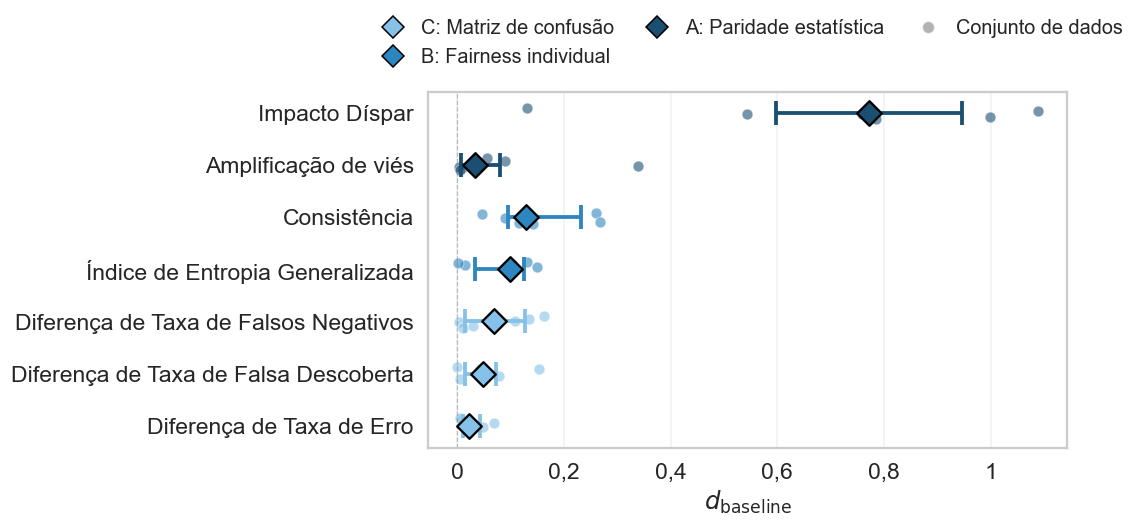

In [179]:
# Panorama do gap ao ideal — baseline típico (todas as métricas)
from auxiliar_analysis.bias_pattern_classifier import prepare_baseline_dataset_level

METRICS_PAPER = {
    "consistency",
    "generalized_entropy_index",
    "disparate_impact",
    "false_negative_rate_difference",
    "bias_amplification",
    "false_discovery_rate_difference",
    "error_rate_difference",
}

baseline_ds_paper = prepare_baseline_dataset_level(
    fairness_baseline,
    baseline_ids=["BLA", "BLU", "BRFA", "BRFU"],
    value_col="value_num",
)
baseline_ds_paper = baseline_ds_paper[baseline_ds_paper["metric"].isin(METRICS_PAPER)].copy()
 
plot_baseline_gap_overview(
    baseline_ds_paper,
    translate=translate,
    ratio_metrics={"disparate_impact"},
    save_path=RQ0_FIGS / "baseline_gap_overview.pdf",
)
plt.show()

Figura salva em: experiments\results\analysis\RQ0_baseline\figs\baseline_components_gap.pdf


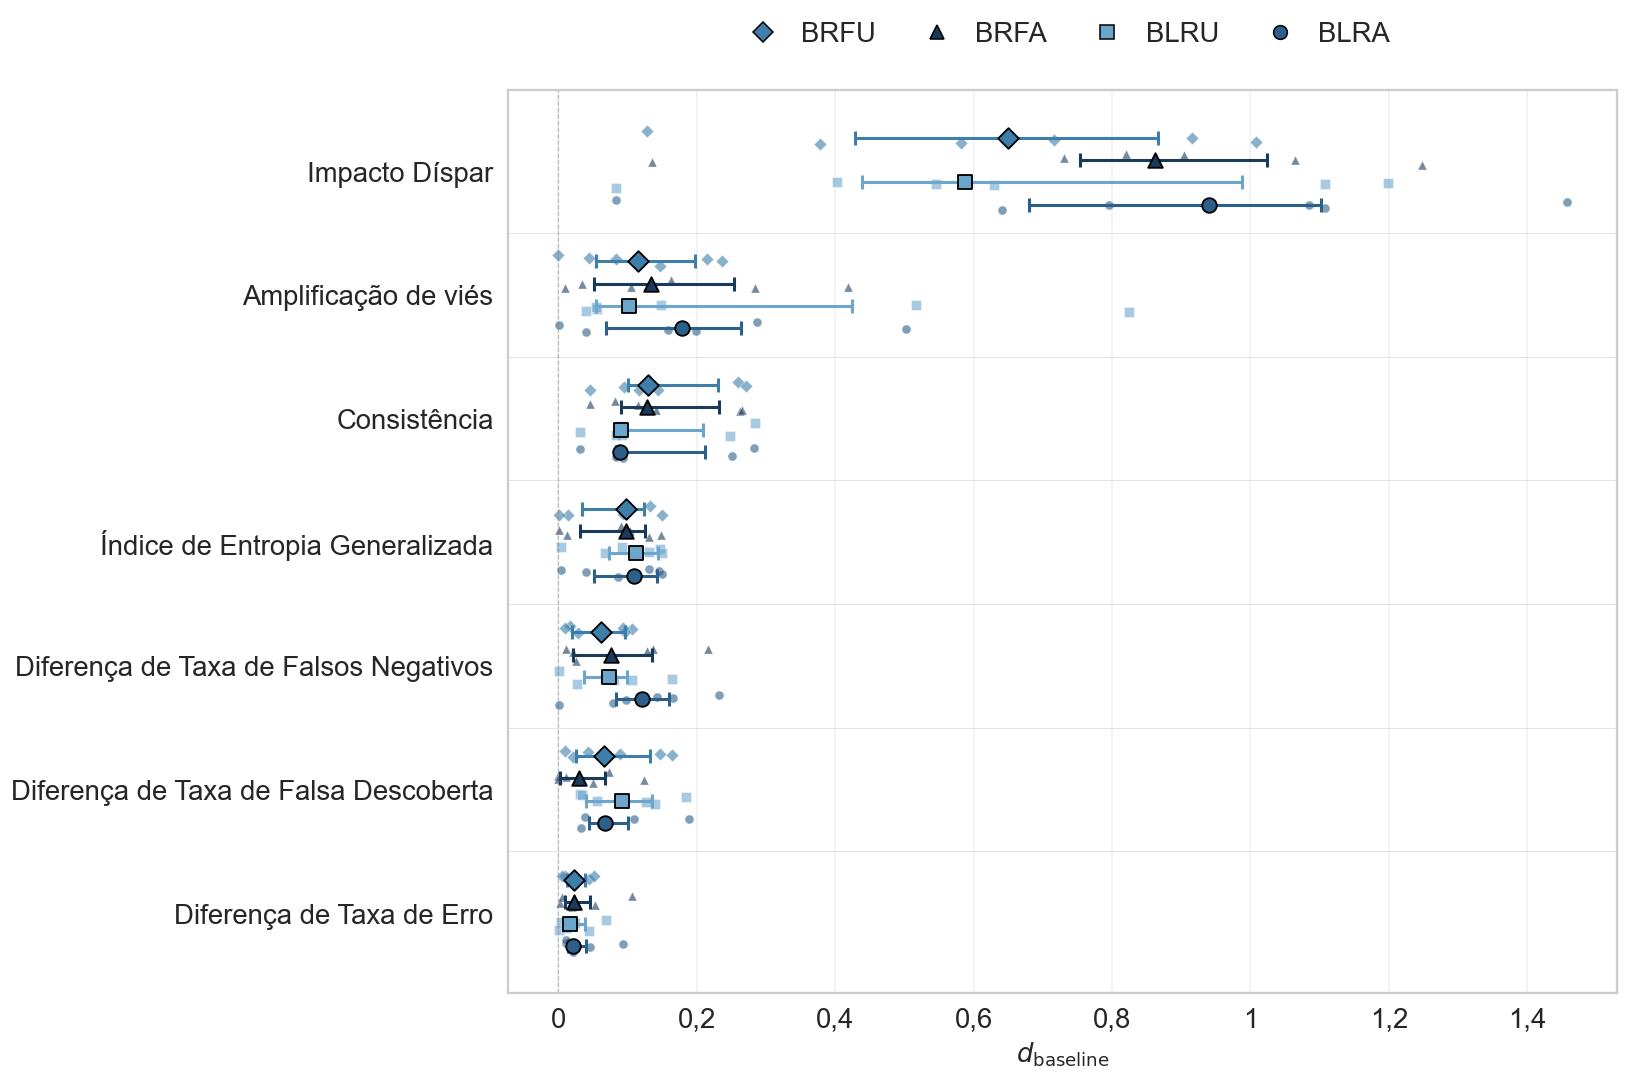

In [180]:
# Comparação dos 4 componentes do baseline típico (gap ao ideal)
from auxiliar_analysis import rq0_utils

rq0_utils._VIZ.update({
    "title_fontsize": 22,
    "label_fontsize": 17,
    "tick_fontsize": 18,
    "legend_fontsize": 18,
})

plot_baseline_components_gap(
    fairness_baseline,
    translate=translate,
    figsize=(15, 10),
    ratio_metrics={"disparate_impact"},
    baseline_ids=["BLRA", "BLRU", "BRFA", "BRFU"],
    save_path=RQ0_FIGS / "baseline_components_gap.pdf",
)
plt.show()

In [181]:
# Tabela descritiva do baseline típico por métrica de fairness
diag_table = build_baseline_diagnostic_table(
    baseline_ds_paper,
    translate=translate,
    result_dir=RQ0_TABLES,
)
display(diag_table[["Métrica", "n", "Mediana", "IQR", "Min", "Max"]])

Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq0_baseline_diagnostic.tex
| Métrica                               |   n |   Mediana |    IQR |     Min |    Max |
|:--------------------------------------|----:|----------:|-------:|--------:|-------:|
| Impacto Díspar                        |   6 |    1.3366 | 1.0027 |  0.4786 | 1.9996 |
| Amplificação de viés                  |   6 |    0.0309 | 0.0815 | -0.0083 | 0.339  |
| Consistência                          |   6 |    0.8716 | 0.1352 |  0.7329 | 0.9542 |
| Índice de Entropia Generalizada       |   6 |    0.0981 | 0.0904 |  0.0014 | 0.1492 |
| Diferença de Taxa de Falsos Negativos |   6 |   -0.0067 | 0.1045 | -0.1631 | 0.1343 |
| Diferença de Taxa de Falsa Descoberta |   6 |   -0.0028 | 0.0923 | -0.1528 | 0.0521 |
| Diferença de Taxa de Erro             |   6 |   -0.0133 | 0.0445 | -0.0683 | 0.0235 |


,Métrica,n,Mediana,IQR,Min,Max
0,Impacto Díspar,6,1.3366,1.0027,0.4786,1.9996
1,Amplificação de viés,6,0.0309,0.0815,-0.0083,0.3390
2,Consistência,6,0.8716,0.1352,0.7329,0.9542
3,Índice de Entropia Generalizada,6,0.0981,0.0904,0.0014,0.1492
4,Diferença de Taxa de Falsos Negativos,6,-0.0067,0.1045,-0.1631,0.1343
5,Diferença de Taxa de Falsa Descoberta,6,-0.0028,0.0923,-0.1528,0.0521
6,Diferença de Taxa de Erro,6,-0.0133,0.0445,-0.0683,0.0235


### 1.2 Caracterização das métricas de fairness e limiares de severidade

Tabela de caracterização com grupo operacional, faixa, valor ideal, estatísticas descritivas do baseline típico (mediana, IQR) e limiares de severidade calculados em unidades de IQR da distância ao ideal.

**Limiares de severidade (reconfiguráveis):**
- Baixo impacto: variação entre 0,5 e 1 IQR
- Impacto moderado: variação entre 1 e 1,5 × IQR
- Impacto severo: variação superior a 1,5 × IQR

In [182]:
# Limiares de severidade (reconfiguráveis)
GATING_MIN_UNITS = 0.5    # mínimo para elegibilidade
GATING_MEDIUM_UNITS = 1.0  # limiar para severidade média
GATING_HIGH_UNITS = 1.5    # limiar para severidade alta

# baseline_ds_paper e METRICS_PAPER já definidos na seção 1.1

# Tabela de caracterização das métricas + limiares
char_table = build_metric_characterization_table(
    baseline_ds_paper,
    translate=translate,
    ratio_metrics={"disparate_impact"},
    min_units=GATING_MIN_UNITS,
    medium_units=GATING_MEDIUM_UNITS,
    high_units=GATING_HIGH_UNITS,
    result_dir=RQ0_TABLES,
)

display_cols = [
    "Grupo", "Faixa", "Ideal", "Métrica", "n",
    "Mediana", "IQR", "Baixo impacto", "Impacto moderado", "Impacto severo",
]
display(char_table[display_cols])

Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq0_metric_characterization.tex
| Grupo                | Categoria   | Faixa               | Ideal    | Métrica                               |   n |   Mediana |   IQR | Baixo impacto   | Impacto moderado   | Impacto severo   |
|:---------------------|:------------|:--------------------|:---------|:--------------------------------------|----:|----------:|------:|:----------------|:-------------------|:-----------------|
| Paridade estatística | A           | $[0, \infty)$       | 1.0      | Impacto Díspar                        |   6 |      1.34 |  1    | 0.80 a 0.89     | 0.73 a 0.80        | < 0.73           |
|                      |             |                     |          |                                       |     |           |       | 1.12 a 1.25     | 1.25 a 1.38        | ou > 1.38        |
| Paridade estatística | A           | $(-\infty, \infty)$ | $\leq 0$ | Amplificação de viés                  |   

,Grupo,Faixa,Ideal,Métrica,n,Mediana,IQR,Baixo impacto,Impacto moderado,Impacto severo
0,Paridade estatística,"$[0, \infty)$",1.0,Impacto Díspar,6,1.34,1.00,0.80 a 0.89\n1.12 a 1.25,0.73 a 0.80\n1.25 a 1.38,< 0.73\nou > 1.38
1,Paridade estatística,"$(-\infty, \infty)$",$\leq 0$,Amplificação de viés,6,0.03,0.08,0.04 a 0.07,0.07 a 0.11,> 0.11
2,Fairness individual,"$[0, 1]$",1.0,Consistência,6,0.87,0.14,0.86 a 0.93,0.80 a 0.86,< 0.80
3,Fairness individual,"$[0, \infty)$",0.0,Índice de Entropia Generalizada,6,0.10,0.09,0.05 a 0.09,0.09 a 0.14,> 0.14
4,Matriz de confusão,"$(-\infty, \infty)$",0.0,Diferença de Taxa de Falsos Negativos,6,-0.01,0.10,|0.06 a 0.11|,|0.11 a 0.17|,> |0.17|
5,Matriz de confusão,"$(-\infty, \infty)$",0.0,Diferença de Taxa de Falsa Descoberta,6,-0.00,0.09,|0.03 a 0.06|,|0.06 a 0.09|,> |0.09|
6,Matriz de confusão,"$(-\infty, \infty)$",0.0,Diferença de Taxa de Erro,6,-0.01,0.04,|0.02 a 0.03|,|0.03 a 0.05|,> |0.05|


### 1.3 Cobertura do gating

Quantos datasets apresentam disparidade relevante (elegíveis) por métrica e categoria.

In [183]:
# Classificar padrões de viés (necessário para cobertura)
from auxiliar_analysis.bias_pattern_classifier import (
    classify_bias_patterns,
    print_classification_report,
)

classified, metric_scale = classify_bias_patterns(
    baseline_ds_paper,
    ideal_values=ideal_values,
    ratio_metrics={"disparate_impact"},
    min_units=GATING_MIN_UNITS,
    medium_units=GATING_MEDIUM_UNITS,
    high_units=GATING_HIGH_UNITS,
    return_scale=True,
)

# Cobertura do gating
coverage = compute_gating_coverage(
    classified,
    translate=translate,
    result_dir=RQ0_TABLES,
)
display(coverage[["Métrica", "Categoria", "Total datasets", "Elegíveis", "Cobertura (%)"]])

Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq0_gating_coverage.tex
| Categoria   | Métrica                               |   Elegíveis |   Eleg. cat. |   Cobertura (%) |
|:------------|:--------------------------------------|------------:|-------------:|----------------:|
| A           | Impacto Díspar                        |           5 |            5 |            83.3 |
| A           | Amplificação de viés                  |           3 |            5 |            83.3 |
| B           | Consistência                          |           5 |            5 |            83.3 |
| B           | Índice de Entropia Generalizada       |           4 |            5 |            83.3 |
| C           | Diferença de Taxa de Falsos Negativos |           3 |            4 |            66.7 |
| C           | Diferença de Taxa de Falsa Descoberta |           4 |            4 |            66.7 |
| C           | Diferença de Taxa de Erro             |           4 |            4

,Métrica,Categoria,Total datasets,Elegíveis,Cobertura (%)
0,Impacto Díspar,A,6,5,83.3
1,Amplificação de viés,A,6,3,83.3
2,Consistência,B,6,5,83.3
3,Índice de Entropia Generalizada,B,6,4,83.3
4,Diferença de Taxa de Falsos Negativos,C,6,3,66.7
5,Diferença de Taxa de Falsa Descoberta,C,6,4,66.7
6,Diferença de Taxa de Erro,C,6,4,66.7


### 1.4 Classificação de padrões de viés (A/B/C)

Cada combinação (dataset × categoria de métrica) é classificada em um padrão de viés com base na severidade e direção da disparidade no baseline. A classificação usa os limiares definidos em 1.2.

In [184]:
# Relatório detalhado de classificação de padrões
print_classification_report(classified, metric_scale)

RELATÓRIO DE CLASSIFICAÇÃO DE PADRÕES DE VIÉS

📊 CLASSIFICAÇÃO PRÓPRIA POR MÉTRICA
----------------------------------------------------------------------

bias_amplification:
  Total datasets: 6
  Elegíveis (próprio): 3 (50.0%)
  Distribuição de severidade (própria):
    - Nível 1 (alto): 1
    - Nível 2 (médio): 1
    - Nível 3 (baixo): 1
  (Métrica sem direção de viés)

consistency:
  Total datasets: 6
  Elegíveis (próprio): 5 (83.3%)
  Distribuição de severidade (própria):
    - Nível 1 (alto): 2
    - Nível 2 (médio): 1
    - Nível 3 (baixo): 2
  (Métrica sem direção de viés)

disparate_impact:
  Total datasets: 6
  Elegíveis (próprio): 5 (83.3%)
  Distribuição de severidade (própria):
    - Nível 1 (alto): 5
  Direção do viés (própria):
    - P (contra privilegiado): 3
    - U (contra não-privilegiado): 2

error_rate_difference:
  Total datasets: 6
  Elegíveis (próprio): 4 (66.7%)
  Distribuição de severidade (própria):
    - Nível 1 (alto): 2
    - Nível 3 (baixo): 2
  Direção do

In [185]:
labels = classified[["dataset","metric","eligible","severity_level","pattern_code","direction"]].drop_duplicates()

df = df.merge(labels, on=["dataset","metric"], how="left")
df[df.metric=='bias_amplification']


,exp_id,fold,repetition_id,execution_id,metric,value,metric_type,dataset,exp_type,category,experiment_pipeline_type,metric_group,value_num,eligible,severity_level,pattern_code,direction
30,BLRA,0,0,BLRA__rep0__fold0__4_heart_disease,bias_amplification,0.294581,fairness,4_heart_disease,baseline,baseline,baseline,logarithmic_difference_based,0.294581,True,1.0,A1U,U
31,BLRA,1,0,BLRA__rep0__fold1__4_heart_disease,bias_amplification,-0.084908,fairness,4_heart_disease,baseline,baseline,baseline,logarithmic_difference_based,-0.084908,True,1.0,A1U,U
32,BLRA,2,0,BLRA__rep0__fold2__4_heart_disease,bias_amplification,0.003457,fairness,4_heart_disease,baseline,baseline,baseline,logarithmic_difference_based,0.003457,True,1.0,A1U,U
33,BLRA,3,0,BLRA__rep0__fold3__4_heart_disease,bias_amplification,0.408289,fairness,4_heart_disease,baseline,baseline,baseline,logarithmic_difference_based,0.408289,True,1.0,A1U,U
34,BLRA,4,0,BLRA__rep0__fold4__4_heart_disease,bias_amplification,0.14842,fairness,4_heart_disease,baseline,baseline,baseline,logarithmic_difference_based,0.148420,True,1.0,A1U,U
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28285,IW,25,0,IW__rep0__fold25__16_diabetes,bias_amplification,-0.653926,fairness,16_diabetes,method,in_processing,in_processing,logarithmic_difference_based,-0.653926,True,1.0,A1P,P
28286,IW,26,0,IW__rep0__fold26__16_diabetes,bias_amplification,-0.606298,fairness,16_diabetes,method,in_processing,in_processing,logarithmic_difference_based,-0.606298,True,1.0,A1P,P
28287,IW,27,0,IW__rep0__fold27__16_diabetes,bias_amplification,-0.226988,fairness,16_diabetes,method,in_processing,in_processing,logarithmic_difference_based,-0.226988,True,1.0,A1P,P
28288,IW,28,0,IW__rep0__fold28__16_diabetes,bias_amplification,-1.058801,fairness,16_diabetes,method,in_processing,in_processing,logarithmic_difference_based,-1.058801,True,1.0,A1P,P


In [186]:
df.pattern_code.value_counts()

pattern_code
C1P    2160
A1P    2160
A1U    1440
B2     1440
B1     1440
C2P    1080
C2U    1080
B3      720
Name: count, dtype: int64

In [187]:
# RQ0 — Tabela automática: conjuntos de dados × padrões de viés
from auxiliar_analysis.analysis_utils import build_bias_pattern_table

bias_pattern_latex = build_bias_pattern_table(
    classified=classified,
    translate=translate,
    result_dir=RQ0_TABLES,
)
print(bias_pattern_latex)


Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq0_bias_patterns_datasets.tex
\begin{table}[H]
\centering
\scriptsize
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1,15}
\caption{Conjuntos de dados por padrão final de viés (categoria, severidade e sentido).}
\label{tab_rq0_bias_patterns_datasets}
\begin{tabular}{@{} l c c  c c c c c @{}}
\toprule
\textbf{Padrão de viés} & \textbf{Severidade} & \textbf{Sentido} & \textbf{Arrhythmia} & \textbf{Mental} & \textbf{Diabetes} & \textbf{Heart Disease} & \textbf{Aids} \\
\midrule
\multirow{2}{*}{\textbf{Paridade Estatística (A)}} & 1 & P &  & x & x &  & x \\
 & 1 & U & x &  &  & x &  \\
\midrule
\multirow{3}{*}{\textbf{Individual (B)}} & 1 & --- & x & x &  &  &  \\
 & 2 & --- &  &  &  & x & x \\
 & 3 & --- &  &  & x &  &  \\
\midrule
\multirow{3}{*}{\textbf{Matriz de Confusão (C)}} & 1 & P &  & x &  & x &  \\
 & 2 & P &  &  &  &  & x \\
 & 2 & U & x &  &  &  &  \\
\bottomrule
\end{tabular}
\end{table}


In [188]:
# RQ0 — Tabela de elegibilidade e sentido de viés por dataset
elig_table = build_eligibility_direction_table(
    classified_df=classified,
    baseline_ds=baseline_ds_paper,
    translate=translate,
    result_dir=RQ0_TABLES,
)
display(elig_table)

Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq0_eligibility_direction.tex
| category   | metric                                | ideal    |   d_min | Arrhythmia   | Mental      | Diabetes     | Heart Disease   | Aids        | Obesity      |
|:-----------|:--------------------------------------|:---------|--------:|:-------------|:------------|:-------------|:----------------|:------------|:-------------|
| A          | Impacto Díspar                        | 1.0      |    0.17 | (0.79, 'U')  | (0.54, 'P') | (1.0, 'P')   | (1.09, 'U')     | (0.76, 'P') | (0.13, None) |
| A          | Amplificação de viés                  | $\leq 0$ |    0.04 | (0.09, '✓')  | (0.06, '✓') | (0.01, None) | ---             | (0.34, '✓') | (0.01, None) |
| B          | Consistência                          | 1.0      |    0.07 | (0.26, '✓')  | (0.27, '✓') | (0.09, '✓')  | (0.14, '✓')     | (0.12, '✓') | (0.05, None) |
| B          | Índice de Entropia Generalizada       | 0.0      |

,category,metric,ideal,d_min,Arrhythmia,Mental,Diabetes,Heart Disease,Aids,Obesity
0,A,Impacto Díspar,1.0,0.17,"(0.79, U)","(0.54, P)","(1.0, P)","(1.09, U)","(0.76, P)","(0.13, None)"
1,A,Amplificação de viés,$\leq 0$,0.04,"(0.09, ✓)","(0.06, ✓)","(0.01, None)",---,"(0.34, ✓)","(0.01, None)"
2,B,Consistência,1.0,0.07,"(0.26, ✓)","(0.27, ✓)","(0.09, ✓)","(0.14, ✓)","(0.12, ✓)","(0.05, None)"
3,B,Índice de Entropia Generalizada,0.0,0.05,"(0.1, ✓)","(0.15, ✓)","(0.01, None)","(0.09, ✓)","(0.13, ✓)",---
4,C,Diferença de Taxa de Falsos Negativos,0.0,0.06,"(0.13, U)","(0.16, P)",---,"(0.03, None)","(0.11, P)","(0.01, None)"
5,C,Diferença de Taxa de Falsa Descoberta,0.0,0.03,"(0.04, U)","(0.15, P)","(0.01, None)","(0.05, U)","(0.08, P)",---
6,C,Diferença de Taxa de Erro,0.0,0.02,"(0.02, P)","(0.05, P)","(0.01, None)","(0.07, P)","(0.02, U)","(0.01, None)"


## 1.1) RQ0.2 — Baseline em desempenho preditivo: diagnóstico curto

**Objetivo:** Contextualizar o nível absoluto de desempenho preditivo (F1) no baseline típico, antes de analisar trade-offs nas RQs seguintes.

- Nível absoluto e variabilidade do F1 no baseline típico (por dataset).
- **Não compara métodos de mitigação aqui** (isso fica para RQ3).

In [189]:
# Tabela de desempenho preditivo do baseline típico (total + por dataset)
perf_baseline = baseline_df[baseline_df.metric_type == "performance"]

# --- Total (agregado sobre todos os datasets) ---
perf_stats_total = save_table(
    perf_baseline,
    ideal_values=ideal_values,
    group_list=["metric"],
    stats=("median", "iqr", "min", "max"),
    caption="Estatísticas de desempenho preditivo do \textit{baseline} (total)",
    label="tab_rq0_performance_baseline",
    result_dir=RQ0_TABLES,
    translate=translate,
    multirow_cols=["metric"],
)
display(perf_stats_total)

# --- Por conjunto de dados ---
perf_stats_ds = save_table(
    perf_baseline,
    ideal_values=ideal_values,
    group_list=["metric", "dataset"],
    stats=("median", "iqr", "min", "max"),
    caption="Estatísticas de desempenho preditivo do \textit{baseline}",
    label="tab_rq0_performance_baseline_dataset",
    result_dir=RQ0_TABLES,
    translate=translate,
    multirow_cols=["metric"],
    group_col="metric",
    longtable=True,
)
display(perf_stats_ds)


Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq0_performance_baseline.tex
| metric    |   median |      iqr |      min |      max |
|:----------|---------:|---------:|---------:|---------:|
| accuracy  | 0.806147 | 0.147163 | 0.701691 | 0.994318 |
| f1        | 0.765951 | 0.208404 | 0.39104  | 0.990408 |
| precision | 0.804189 | 0.210327 | 0.625833 | 0.990361 |
| recall    | 0.740338 | 0.207252 | 0.281609 | 0.995169 |


,metric,median,iqr,min,max
0,accuracy,0.806147,0.147163,0.701691,0.994318
1,f1,0.765951,0.208404,0.391040,0.990408
2,precision,0.804189,0.210327,0.625833,0.990361
3,recall,0.740338,0.207252,0.281609,0.995169


Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq0_performance_baseline_dataset.tex
| metric    | dataset         |   median |        iqr |      min |      max |
|:----------|:----------------|---------:|-----------:|---------:|---------:|
| accuracy  | 11_arrhythmia   | 0.766667 | 0.0940728  | 0.613333 | 0.86755  |
| accuracy  | 15_mental       | 0.701691 | 0.02657    | 0.651332 | 0.748792 |
| accuracy  | 16_diabetes     | 0.948126 | 0.0753106  | 0.83908  | 1        |
| accuracy  | 4_heart_disease | 0.828283 | 0.0606061  | 0.727273 | 0.888889 |
| accuracy  | 6_aids          | 0.784011 | 0.0129734  | 0.764376 | 0.805049 |
| accuracy  | 7_obesity       | 0.994318 | 0.00425732 | 0.988636 | 1        |
| f1        | 11_arrhythmia   | 0.727304 | 0.0991581  | 0.57971  | 0.846154 |
| f1        | 15_mental       | 0.70483  | 0.0267444  | 0.649351 | 0.758621 |
| f1        | 16_diabetes     | 0.956938 | 0.0628789  | 0.865979 | 1        |
| f1        | 4_heart_disease | 0.8

,metric,dataset,median,iqr,min,max
0,accuracy,11_arrhythmia,0.766667,0.094073,0.613333,0.867550
1,accuracy,15_mental,0.701691,0.026570,0.651332,0.748792
2,accuracy,16_diabetes,0.948126,0.075311,0.839080,1.000000
3,accuracy,4_heart_disease,0.828283,0.060606,0.727273,0.888889
4,accuracy,6_aids,0.784011,0.012973,0.764376,0.805049
5,accuracy,7_obesity,0.994318,0.004257,0.988636,1.000000
6,f1,11_arrhythmia,0.727304,0.099158,0.579710,0.846154
7,f1,15_mental,0.704830,0.026744,0.649351,0.758621
8,f1,16_diabetes,0.956938,0.062879,0.865979,1.000000
9,f1,4_heart_disease,0.804598,0.062403,0.682353,0.881720


## 1.2) RQ0.3 — Desempenho preditivo dos experimentos: diagnóstico

**Objetivo:** Contextualizar o nível de desempenho preditivo dos métodos de mitigação,
permitindo avaliar se as estratégias de fairness comprometem a capacidade preditiva.
Tabelas descritivas (mediana, IQR, min, max) por métrica, por categoria e por dataset.

In [190]:
experiment_df = df[df['exp_type'] != 'baseline']
perf_experiment = experiment_df[experiment_df.metric_type == 'performance']

# Inclui baselines para tabela detalhada por dataset
perf_all = df[df.metric_type == 'performance']


In [191]:
fairness_stats = save_table(
    perf_experiment,
    ideal_values=ideal_values,
    group_list=['metric'],
    stats=('median', 'iqr', 'min', 'max'),
    caption="Desempenho preditivo dos experimentos (todas as métricas)",
    label="tab_rq03_performance_experiment",
    result_dir=RQ0_TABLES,
    translate=translate,
    multirow_cols=['metric'],
    longtable=True,
)


Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq03_performance_experiment.tex
| metric    |   median |      iqr |      min |      max |
|:----------|---------:|---------:|---------:|---------:|
| accuracy  | 0.789593 | 0.140367 | 0.683575 | 0.990761 |
| f1        | 0.732193 | 0.199898 | 0.396118 | 0.984475 |
| precision | 0.749999 | 0.191802 | 0.608946 | 0.976303 |
| recall    | 0.720299 | 0.220615 | 0.293103 | 0.995169 |


In [192]:
fairness_stats = save_table(
    perf_experiment,
    ideal_values=ideal_values,
    group_list=['metric', 'experiment_pipeline_type'],
    stats=('median', 'iqr', 'min', 'max'),
    caption="Desempenho preditivo por categoria de mitigação",
    label="tab_rq03_performance_by_category",
    result_dir=RQ0_TABLES,
    translate=translate,
    multirow_cols=['metric', 'experiment_pipeline_type'],
    group_col='metric',
    longtable=True,
)


Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq03_performance_by_category.tex
| metric    | experiment_pipeline_type   |   median |      iqr |      min |      max |
|:----------|:---------------------------|---------:|---------:|---------:|---------:|
| accuracy  | in_processing              | 0.784542 | 0.125628 | 0.679177 | 0.991471 |
| accuracy  | pre_processing             | 0.805796 | 0.160582 | 0.697682 | 0.990043 |
| f1        | in_processing              | 0.722182 | 0.189135 | 0.396118 | 0.98568  |
| f1        | pre_processing             | 0.75438  | 0.220517 | 0.396845 | 0.983253 |
| precision | in_processing              | 0.746305 | 0.188607 | 0.605823 | 0.976303 |
| precision | pre_processing             | 0.780883 | 0.206441 | 0.619048 | 0.976247 |
| recall    | in_processing              | 0.707921 | 0.224843 | 0.293103 | 1        |
| recall    | pre_processing             | 0.735779 | 0.196748 | 0.288187 | 0.992754 |


In [193]:
# Desempenho preditivo por método individual
fairness_stats_method = save_table(
    perf_experiment,
    ideal_values=ideal_values,
    group_list=['metric', 'exp_id'],
    stats=('median', 'iqr', 'min', 'max'),
    caption="Desempenho preditivo por método de mitigação",
    label="tab_rq03_performance_by_method",
    result_dir=RQ0_TABLES,
    translate=translate,
    multirow_cols=['metric', 'exp_id'],
    group_col='metric',
    longtable=True,
)


Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq03_performance_by_method.tex
| metric    | exp_id   |   median |       iqr |      min |      max |
|:----------|:---------|---------:|----------:|---------:|---------:|
| accuracy  | EDL      | 0.816248 | 0.174339  | 0.672185 | 0.985785 |
| accuracy  | ERL      | 0.800045 | 0.141699  | 0.70012  | 0.992898 |
| accuracy  | IAD      | 0.798713 | 0.136159  | 0.685607 | 0.992898 |
| accuracy  | IFG      | 0.81404  | 0.140058  | 0.684402 | 0.997157 |
| accuracy  | IGLA     | 0.785945 | 0.11684   | 0.693237 | 0.985085 |
| accuracy  | IGLU     | 0.782368 | 0.09734   | 0.668681 | 0.985795 |
| accuracy  | IP       | 0.773319 | 0.0966738 | 0.659008 | 0.99005  |
| accuracy  | IW       | 0.790996 | 0.156427  | 0.680387 | 0.994318 |
| f1        | EDL      | 0.763421 | 0.258913  | 0.402893 | 0.975786 |
| f1        | ERL      | 0.744851 | 0.196415  | 0.371731 | 0.988067 |
| f1        | IAD      | 0.765683 | 0.206075  | 0.421079 | 

In [194]:
for dataset in perf_all["dataset"].unique():
    df_filtered = perf_all[perf_all["dataset"] == dataset]
    print(dataset)
    fairness_stats = save_table(
        df_filtered,
        ideal_values=ideal_values,
        group_list=['metric', 'exp_id'],
        stats=('median', 'iqr', 'min', 'max'),
        caption=f"Estatísticas de desempenho por experimento e conjunto --- {translate.get(dataset, dataset)}",
        label=f"tab_rq03_performance_{dataset}",
        result_dir=RQ0_TABLES,
        translate=translate,
        multirow_cols=['metric', 'exp_id'],
        group_col='metric',
        longtable=True,
    )

4_heart_disease
Tabela salva em: experiments\results\analysis\RQ0_baseline\tables\tab_rq03_performance_4_heart_disease.tex
| metric    | exp_id   |   median |       iqr |      min |      max |
|:----------|:---------|---------:|----------:|---------:|---------:|
| accuracy  | BLRA     | 0.838384 | 0.040404  | 0.777778 | 0.878788 |
| accuracy  | BLRU     | 0.828283 | 0.0580808 | 0.767677 | 0.878788 |
| accuracy  | BRFA     | 0.818182 | 0.0606061 | 0.727273 | 0.888889 |
| accuracy  | BRFU     | 0.818182 | 0.0479798 | 0.747475 | 0.878788 |
| accuracy  | EDL      | 0.848485 | 0.0505051 | 0.757576 | 0.888889 |
| accuracy  | ERL      | 0.818182 | 0.0681818 | 0.757576 | 0.888889 |
| accuracy  | IAD      | 0.823232 | 0.040404  | 0.707071 | 0.888889 |
| accuracy  | IFG      | 0.808081 | 0.0656566 | 0.737374 | 0.878788 |
| accuracy  | IGLA     | 0.787879 | 0.040404  | 0.69697  | 0.838384 |
| accuracy  | IGLU     | 0.782828 | 0.0808081 | 0.676768 | 0.858586 |
| accuracy  | IP       | 0.762626 | 0

## 2) RQ1 — Quais estratégias têm melhor efeito (global)?

**Objetivo:** Panorama geral de eficácia **sem estratificação** (todas as métricas × datasets).

**Análises:**
- Δfairness por **categoria de mitigação** (Pre-processing vs In-processing): uma visualização por métrica + win rate
- Δfairness por **método individual**: uma visualização por métrica
- Ranking + teste de Friedman (se N suficiente); Holm completo no apêndice
- **SEM gating**: análise global inclui todos os datasets
- **SEM agregação entre métricas**: cada métrica é analisada separadamente

### 2.1 Δfairness por categoria de mitigação (Pre-processing vs In-processing)

Para cada métrica de fairness, calcula-se Δfairness = d(baseline) − d(método) por categoria.  
Valores positivos indicam melhora em fairness em relação ao baseline típico.

In [195]:
# === Controle de fontes — RQ1 ===
from auxiliar_analysis import rq1_utils

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 15,
    "legend_fontsize": 14,
})



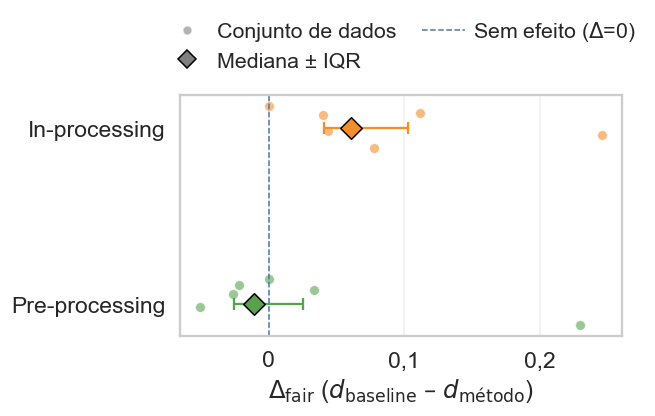

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_category_bias_amplification.tex
| category       |   n |     median |       iqr |        min |      max |
|:---------------|----:|-----------:|----------:|-----------:|---------:|
| in_processing  |   6 |  0.0604585 | 0.0622137 |  0         | 0.245728 |
| pre_processing |   6 | -0.011029  | 0.0505591 | -0.0508137 | 0.229526 |


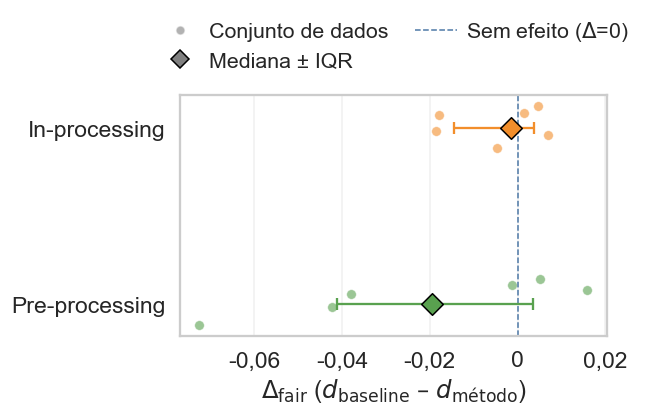

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_category_consistency.tex
| category       |   n |      median |       iqr |        min |        max |
|:---------------|----:|------------:|----------:|-----------:|-----------:|
| in_processing  |   6 | -0.00155972 | 0.0183712 | -0.0186869 | 0.00687237 |
| pre_processing |   6 | -0.0195299  | 0.0447473 | -0.0725105 | 0.015894   |


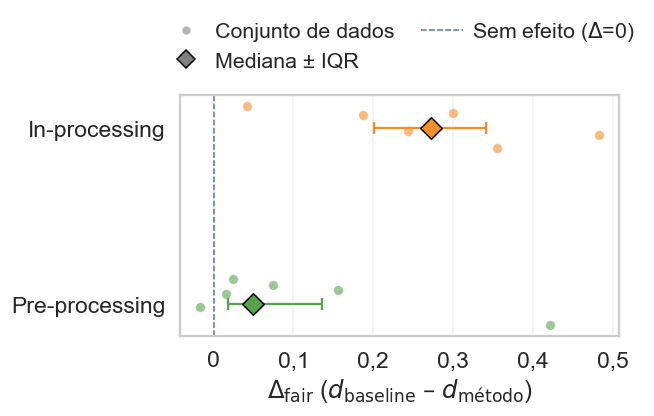

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_category_disparate_impact.tex
| category       |   n |   median |      iqr |        min |     max |
|:---------------|----:|---------:|---------:|-----------:|--------:|
| in_processing  |   6 | 0.272164 | 0.140523 |  0.0415829 | 0.48285 |
| pre_processing |   6 | 0.048987 | 0.117613 | -0.017332  | 0.42169 |


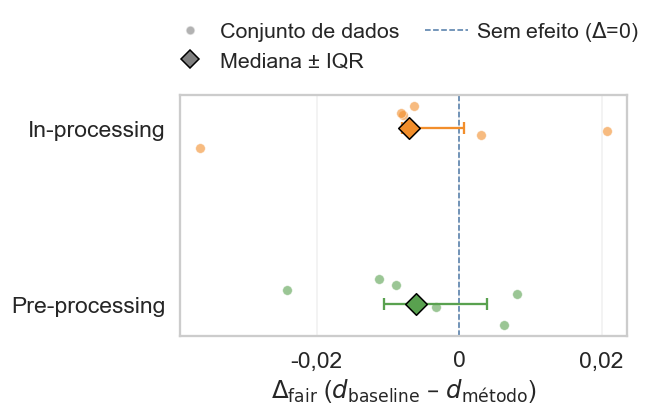

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_category_error_rate_difference.tex
| category       |   n |      median |        iqr |        min |        max |
|:---------------|----:|------------:|-----------:|-----------:|-----------:|
| in_processing  |   6 | -0.00708758 | 0.00879948 | -0.0363797 | 0.0207556  |
| pre_processing |   6 | -0.00608083 | 0.0145007  | -0.0241431 | 0.00804571 |


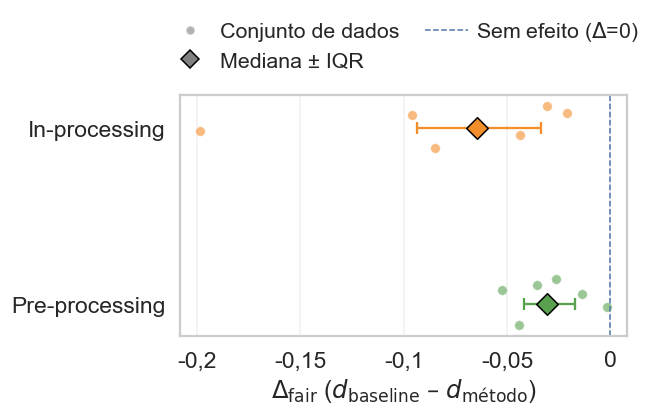

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_category_false_discovery_rate_difference.tex
| category       |   n |     median |       iqr |        min |         max |
|:---------------|----:|-----------:|----------:|-----------:|------------:|
| in_processing  |   6 | -0.0642803 | 0.0596823 | -0.198519  | -0.0210201  |
| pre_processing |   6 | -0.0307701 | 0.0250038 | -0.0522914 | -0.00147036 |


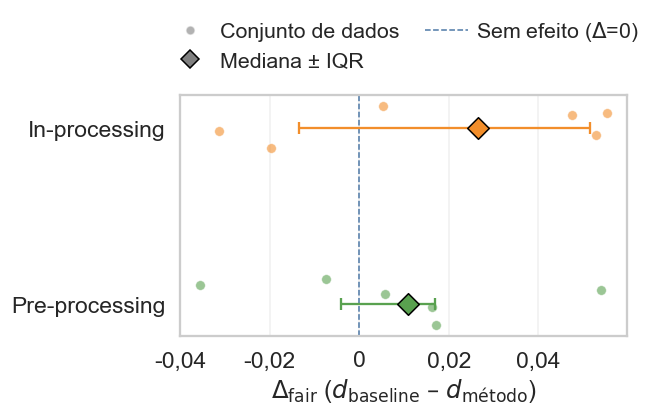

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_category_false_negative_rate_difference.tex
| category       |   n |    median |       iqr |        min |       max |
|:---------------|----:|----------:|----------:|-----------:|----------:|
| in_processing  |   6 | 0.0263871 | 0.0650002 | -0.0312747 | 0.0553249 |
| pre_processing |   6 | 0.010964  | 0.0210587 | -0.0355368 | 0.0539733 |


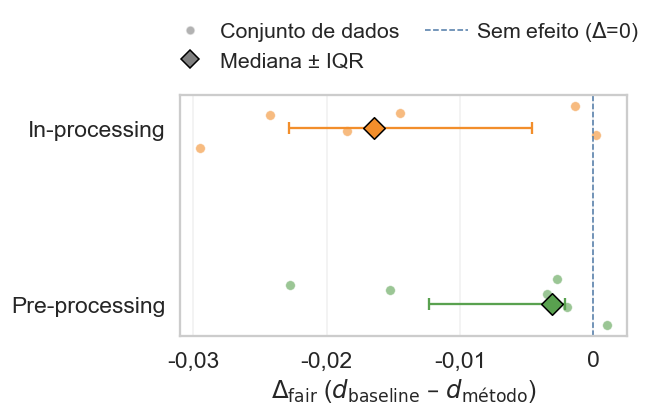

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_category_generalized_entropy_index.tex
| category       |   n |      median |       iqr |        min |         max |
|:---------------|----:|------------:|----------:|-----------:|------------:|
| in_processing  |   6 | -0.0164733  | 0.0181806 | -0.0294947 | 0.000209127 |
| pre_processing |   6 | -0.00309577 | 0.0101519 | -0.0227686 | 0.00103355  |


In [196]:
# RQ1 — Δfairness por categoria (pre vs in) — uma figura por métrica
metrics_rq1 = sorted(list(METRICS_PAPER))

for m in metrics_rq1:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="all",
    )
    if delta_cat.empty:
        continue

    metric_label = translate.get(m, m)

    # Figura: scatter + box por categoria
    plot_delta_fairness_category(
        delta_cat, metric=m, translate=translate, figsize = (6, 4),
        save_path=RQ1_FIGS / f"delta_fairness_by_category_{m}.pdf",
    )

    # Tabela: Δfairness por categoria
    save_delta_table(
        delta_cat, group_cols=["category"],
        caption=f"Δfairness por categoria — {metric_label} (\textit{{baseline}} como referência)",
        label=f"tab_rq1_delta_fair_category_{m}",
        result_dir=RQ1_TABLES,
    )

In [197]:
# Win rate por categoria: proporção de datasets com Δfair > 0 (melhora)
winrate_rows = []

for m in metrics_rq1:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="all",
    )
    if delta_cat.empty:
        continue
    wr = compute_win_rate(delta_cat, group_col="category")
    wr["metric"] = m
    winrate_rows.append(wr)

if winrate_rows:
    winrate_df = pd.concat(winrate_rows, ignore_index=True)
    winrate_df["metric_label"] = winrate_df["metric"].map(
        lambda x: translate.get(x, x)
    )
    winrate_df["win_rate_pct"] = (winrate_df["win_rate"] * 100).round(1)

    display(
        winrate_df[["metric_label", "category", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica",
            "category": "Categoria",
            "n": "N datasets",
            "wins": "Vitórias (Δ>0)",
            "win_rate_pct": "Win rate (%)",
        })
    )

    # Salvar tabela LaTeX
    latex_and_save(
        winrate_df[["metric_label", "category", "n", "wins", "win_rate_pct"]],
        caption="Win rate por categoria — proporção de datasets com melhora em fairness",
        label="tab_rq1_winrate_category",
        result_dir=RQ1_TABLES,
    )

,Métrica,Categoria,N datasets,Vitórias (Δ>0),Win rate (%)
0,Amplificação de viés,in_processing,6,5,83.3
1,Amplificação de viés,pre_processing,6,2,33.3
2,Consistência,in_processing,6,3,50.0
3,Consistência,pre_processing,6,2,33.3
4,Impacto Díspar,in_processing,6,6,100.0
5,Impacto Díspar,pre_processing,6,5,83.3
6,Diferença de Taxa de Erro,in_processing,6,2,33.3
7,Diferença de Taxa de Erro,pre_processing,6,2,33.3
8,Diferença de Taxa de Falsa Descoberta,in_processing,6,0,0.0
9,Diferença de Taxa de Falsa Descoberta,pre_processing,6,0,0.0


Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_winrate_category.tex
| metric_label                          | category       |   n |   wins |   win_rate_pct |
|:--------------------------------------|:---------------|----:|-------:|---------------:|
| Amplificação de viés                  | in_processing  |   6 |      5 |           83.3 |
| Amplificação de viés                  | pre_processing |   6 |      2 |           33.3 |
| Consistência                          | in_processing  |   6 |      3 |           50   |
| Consistência                          | pre_processing |   6 |      2 |           33.3 |
| Impacto Díspar                        | in_processing  |   6 |      6 |          100   |
| Impacto Díspar                        | pre_processing |   6 |      5 |           83.3 |
| Diferença de Taxa de Erro             | in_processing  |   6 |      2 |           33.3 |
| Diferença de Taxa de Erro             | pre_processing |   6 |      2 |           33.3 |
| Di

In [198]:
# Teste estatístico: Friedman (omnibus) + Holm (pós-hoc) por CATEGORIA
stats_cat = run_all_category_analysis(df, ideal_values=ideal_values, scopes=["all"])

save_results_latex(
    stats_cat,
    metric='',
    analysis_type="category",
    save_dir=RQ1_TABLES,
    translate=translate,
    cols_omnibus=cols_omnibus,
    cols_posthoc=cols_posthoc,
    scope_suffix="all"
)

stats_cat_omnibus = stats_cat.loc[stats_cat["test"] == "friedman"].copy()
stats_cat_posthoc = stats_cat.loc[stats_cat["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por categoria ===")
display(stats_cat_omnibus[cols_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico ===")
display(stats_cat_posthoc[cols_posthoc])


  error_rate_difference - Análise por Categoria

📊 Teste Friedman (omnibus)
   N datasets: 6, k métodos: 3
   Estatística = 1.0000, p = 0.6065
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Categoria            Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.0317       0.0000         0.0000       -0.0067      0.0323     6
   pre_processing       0.0447       -0.0061        0.0145       -0.0121      0.0193     6
   in_processing        0.0474       -0.0071        0.0088       0.0133       0.0055     6

📊 Pós-hoc vs baseline_typical (Holm)
   (* p<0.05, ** p<0.01, *** p<0.001)
| category       |   avg_rank |   delta_rank |     z |   p_raw |   p_holm | reject_holm   |   median_delta_fair |   iqr_delta_fair |   median_d |
|:---------------|-----------:|--

d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:658: UserWarning: Métodos removidos (sem dados): {'in_processing', 'baseline_typical'}. Continuando com 1 métodos.
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:668: UserWarning: Teste requer pelo menos 2 métodos com dados. Encontrados: 1. Retornando resultados vazios.
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:658: UserWarning: Métodos removidos (sem dados): {'in_processing', 'baseline_typical'}. Continuando com 1 métodos.
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:668: UserWarning: Teste requer pelo menos 2 métodos com dados. Encontrados: 1. Retornando resultados vazios.
  warnings.warn(


,metric,category,p_value,median_delta_fair,iqr_delta_fair
0,error_rate_difference,baseline_typical,0.606531,0.000000,0.000000
1,error_rate_difference,pre_processing,0.606531,-0.006081,0.014501
2,error_rate_difference,in_processing,0.606531,-0.007088,0.008799
5,bias_amplification,baseline_typical,0.022371,0.000000,0.000000
6,bias_amplification,pre_processing,0.022371,-0.011029,0.050559
7,bias_amplification,in_processing,0.022371,0.060458,0.062214
10,false_discovery_rate_difference,baseline_typical,0.005704,0.000000,0.000000
11,false_discovery_rate_difference,pre_processing,0.005704,-0.030770,0.025004
12,false_discovery_rate_difference,in_processing,0.005704,-0.064280,0.059682
15,consistency,baseline_typical,0.846482,0.000000,0.000000



=== Pós-hoc (Holm) vs baseline típico ===


,metric,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
3,error_rate_difference,pre_processing,2.166667,1.000000,-0.006081,0.014501
4,error_rate_difference,in_processing,2.166667,1.000000,-0.007088,0.008799
8,bias_amplification,pre_processing,2.500000,0.613585,-0.011029,0.050559
9,bias_amplification,in_processing,1.166667,0.043308,0.060458,0.062214
13,false_discovery_rate_difference,pre_processing,2.166667,1.000000,-0.030770,0.025004
14,false_discovery_rate_difference,in_processing,2.833333,1.000000,-0.064280,0.059682
18,consistency,pre_processing,2.166667,1.000000,-0.019530,0.044747
19,consistency,in_processing,2.000000,1.000000,-0.001560,0.018371
23,generalized_entropy_index,pre_processing,2.000000,1.000000,-0.003096,0.010152
24,generalized_entropy_index,in_processing,2.666667,1.000000,-0.016473,0.018181


### 2.2 Δfairness por método individual

Para cada métrica, calcula-se Δfairness por método individual.  
Inclui: figuras (scatter+box), tabelas descritivas, win rate, e ranking + Friedman por método.

In [199]:
# === Controle de fontes — RQ1 ===
from auxiliar_analysis import rq1_utils

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 16,
    "legend_fontsize": 14,
})



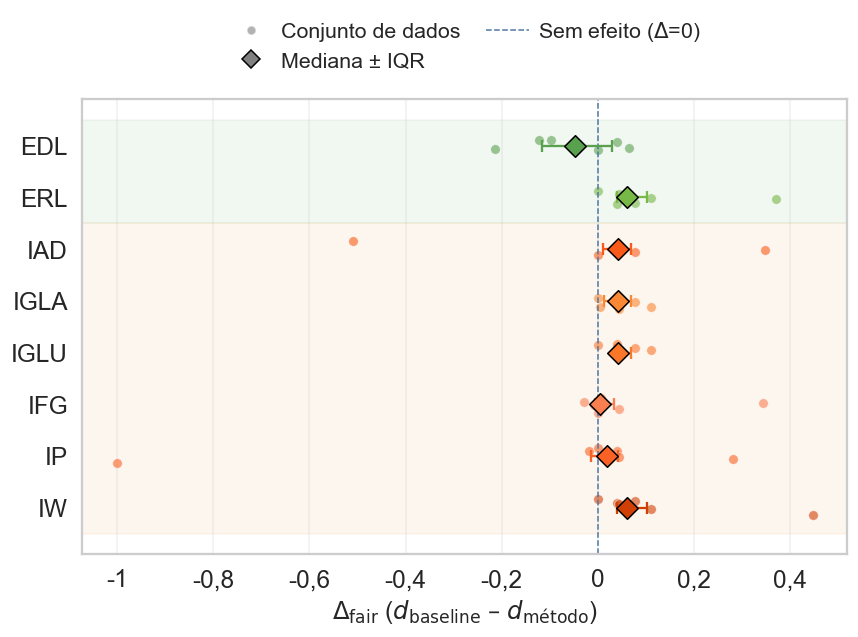

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_method_bias_amplification.tex
| method   | category       |   n |      median |       iqr |        min |       max |
|:---------|:---------------|----:|------------:|----------:|-----------:|----------:|
| EDL      | pre_processing |   6 | -0.0484346  | 0.145176  | -0.212929  | 0.0638766 |
| ERL      | pre_processing |   6 |  0.0604585  | 0.0622137 |  0         | 0.370735  |
| IAD      | in_processing  |   6 |  0.0415691  | 0.0590415 | -0.509065  | 0.347873  |
| IFG      | in_processing  |   6 |  0.00369024 | 0.0410985 | -0.0288706 | 0.343151  |
| IGLA     | in_processing  |   6 |  0.0415691  | 0.0560428 |  0         | 0.111302  |
| IGLU     | in_processing  |   6 |  0.0415691  | 0.0299014 |  0         | 0.111302  |
| IP       | in_processing  |   6 |  0.0198459  | 0.0559157 | -0.999721  | 0.282095  |
| IW       | in_processing  |   6 |  0.0604585  | 0.0622137 |  0         | 0.44676   |


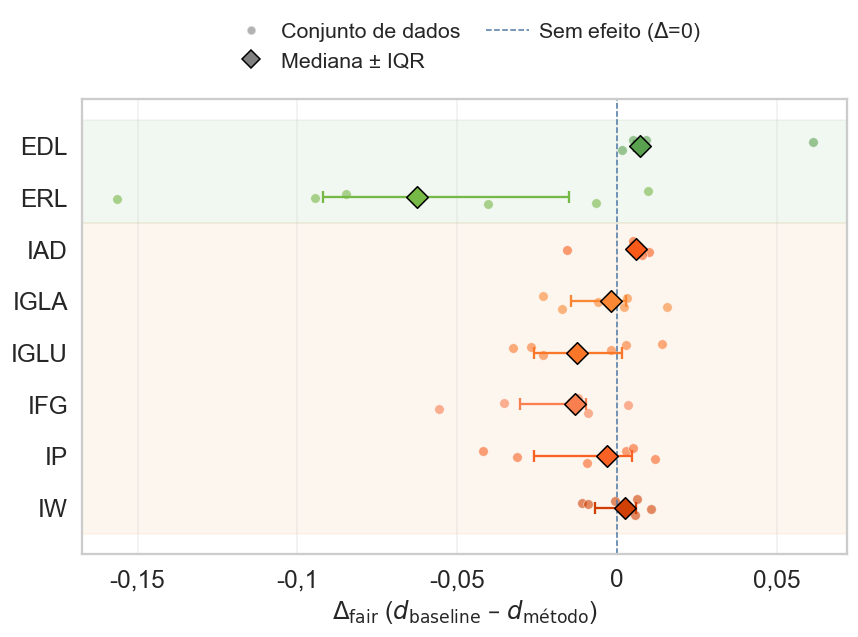

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_method_consistency.tex
| method   | category       |   n |      median |        iqr |         min |        max |
|:---------|:---------------|----:|------------:|-----------:|------------:|-----------:|
| EDL      | pre_processing |   6 |  0.00732819 | 0.00335206 |  0.00149148 | 0.0612583  |
| ERL      | pre_processing |   6 | -0.0626472  | 0.0769335  | -0.156381   | 0.00985256 |
| IAD      | in_processing  |   6 |  0.00595439 | 0.00255202 | -0.0157083  | 0.010101   |
| IFG      | in_processing  |   6 | -0.0131994  | 0.0204495  | -0.0555556  | 0.00342502 |
| IGLA     | in_processing  |   6 | -0.00185941 | 0.0172558  | -0.02317    | 0.0157083  |
| IGLU     | in_processing  |   6 | -0.012618   | 0.0274887  | -0.032659   | 0.0141655  |
| IP       | in_processing  |   6 | -0.00317666 | 0.0303765  | -0.042053   | 0.0120617  |
| IW       | in_processing  |   6 |  0.00250108 | 0.0129903  | -0.0109272  | 0.0108146  |


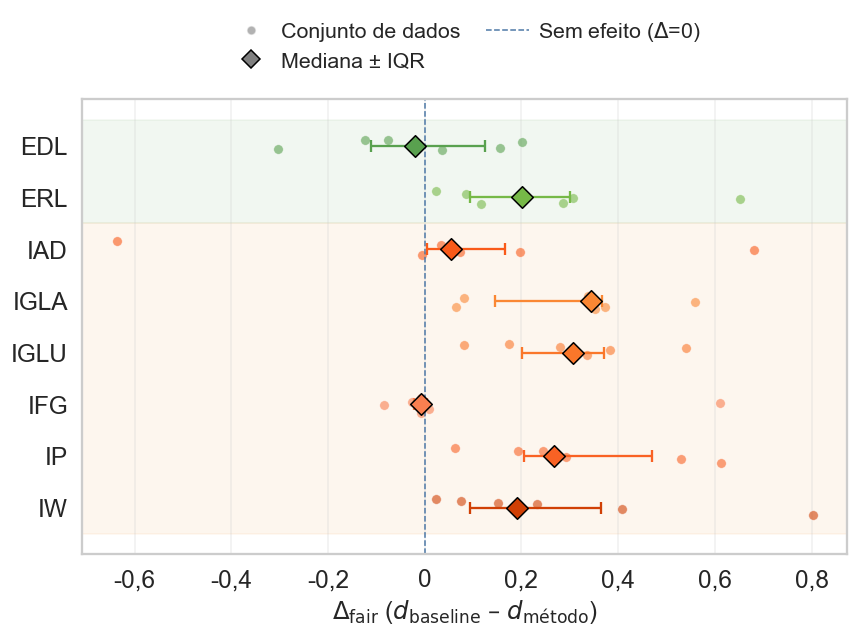

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_method_disparate_impact.tex
| method   | category       |   n |      median |       iqr |        min |      max |
|:---------|:---------------|----:|------------:|----------:|-----------:|---------:|
| EDL      | pre_processing |   6 | -0.0202733  | 0.236463  | -0.303984  | 0.201519 |
| ERL      | pre_processing |   6 |  0.200866   | 0.207657  |  0.0226741 | 0.652887 |
| IAD      | in_processing  |   6 |  0.05399    | 0.161895  | -0.635884  | 0.680621 |
| IFG      | in_processing  |   6 | -0.00702258 | 0.0267137 | -0.0845856 | 0.610932 |
| IGLA     | in_processing  |   6 |  0.344762   | 0.221919  |  0.0646493 | 0.559616 |
| IGLU     | in_processing  |   6 |  0.307288   | 0.170287  |  0.0810837 | 0.539459 |
| IP       | in_processing  |   6 |  0.267854   | 0.264741  |  0.0616623 | 0.612189 |
| IW       | in_processing  |   6 |  0.191771   | 0.270472  |  0.022382  | 0.80211  |


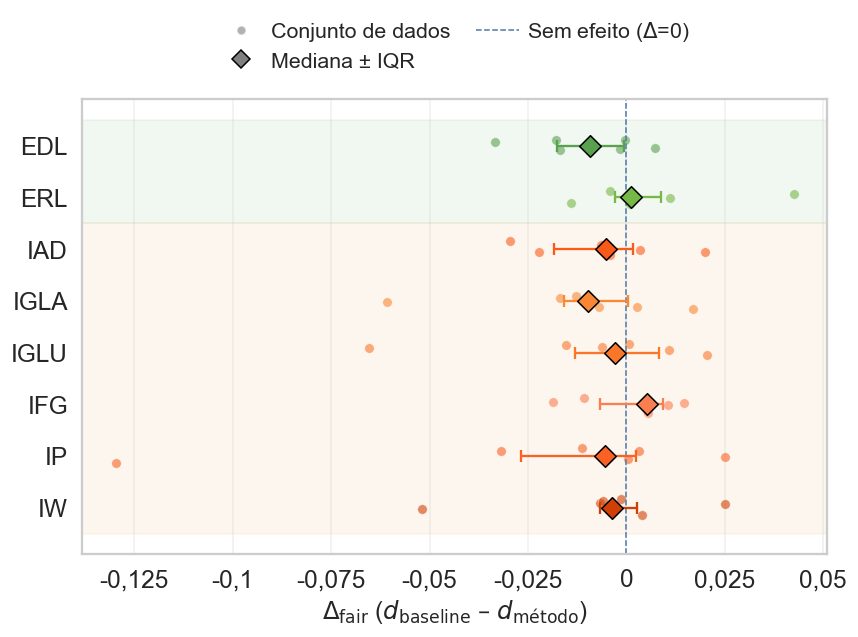

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_method_error_rate_difference.tex
| method   | category       |   n |      median |        iqr |        min |        max |
|:---------|:---------------|----:|------------:|-----------:|-----------:|-----------:|
| EDL      | pre_processing |   6 | -0.00929222 | 0.017074   | -0.0334395 | 0.00736416 |
| ERL      | pre_processing |   6 |  0.00128026 | 0.0116139  | -0.0141849 | 0.042444   |
| IAD      | in_processing  |   6 | -0.00525632 | 0.0198428  | -0.0295451 | 0.020056   |
| IFG      | in_processing  |   6 |  0.00533786 | 0.0160487  | -0.0185218 | 0.014567   |
| IGLA     | in_processing  |   6 | -0.00981855 | 0.0160849  | -0.0608443 | 0.0170243  |
| IGLU     | in_processing  |   6 | -0.0028293  | 0.0214041  | -0.0652887 | 0.0205224  |
| IP       | in_processing  |   6 | -0.00535301 | 0.029152   | -0.129551  | 0.0249534  |
| IW       | in_processing  |   6 | -0.0036895  | 0.00915593 | -0.0519353 | 0.0249534  |


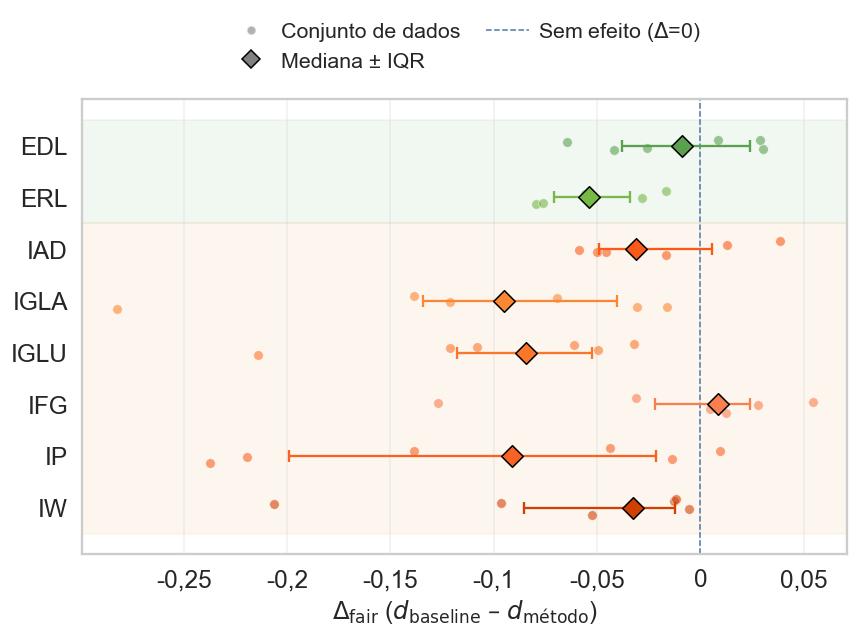

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_method_false_discovery_rate_difference.tex
| method   | category       |   n |      median |       iqr |        min |         max |
|:---------|:---------------|----:|------------:|----------:|-----------:|------------:|
| EDL      | pre_processing |   6 | -0.0087053  | 0.0616136 | -0.064694  |  0.0302783  |
| ERL      | pre_processing |   6 | -0.0539065  | 0.0366939 | -0.0794001 | -0.0166853  |
| IAD      | in_processing  |   6 | -0.0311792  | 0.0546522 | -0.0589935 |  0.0384122  |
| IFG      | in_processing  |   6 |  0.00851398 | 0.0459037 | -0.127028  |  0.0542677  |
| IGLA     | in_processing  |   6 | -0.0952057  | 0.0938413 | -0.282152  | -0.0159655  |
| IGLU     | in_processing  |   6 | -0.0844601  | 0.0654156 | -0.214227  | -0.0320904  |
| IP       | in_processing  |   6 | -0.091115   | 0.17777   | -0.237149  |  0.00933967 |
| IW       | in_processing  |   6 | -0.0328077  | 0.0732995 | -0.206103  | -0.00

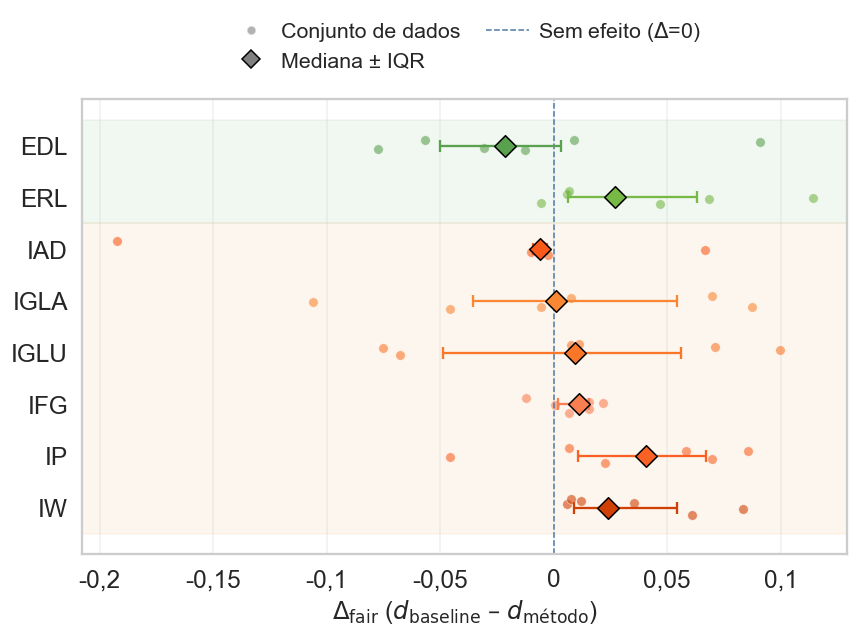

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_method_false_negative_rate_difference.tex
| method   | category       |   n |      median |        iqr |         min |       max |
|:---------|:---------------|----:|------------:|-----------:|------------:|----------:|
| EDL      | pre_processing |   6 | -0.0216468  | 0.0537167  | -0.077318   | 0.0908267 |
| ERL      | pre_processing |   6 |  0.0268197  | 0.0568421  | -0.00565607 | 0.114031  |
| IAD      | in_processing  |   6 | -0.00603389 | 0.00619063 | -0.192275   | 0.0667125 |
| IFG      | in_processing  |   6 |  0.0110482  | 0.0136027  | -0.0120178  | 0.021758  |
| IGLA     | in_processing  |   6 |  0.00099041 | 0.0899413  | -0.10591    | 0.0872929 |
| IGLU     | in_processing  |   6 |  0.00944487 | 0.104937   | -0.0750753  | 0.0995207 |
| IP       | in_processing  |   6 |  0.0404271  | 0.0563515  | -0.0456081  | 0.0857355 |
| IW       | in_processing  |   6 |  0.0236986  | 0.0456414  |  0.00580844 | 0.08

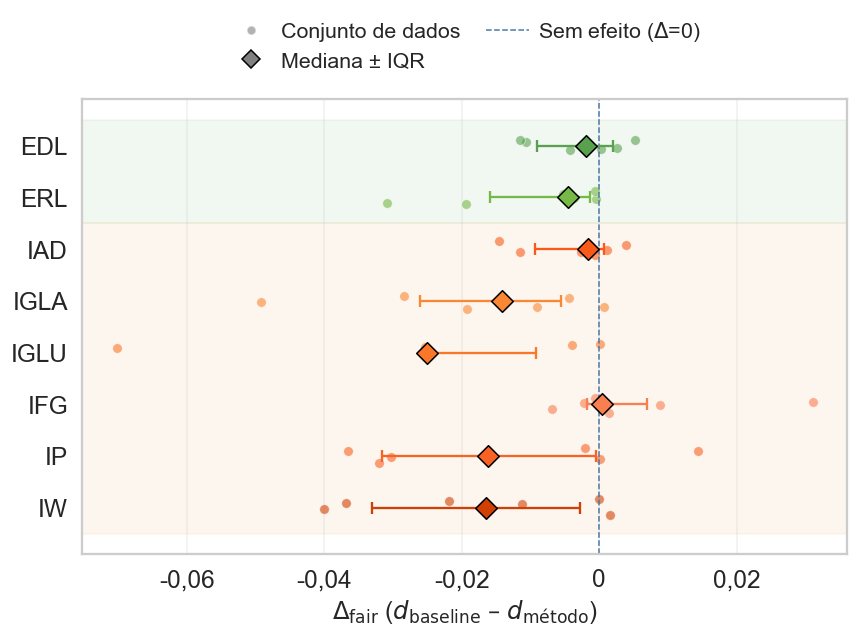

Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_delta_fair_method_generalized_entropy_index.tex
| method   | category       |   n |       median |       iqr |         min |          max |
|:---------|:---------------|----:|-------------:|----------:|------------:|-------------:|
| EDL      | pre_processing |   6 | -0.00198049  | 0.0111283 | -0.0115823  |  0.00519147  |
| ERL      | pre_processing |   6 | -0.00448798  | 0.014533  | -0.0308876  | -0.000533459 |
| IAD      | in_processing  |   6 | -0.00165614  | 0.0099823 | -0.0145715  |  0.00386268  |
| IFG      | in_processing  |   6 |  0.000366107 | 0.0087877 | -0.00693362 |  0.0310692   |
| IGLA     | in_processing  |   6 | -0.0141399   | 0.020644  | -0.0492333  |  0.000752765 |
| IGLU     | in_processing  |   6 | -0.0251314   | 0.0161484 | -0.0701756  |  0.000102032 |
| IP       | in_processing  |   6 | -0.0161669   | 0.031211  | -0.0365586  |  0.0144022   |
| IW       | in_processing  |   6 | -0.0165491   | 0.030271

In [200]:
# RQ1 — Δfairness por método individual — figuras + tabelas + win rate
for m in metrics_rq1:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="all",
    )
    if delta_method.empty:
        continue

    metric_label = translate.get(m, m)

    # Figura: scatter + box por método
    plot_delta_fairness_method(
        delta_method, metric=m, translate=translate,
        save_path=RQ1_FIGS / f"delta_fairness_by_method_{m}.pdf",
    )

    # Tabela: Δfairness por método
    save_delta_table(
        delta_method, group_cols=["method", "category"],
        caption=f"Δfairness por método — {metric_label} (\textit{{baseline}} como referência)",
        label=f"tab_rq1_delta_fair_method_{m}",
        result_dir=RQ1_TABLES,
    )

In [201]:
# Win rate por método: proporção de datasets com Δfair > 0
winrate_method_rows = []

for m in metrics_rq1:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="all",
    )
    if delta_method.empty:
        continue
    wr = compute_win_rate(delta_method, group_col="method")
    wr["metric"] = m
    winrate_method_rows.append(wr)

if winrate_method_rows:
    winrate_method_df = pd.concat(winrate_method_rows, ignore_index=True)
    winrate_method_df["metric_label"] = winrate_method_df["metric"].map(
        lambda x: translate.get(x, x)
    )
    winrate_method_df["win_rate_pct"] = (winrate_method_df["win_rate"] * 100).round(1)

    display(
        winrate_method_df[["metric_label", "method", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica",
            "method": "Método",
            "n": "N datasets",
            "wins": "Vitórias (Δ>0)",
            "win_rate_pct": "Win rate (%)",
        })
    )

    latex_and_save(
        winrate_method_df[["metric_label", "method", "n", "wins", "win_rate_pct"]],
        caption="Win rate por método — proporção de datasets com melhora em fairness",
        label="tab_rq1_winrate_method",
        result_dir=RQ1_TABLES,
    )

,Métrica,Método,N datasets,Vitórias (Δ>0),Win rate (%)
0,Amplificação de viés,EDL,6,2,33.3
1,Amplificação de viés,ERL,6,5,83.3
2,Amplificação de viés,IAD,6,4,66.7
3,Amplificação de viés,IFG,6,3,50.0
4,Amplificação de viés,IGLA,6,5,83.3
5,Amplificação de viés,IGLU,6,5,83.3
6,Amplificação de viés,IP,6,3,50.0
7,Amplificação de viés,IW,6,5,83.3
8,Consistência,EDL,6,6,100.0
9,Consistência,ERL,6,1,16.7


Tabela salva em: experiments\results\analysis\RQ1\tables\tab_rq1_winrate_method.tex
| metric_label                          | method   |   n |   wins |   win_rate_pct |
|:--------------------------------------|:---------|----:|-------:|---------------:|
| Amplificação de viés                  | EDL      |   6 |      2 |           33.3 |
| Amplificação de viés                  | ERL      |   6 |      5 |           83.3 |
| Amplificação de viés                  | IAD      |   6 |      4 |           66.7 |
| Amplificação de viés                  | IFG      |   6 |      3 |           50   |
| Amplificação de viés                  | IGLA     |   6 |      5 |           83.3 |
| Amplificação de viés                  | IGLU     |   6 |      5 |           83.3 |
| Amplificação de viés                  | IP       |   6 |      3 |           50   |
| Amplificação de viés                  | IW       |   6 |      5 |           83.3 |
| Consistência                          | EDL      |   6 |      6 

In [202]:
# Teste estatístico: Friedman + Holm por MÉTODO (todas as métricas)
stats_exp = run_all_experiment_analysis(
    df,
    ideal_values=ideal_values,
    scopes=["all"],
    save_dir=RQ1_TABLES,
    translate=translate,
    cols_omnibus=cols_exp_omnibus,
    cols_posthoc=cols_exp_posthoc,
)

# Tabela consolidada por método (todas as métricas juntas)
save_results_latex(
    stats_exp, metric='', analysis_type='experiment',
    save_dir=RQ1_TABLES, translate=translate,
    cols_omnibus=cols_exp_omnibus, cols_posthoc=cols_exp_posthoc,
    scope_suffix='method'
)

stats_exp_omnibus = stats_exp.loc[stats_exp["test"].isin(["friedman", "wilcoxon"])].copy()
stats_exp_posthoc = stats_exp.loc[stats_exp["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por método ===")
display(stats_exp_omnibus[cols_exp_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico ===")
display(stats_exp_posthoc[cols_exp_posthoc])


  error_rate_difference - Análise por Método

📊 Teste Friedman (omnibus)
   N datasets: 6, k métodos: 9
   Estatística = 7.4659, p = 0.4873
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Método               Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.0317       0.0000         0.0000       -0.0067      0.0323     6
   EDL                  0.0396       -0.0093        0.0171       -0.0242      0.0399     6
   ERL                  0.0334       0.0013         0.0116       0.0077       0.0241     6
   IAD                  0.0460       -0.0053        0.0198       -0.0238      0.0349     6
   IGLA                 0.0492       -0.0098        0.0161       0.0355       0.0361     6
   IGLU                 0.0371       -0.0028        0.0214       0.0214     

d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:658: UserWarning: Métodos removidos (sem dados): {'baseline_typical'}. Continuando com 1 métodos.
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:668: UserWarning: Teste requer pelo menos 2 métodos com dados. Encontrados: 1. Retornando resultados vazios.
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:658: UserWarning: Métodos removidos (sem dados): {'baseline_typical'}. Continuando com 1 métodos.
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:668: UserWarning: Teste requer pelo menos 2 métodos com dados. Encontrados: 1. Retornando resultados vazios.
  warnings.warn(


,metric,method,category,p_value,median_delta_fair,iqr_delta_fair
0,error_rate_difference,baseline_typical,baseline,0.487295,0.000000,0.000000
1,error_rate_difference,EDL,pre_processing,0.487295,-0.009292,0.017074
2,error_rate_difference,ERL,pre_processing,0.487295,0.001280,0.011614
3,error_rate_difference,IAD,in_processing,0.487295,-0.005256,0.019843
4,error_rate_difference,IGLA,in_processing,0.487295,-0.009819,0.016085
...,...,...,...,...,...,...
106,false_negative_rate_difference,IGLA,in_processing,0.307003,0.000990,0.089941
107,false_negative_rate_difference,IGLU,in_processing,0.307003,0.009445,0.104937
108,false_negative_rate_difference,IFG,in_processing,0.307003,0.011048,0.013603
109,false_negative_rate_difference,IP,in_processing,0.307003,0.040427,0.056351



=== Pós-hoc (Holm) vs baseline típico ===


,metric,method,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
9,error_rate_difference,EDL,pre_processing,6.166667,1.000000,-0.009292,0.017074
10,error_rate_difference,ERL,pre_processing,3.166667,1.000000,0.001280,0.011614
11,error_rate_difference,IAD,in_processing,5.166667,1.000000,-0.005256,0.019843
12,error_rate_difference,IGLA,in_processing,6.333333,1.000000,-0.009819,0.016085
13,error_rate_difference,IGLU,in_processing,5.166667,1.000000,-0.002829,0.021404
14,error_rate_difference,IFG,in_processing,4.000000,1.000000,0.005338,0.016049
15,error_rate_difference,IP,in_processing,6.083333,1.000000,-0.005353,0.029152
16,error_rate_difference,IW,in_processing,4.416667,1.000000,-0.003689,0.009156
26,bias_amplification,EDL,pre_processing,6.666667,0.598613,-0.048435,0.145176
27,bias_amplification,ERL,pre_processing,3.416667,0.082016,0.060458,0.062214


## 3) RQ2 — Há estratégia melhor por padrão de viés (A/B/C)?

**Objetivo:** Repetir a análise de RQ1 (Δfairness, win rate, testes estatísticos), porém **estratificada** por padrão de viés.

- **Padrão A** (paridade estatística): métricas `disparate_impact`, `bias_amplification`
- **Padrão B** (dispersão individual): métricas `consistency`, `generalized_entropy_index`
- **Padrão C** (diferenças em confusão): métricas `false_negative_rate_difference`, `false_discovery_rate_difference`, `error_rate_difference`

Cada subseção filtra apenas os datasets elegíveis ao padrão correspondente (scope A/B/C).

### 3.1 Padrão A — Paridade estatística

Métricas: Disparate Impact, DFBA.  
Scope: apenas datasets classificados com padrão A (prefixo A no pattern_code).

#### 3.1.1 Δfairness por categoria de mitigação — Padrão A

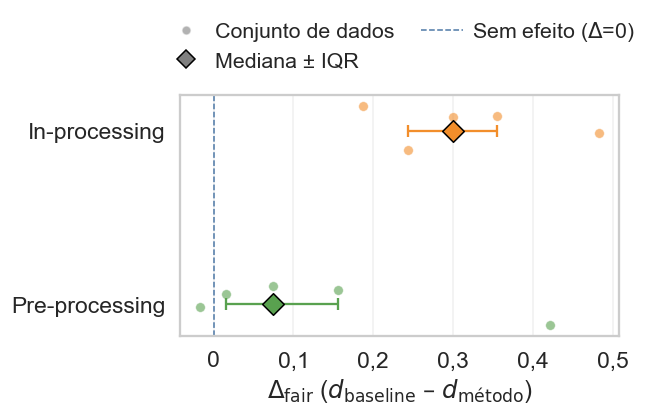

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_category_A_disparate_impact.tex
| category       |   n |    median |      iqr |       min |     max |
|:---------------|----:|----------:|---------:|----------:|--------:|
| in_processing  |   5 | 0.300331  | 0.111131 |  0.186542 | 0.48285 |
| pre_processing |   5 | 0.0741256 | 0.140058 | -0.017332 | 0.42169 |


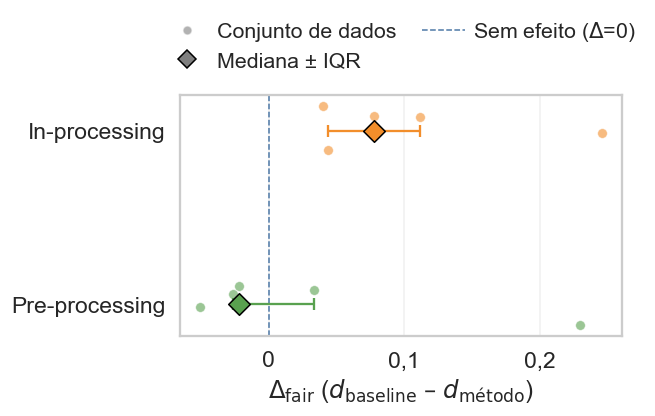

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_category_A_bias_amplification.tex
| category       |   n |     median |       iqr |        min |      max |
|:---------------|----:|-----------:|----------:|-----------:|---------:|
| in_processing  |   5 |  0.0774704 | 0.0678555 |  0.0396918 | 0.245728 |
| pre_processing |   5 | -0.022058  | 0.0600595 | -0.0508137 | 0.229526 |


In [203]:
# RQ2 — Padrão A: Δfairness por CATEGORIA (pre vs in)
metrics_A = ["disparate_impact", "bias_amplification"]

# === Controle de fontes — RQ2 ===
from auxiliar_analysis import rq1_utils

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 15,
    "legend_fontsize": 14,
})


for m in metrics_A:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="A",
    )
    if delta_cat.empty:
        continue

    metric_label = translate.get(m, m)

    plot_delta_fairness_category(
        delta_cat, metric=m, translate=translate, figsize = (6, 4),
        save_path=RQ2_FIGS / f"delta_fairness_by_category_A_{m}.pdf",
    )

    save_delta_table(
        delta_cat, group_cols=["category"],
        caption=f"Δfairness por categoria — {metric_label} (Padrão A). Cada ponto corresponde a um conjunto de dados (mediana dos métodos da categoria, agregada sobre \textit{{folds}} e repetições)",
        label=f"tab_rq2_delta_fair_category_A_{m}",
        result_dir=RQ2_TABLES,
    )

In [204]:
# Win rate por categoria — Padrão A
winrate_A_cat_rows = []

for m in metrics_A:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="A",
    )
    if delta_cat.empty:
        continue
    wr = compute_win_rate(delta_cat, group_col="category")
    wr["metric"] = m
    winrate_A_cat_rows.append(wr)

if winrate_A_cat_rows:
    winrate_A_cat = pd.concat(winrate_A_cat_rows, ignore_index=True)
    winrate_A_cat["metric_label"] = winrate_A_cat["metric"].map(lambda x: translate.get(x, x))
    winrate_A_cat["win_rate_pct"] = (winrate_A_cat["win_rate"] * 100).round(1)
    display(
        winrate_A_cat[["metric_label", "category", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica", "category": "Categoria",
            "n": "N datasets", "wins": "Vitórias (Δ>0)", "win_rate_pct": "Win rate (%)",
        })
    )
    latex_and_save(
        winrate_A_cat[["metric_label", "category", "n", "wins", "win_rate_pct"]],
        caption="Win rate por categoria — Padrão A",
        label="tab_rq2_winrate_category_A",
        result_dir=RQ2_TABLES,
    )

,Métrica,Categoria,N datasets,Vitórias (Δ>0),Win rate (%)
0,Impacto Díspar,in_processing,5,5,100.0
1,Impacto Díspar,pre_processing,5,4,80.0
2,Amplificação de viés,in_processing,5,5,100.0
3,Amplificação de viés,pre_processing,5,2,40.0


Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_winrate_category_A.tex
| metric_label         | category       |   n |   wins |   win_rate_pct |
|:---------------------|:---------------|----:|-------:|---------------:|
| Impacto Díspar       | in_processing  |   5 |      5 |            100 |
| Impacto Díspar       | pre_processing |   5 |      4 |             80 |
| Amplificação de viés | in_processing  |   5 |      5 |            100 |
| Amplificação de viés | pre_processing |   5 |      2 |             40 |


In [205]:
# Teste estatístico: Friedman + Holm por CATEGORIA — Padrão A
stats_cat_A = run_all_category_analysis(df, ideal_values=ideal_values, scopes=["A"], metrics=metrics_A)

save_results_latex(
    stats_cat_A, metric='', analysis_type='category',
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_omnibus, cols_posthoc=cols_posthoc,
    scope_suffix="A"
)

stats_cat_A_omnibus = stats_cat_A.loc[stats_cat_A["test"] == "friedman"].copy()
stats_cat_A_posthoc = stats_cat_A.loc[stats_cat_A["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por categoria — Padrão A ===")
display(stats_cat_A_omnibus[cols_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico — Padrão A ===")
display(stats_cat_A_posthoc[cols_posthoc])


  disparate_impact - Análise por Categoria

📊 Teste Friedman (omnibus)
   N datasets: 5, k métodos: 3
   Estatística = 8.4000, p = 0.0150 *
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Categoria            Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.5454       0.0000         0.0000       1.5454       1.3912     5
   pre_processing       0.5628       0.0741         0.1401       1.5628       0.8360     5
   in_processing        0.2907       0.3003         0.1111       1.2079       0.7258     5

📊 Pós-hoc vs baseline_typical (Holm)
   (* p<0.05, ** p<0.01, *** p<0.001)
| category       |   avg_rank |   delta_rank |      z | p_raw     | p_holm    | reject_holm   |   median_delta_fair |   iqr_delta_fair |   median_d |
|:---------------|-----------:|-

,metric,category,p_value,median_delta_fair,iqr_delta_fair
0,disparate_impact,baseline_typical,0.014996,0.000000,0.000000
1,disparate_impact,pre_processing,0.014996,0.074126,0.140058
2,disparate_impact,in_processing,0.014996,0.300331,0.111131
5,bias_amplification,baseline_typical,0.022371,0.000000,0.000000
6,bias_amplification,pre_processing,0.022371,-0.022058,0.060059
7,bias_amplification,in_processing,0.022371,0.077470,0.067855



=== Pós-hoc (Holm) vs baseline típico — Padrão A ===


,metric,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
3,disparate_impact,pre_processing,2.2,0.171391,0.074126,0.140058
4,disparate_impact,in_processing,1.0,0.004427,0.300331,0.111131
8,bias_amplification,pre_processing,2.6,0.624085,-0.022058,0.060059
9,bias_amplification,in_processing,1.0,0.026857,0.077470,0.067855


#### 3.1.2 Δfairness por método individual — Padrão A

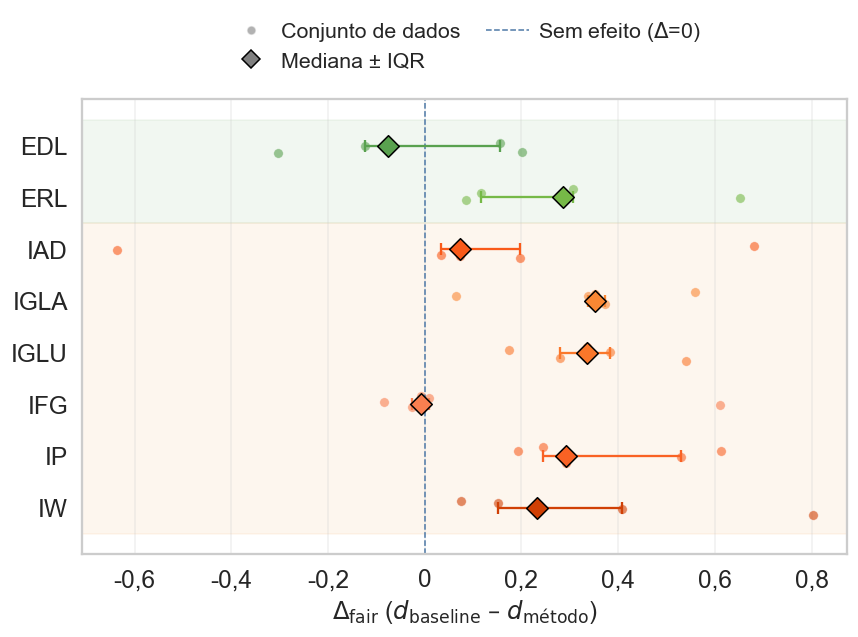

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_method_A_disparate_impact.tex
| method   | category       |   n |      median |      iqr |        min |      max |
|:---------|:---------------|----:|------------:|---------:|-----------:|---------:|
| EDL      | pre_processing |   5 | -0.0768794  | 0.277547 | -0.303984  | 0.201519 |
| ERL      | pre_processing |   5 |  0.28506    | 0.190091 |  0.0860177 | 0.652887 |
| IAD      | in_processing  |   5 |  0.073313   | 0.162246 | -0.635884  | 0.680621 |
| IFG      | in_processing  |   5 | -0.00717741 | 0.035515 | -0.0845856 | 0.610932 |
| IGLA     | in_processing  |   5 |  0.352626   | 0.034835 |  0.0646493 | 0.559616 |
| IGLU     | in_processing  |   5 |  0.335274   | 0.103964 |  0.174874  | 0.539459 |
| IP       | in_processing  |   5 |  0.291205   | 0.285555 |  0.192637  | 0.612189 |
| IW       | in_processing  |   5 |  0.232639   | 0.257509 |  0.0750281 | 0.80211  |


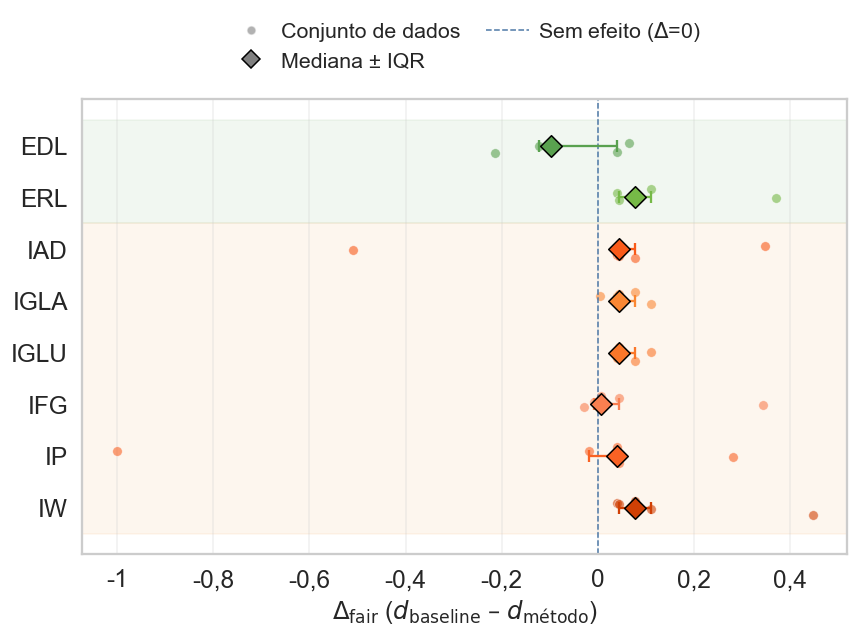

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_method_A_bias_amplification.tex
| method   | category       |   n |      median |       iqr |         min |       max |
|:---------|:---------------|----:|------------:|----------:|------------:|----------:|
| EDL      | pre_processing |   5 | -0.0968693  | 0.161278  | -0.212929   | 0.0638766 |
| ERL      | pre_processing |   5 |  0.0774704  | 0.0678555 |  0.0396918  | 0.370735  |
| IAD      | in_processing  |   5 |  0.0434465  | 0.0377787 | -0.509065   | 0.347873  |
| IFG      | in_processing  |   5 |  0.00738048 | 0.0523378 | -0.0288706  | 0.343151  |
| IGLA     | in_processing  |   5 |  0.0434465  | 0.0377787 |  0.00399833 | 0.111302  |
| IGLU     | in_processing  |   5 |  0.0434465  | 0.0377787 |  0.0388535  | 0.111302  |
| IP       | in_processing  |   5 |  0.0396918  | 0.0613236 | -0.999721   | 0.282095  |
| IW       | in_processing  |   5 |  0.0774704  | 0.0678555 |  0.0396918  | 0.44676   |


In [206]:
# RQ2 — Padrão A: Δfairness por MÉTODO individual

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 16,
    "legend_fontsize": 14,
})



for m in metrics_A:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="A",
    )
    if delta_method.empty:
        continue

    metric_label = translate.get(m, m)

    plot_delta_fairness_method(
        delta_method, metric=m, translate=translate,
        save_path=RQ2_FIGS / f"delta_fairness_by_method_A_{m}.pdf",
    )

    save_delta_table(
        delta_method, group_cols=["method", "category"],
        caption=f"Δfairness por método — {metric_label} (Padrão A)",
        label=f"tab_rq2_delta_fair_method_A_{m}",
        result_dir=RQ2_TABLES,
    )

In [207]:
# Win rate por método — Padrão A
winrate_A_method_rows = []

for m in metrics_A:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="A",
    )
    if delta_method.empty:
        continue
    wr = compute_win_rate(delta_method, group_col="method")
    wr["metric"] = m
    winrate_A_method_rows.append(wr)

if winrate_A_method_rows:
    winrate_A_method = pd.concat(winrate_A_method_rows, ignore_index=True)
    winrate_A_method["metric_label"] = winrate_A_method["metric"].map(lambda x: translate.get(x, x))
    winrate_A_method["win_rate_pct"] = (winrate_A_method["win_rate"] * 100).round(1)
    display(
        winrate_A_method[["metric_label", "method", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica", "method": "Método",
            "n": "N datasets", "wins": "Vitórias (Δ>0)", "win_rate_pct": "Win rate (%)",
        })
    )
    latex_and_save(
        winrate_A_method[["metric_label", "method", "n", "wins", "win_rate_pct"]],
        caption="Win rate por método — Padrão A",
        label="tab_rq2_winrate_method_A",
        result_dir=RQ2_TABLES,
    )

,Métrica,Método,N datasets,Vitórias (Δ>0),Win rate (%)
0,Impacto Díspar,EDL,5,2,40.0
1,Impacto Díspar,ERL,5,5,100.0
2,Impacto Díspar,IAD,5,4,80.0
3,Impacto Díspar,IFG,5,2,40.0
4,Impacto Díspar,IGLA,5,5,100.0
5,Impacto Díspar,IGLU,5,5,100.0
6,Impacto Díspar,IP,5,5,100.0
7,Impacto Díspar,IW,5,5,100.0
8,Amplificação de viés,EDL,5,2,40.0
9,Amplificação de viés,ERL,5,5,100.0


Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_winrate_method_A.tex
| metric_label         | method   |   n |   wins |   win_rate_pct |
|:---------------------|:---------|----:|-------:|---------------:|
| Impacto Díspar       | EDL      |   5 |      2 |             40 |
| Impacto Díspar       | ERL      |   5 |      5 |            100 |
| Impacto Díspar       | IAD      |   5 |      4 |             80 |
| Impacto Díspar       | IFG      |   5 |      2 |             40 |
| Impacto Díspar       | IGLA     |   5 |      5 |            100 |
| Impacto Díspar       | IGLU     |   5 |      5 |            100 |
| Impacto Díspar       | IP       |   5 |      5 |            100 |
| Impacto Díspar       | IW       |   5 |      5 |            100 |
| Amplificação de viés | EDL      |   5 |      2 |             40 |
| Amplificação de viés | ERL      |   5 |      5 |            100 |
| Amplificação de viés | IAD      |   5 |      4 |             80 |
| Amplificação de viés | IFG  

In [208]:
# Teste estatístico: Friedman + Holm por MÉTODO — Padrão A
stats_exp_A = run_all_experiment_analysis(
    df, ideal_values=ideal_values, scopes=["A"], metrics=metrics_A,
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_exp_omnibus, cols_posthoc=cols_exp_posthoc,
)

# Tabela consolidada por método — Padrão A
save_results_latex(
    stats_exp_A, metric='', analysis_type='experiment',
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_exp_omnibus, cols_posthoc=cols_exp_posthoc,
    scope_suffix='method_A'
)

stats_exp_A_omnibus = stats_exp_A.loc[stats_exp_A["test"].isin(["friedman", "wilcoxon"])].copy()
stats_exp_A_posthoc = stats_exp_A.loc[stats_exp_A["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por método — Padrão A ===")
display(stats_exp_A_omnibus[cols_exp_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico — Padrão A ===")
display(stats_exp_A_posthoc[cols_exp_posthoc])


  disparate_impact - Análise por Método

📊 Teste Friedman (omnibus)
   N datasets: 5, k métodos: 9
   Estatística = 20.4267, p = 0.0088 **
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Método               Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.5454       0.0000         0.0000       1.5454       1.3912     5
   EDL                  0.8494       -0.0769        0.2775       1.8494       1.0569     5
   ERL                  0.3574       0.2851         0.1901       1.2387       0.6438     5
   IAD                  0.4614       0.0733         0.1622       1.3297       1.1596     5
   IGLA                 0.1821       0.3526         0.0348       1.1278       0.4283     5
   IGLU                 0.1994       0.3353         0.1040       1.1622      

,metric,method,category,p_value,median_delta_fair,iqr_delta_fair
0,disparate_impact,baseline_typical,baseline,0.008837,0.000000,0.000000
1,disparate_impact,EDL,pre_processing,0.008837,-0.076879,0.277547
2,disparate_impact,ERL,pre_processing,0.008837,0.285060,0.190091
3,disparate_impact,IAD,in_processing,0.008837,0.073313,0.162246
4,disparate_impact,IGLA,in_processing,0.008837,0.352626,0.034835
5,disparate_impact,IGLU,in_processing,0.008837,0.335274,0.103964
6,disparate_impact,IFG,in_processing,0.008837,-0.007177,0.035515
7,disparate_impact,IP,in_processing,0.008837,0.291205,0.285555
8,disparate_impact,IW,in_processing,0.008837,0.232639,0.257509
17,bias_amplification,baseline_typical,baseline,0.021824,0.000000,0.000000



=== Pós-hoc (Holm) vs baseline típico — Padrão A ===


,metric,method,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
9,disparate_impact,EDL,pre_processing,7.4,0.729034,-0.076879,0.277547
10,disparate_impact,ERL,pre_processing,4.4,0.129343,0.285060,0.190091
11,disparate_impact,IAD,in_processing,5.8,0.448046,0.073313,0.162246
12,disparate_impact,IGLA,in_processing,3.0,0.031647,0.352626,0.034835
13,disparate_impact,IGLU,in_processing,3.0,0.031647,0.335274,0.103964
14,disparate_impact,IFG,in_processing,7.0,0.729034,-0.007177,0.035515
15,disparate_impact,IP,in_processing,3.4,0.045941,0.291205,0.285555
16,disparate_impact,IW,in_processing,3.4,0.045941,0.232639,0.257509
26,bias_amplification,EDL,pre_processing,7.0,0.533417,-0.096869,0.161278
27,bias_amplification,ERL,pre_processing,3.1,0.045649,0.077470,0.067855


### 3.2 Padrão B — Dispersão individual

Métricas: Consistency, Índice de Entropia Generalizada.  
Scope: apenas datasets classificados com padrão B (prefixo B no pattern_code).

#### 3.2.1 Δfairness por categoria de mitigação — Padrão B

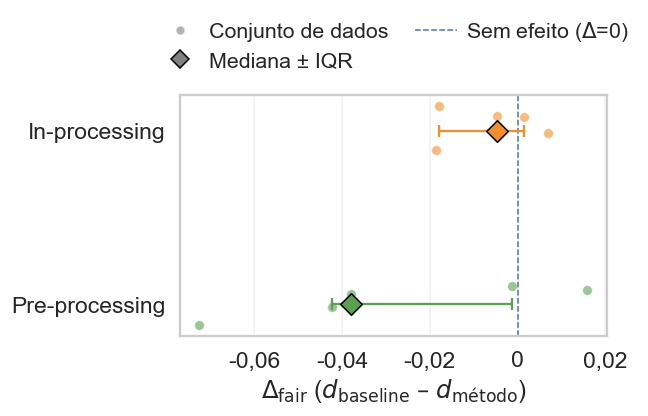

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_category_B_consistency.tex
| category       |   n |      median |       iqr |        min |        max |
|:---------------|----:|------------:|----------:|-----------:|-----------:|
| in_processing  |   5 | -0.00462428 | 0.0193636 | -0.0186869 | 0.00687237 |
| pre_processing |   5 | -0.0378788  | 0.0410878 | -0.0725105 | 0.015894   |


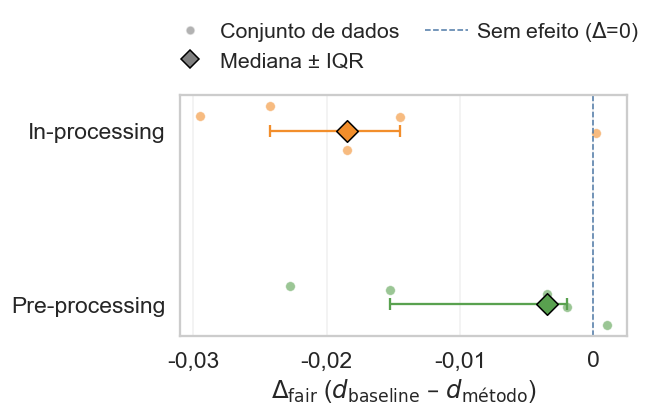

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_category_B_generalized_entropy_index.tex
| category       |   n |      median |        iqr |        min |         max |
|:---------------|----:|------------:|-----------:|-----------:|------------:|
| in_processing  |   5 | -0.0184449  | 0.00976564 | -0.0294947 | 0.000209127 |
| pre_processing |   5 | -0.00349188 | 0.0132718  | -0.0227686 | 0.00103355  |


In [209]:
# RQ2 — Padrão B: Δfairness por CATEGORIA (pre vs in)
metrics_B = ["consistency", "generalized_entropy_index"]

# === Controle de fontes — RQ2 ===
from auxiliar_analysis import rq1_utils

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 15,
    "legend_fontsize": 14,
})


for m in metrics_B:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="B",
    )
    if delta_cat.empty:
        continue

    metric_label = translate.get(m, m)

    plot_delta_fairness_category(
        delta_cat, metric=m, translate=translate, figsize = (6, 4),
        save_path=RQ2_FIGS / f"delta_fairness_by_category_B_{m}.pdf",
    )

    save_delta_table(
        delta_cat, group_cols=["category"],
        caption=f"Δfairness por categoria — {metric_label} (Padrão B). Cada ponto corresponde a um conjunto de dados (mediana dos métodos da categoria, agregada sobre \textit{{folds}} e repetições)",
        label=f"tab_rq2_delta_fair_category_B_{m}",
        result_dir=RQ2_TABLES,
    )

In [210]:
# Win rate por categoria — Padrão B
winrate_B_cat_rows = []

for m in metrics_B:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="B",
    )
    if delta_cat.empty:
        continue
    wr = compute_win_rate(delta_cat, group_col="category")
    wr["metric"] = m
    winrate_B_cat_rows.append(wr)

if winrate_B_cat_rows:
    winrate_B_cat = pd.concat(winrate_B_cat_rows, ignore_index=True)
    winrate_B_cat["metric_label"] = winrate_B_cat["metric"].map(lambda x: translate.get(x, x))
    winrate_B_cat["win_rate_pct"] = (winrate_B_cat["win_rate"] * 100).round(1)
    display(
        winrate_B_cat[["metric_label", "category", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica", "category": "Categoria",
            "n": "N datasets", "wins": "Vitórias (Δ>0)", "win_rate_pct": "Win rate (%)",
        })
    )
    latex_and_save(
        winrate_B_cat[["metric_label", "category", "n", "wins", "win_rate_pct"]],
        caption="Win rate por categoria — Padrão B",
        label="tab_rq2_winrate_category_B",
        result_dir=RQ2_TABLES,
    )

,Métrica,Categoria,N datasets,Vitórias (Δ>0),Win rate (%)
0,Consistência,in_processing,5,2,40.0
1,Consistência,pre_processing,5,1,20.0
2,Índice de Entropia Generalizada,in_processing,5,1,20.0
3,Índice de Entropia Generalizada,pre_processing,5,1,20.0


Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_winrate_category_B.tex
| metric_label                    | category       |   n |   wins |   win_rate_pct |
|:--------------------------------|:---------------|----:|-------:|---------------:|
| Consistência                    | in_processing  |   5 |      2 |             40 |
| Consistência                    | pre_processing |   5 |      1 |             20 |
| Índice de Entropia Generalizada | in_processing  |   5 |      1 |             20 |
| Índice de Entropia Generalizada | pre_processing |   5 |      1 |             20 |


In [211]:
# Teste estatístico: Friedman + Holm por CATEGORIA — Padrão B
stats_cat_B = run_all_category_analysis(df, ideal_values=ideal_values, scopes=["B"], metrics=metrics_B)

save_results_latex(
    stats_cat_B, metric='', analysis_type='category',
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_omnibus, cols_posthoc=cols_posthoc,
    scope_suffix="B"
)

stats_cat_B_omnibus = stats_cat_B.loc[stats_cat_B["test"] == "friedman"].copy()
stats_cat_B_posthoc = stats_cat_B.loc[stats_cat_B["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por categoria — Padrão B ===")
display(stats_cat_B_omnibus[cols_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico — Padrão B ===")
display(stats_cat_B_posthoc[cols_posthoc])


  consistency - Análise por Categoria

📊 Teste Friedman (omnibus)
   N datasets: 5, k métodos: 3
   Estatística = 1.6000, p = 0.4493
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Categoria            Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.1162       0.0000         0.0000       0.8838       0.1566     5
   pre_processing       0.1722       -0.0379        0.0411       0.8278       0.1046     5
   in_processing        0.1348       -0.0046        0.0194       0.8652       0.1603     5

📊 Pós-hoc vs baseline_typical (Holm)
   (* p<0.05, ** p<0.01, *** p<0.001)
| category       |   avg_rank |   delta_rank |     z |   p_raw |   p_holm | reject_holm   |   median_delta_fair |   iqr_delta_fair |   median_d |
|:---------------|-----------:|------------

,metric,category,p_value,median_delta_fair,iqr_delta_fair
0,consistency,baseline_typical,0.449329,0.000000,0.000000
1,consistency,pre_processing,0.449329,-0.037879,0.041088
2,consistency,in_processing,0.449329,-0.004624,0.019364
5,generalized_entropy_index,baseline_typical,0.074274,0.000000,0.000000
6,generalized_entropy_index,pre_processing,0.074274,-0.003492,0.013272
7,generalized_entropy_index,in_processing,0.074274,-0.018445,0.009766



=== Pós-hoc (Holm) vs baseline típico — Padrão B ===


,metric,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
3,consistency,pre_processing,2.4,1.0,-0.037879,0.041088
4,consistency,in_processing,2.0,1.0,-0.004624,0.019364
8,generalized_entropy_index,pre_processing,1.8,1.0,-0.003492,0.013272
9,generalized_entropy_index,in_processing,2.8,1.0,-0.018445,0.009766


#### 3.2.2 Δfairness por método individual — Padrão B

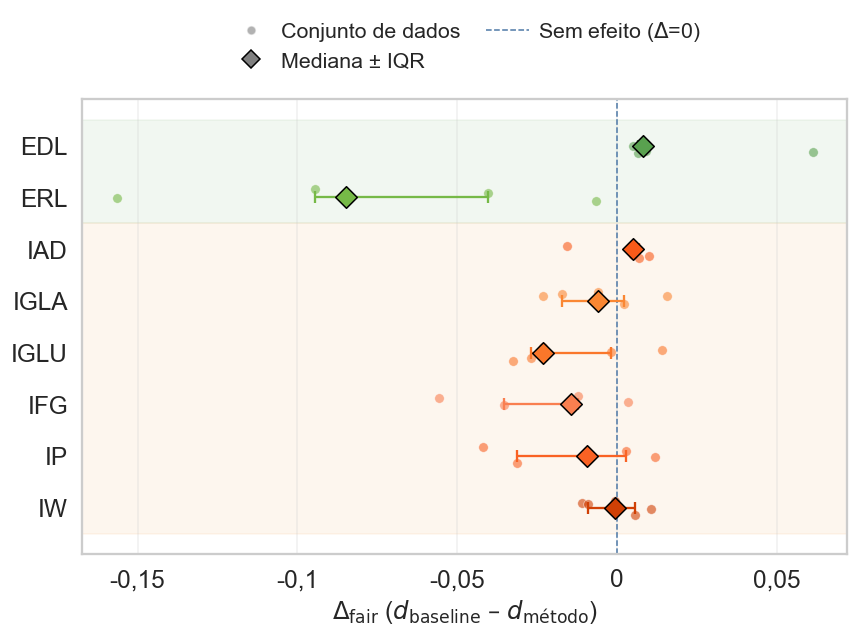

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_method_B_consistency.tex
| method   | category       |   n |       median |        iqr |         min |         max |
|:---------|:---------------|----:|-------------:|-----------:|------------:|------------:|
| EDL      | pre_processing |   5 |  0.00813464  | 0.00256917 |  0.00515913 |  0.0612583  |
| ERL      | pre_processing |   5 | -0.0848485   | 0.0539985  | -0.156381   | -0.00666733 |
| IAD      | in_processing  |   5 |  0.00501222  | 0.00192966 | -0.0157083  |  0.010101   |
| IFG      | in_processing  |   5 | -0.0142384   | 0.0233235  | -0.0555556  |  0.00342502 |
| IGLA     | in_processing  |   5 | -0.00606936  | 0.0195223  | -0.02317    |  0.0157083  |
| IGLU     | in_processing  |   5 | -0.0232323   | 0.0248263  | -0.032659   |  0.0141655  |
| IP       | in_processing  |   5 | -0.00925188  | 0.0342117  | -0.042053   |  0.0120617  |
| IW       | in_processing  |   5 | -0.000607933 | 0.014701   | -0.0109

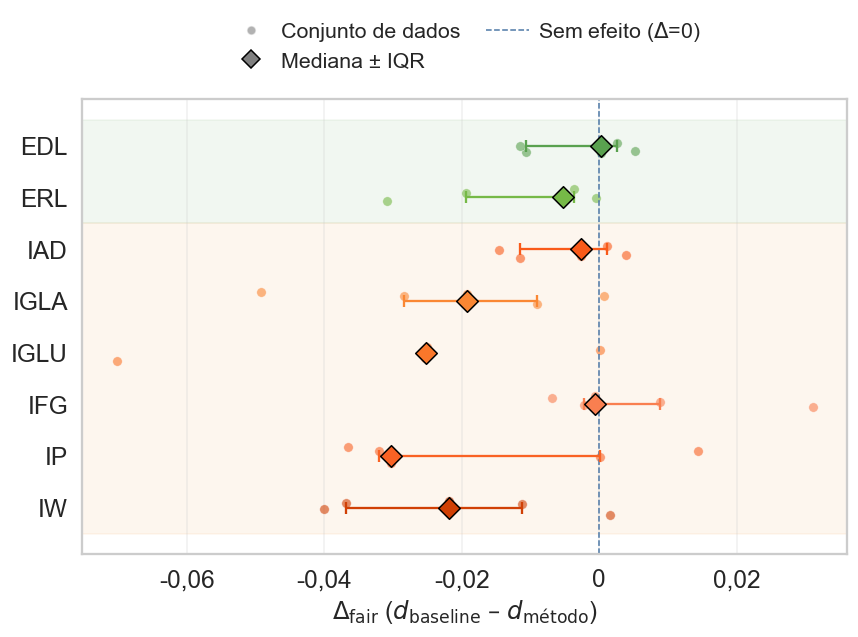

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_method_B_generalized_entropy_index.tex
| method   | category       |   n |       median |         iqr |         min |          max |
|:---------|:---------------|----:|-------------:|------------:|------------:|-------------:|
| EDL      | pre_processing |   5 |  0.00032233  | 0.0133025   | -0.0115823  |  0.00519147  |
| ERL      | pre_processing |   5 | -0.00532731  | 0.0158111   | -0.0308876  | -0.000533459 |
| IAD      | in_processing  |   5 | -0.00266789  | 0.0126352   | -0.0145715  |  0.00386268  |
| IFG      | in_processing  |   5 | -0.000681719 | 0.0110184   | -0.00693362 |  0.0310692   |
| IGLA     | in_processing  |   5 | -0.0192889   | 0.0194354   | -0.0492333  |  0.000752765 |
| IGLU     | in_processing  |   5 | -0.0252613   | 0.000415408 | -0.0701756  |  0.000102032 |
| IP       | in_processing  |   5 | -0.0302913   | 0.0321984   | -0.0365586  |  0.0144022   |
| IW       | in_processing  |   5 | -0.

In [212]:
# RQ2 — Padrão B: Δfairness por MÉTODO individual

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 16,
    "legend_fontsize": 14,
})



for m in metrics_B:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="B",
    )
    if delta_method.empty:
        continue

    metric_label = translate.get(m, m)

    plot_delta_fairness_method(
        delta_method, metric=m, translate=translate,
        save_path=RQ2_FIGS / f"delta_fairness_by_method_B_{m}.pdf",
    )

    save_delta_table(
        delta_method, group_cols=["method", "category"],
        caption=f"Δfairness por método — {metric_label} (Padrão B)",
        label=f"tab_rq2_delta_fair_method_B_{m}",
        result_dir=RQ2_TABLES,
    )

In [213]:
# Win rate por método — Padrão B
winrate_B_method_rows = []

for m in metrics_B:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="B",
    )
    if delta_method.empty:
        continue
    wr = compute_win_rate(delta_method, group_col="method")
    wr["metric"] = m
    winrate_B_method_rows.append(wr)

if winrate_B_method_rows:
    winrate_B_method = pd.concat(winrate_B_method_rows, ignore_index=True)
    winrate_B_method["metric_label"] = winrate_B_method["metric"].map(lambda x: translate.get(x, x))
    winrate_B_method["win_rate_pct"] = (winrate_B_method["win_rate"] * 100).round(1)
    display(
        winrate_B_method[["metric_label", "method", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica", "method": "Método",
            "n": "N datasets", "wins": "Vitórias (Δ>0)", "win_rate_pct": "Win rate (%)",
        })
    )
    latex_and_save(
        winrate_B_method[["metric_label", "method", "n", "wins", "win_rate_pct"]],
        caption="Win rate por método — Padrão B",
        label="tab_rq2_winrate_method_B",
        result_dir=RQ2_TABLES,
    )

,Métrica,Método,N datasets,Vitórias (Δ>0),Win rate (%)
0,Consistência,EDL,5,5,100.0
1,Consistência,ERL,5,0,0.0
2,Consistência,IAD,5,4,80.0
3,Consistência,IFG,5,1,20.0
4,Consistência,IGLA,5,2,40.0
5,Consistência,IGLU,5,1,20.0
6,Consistência,IP,5,2,40.0
7,Consistência,IW,5,2,40.0
8,Índice de Entropia Generalizada,EDL,5,3,60.0
9,Índice de Entropia Generalizada,ERL,5,0,0.0


Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_winrate_method_B.tex
| metric_label                    | method   |   n |   wins |   win_rate_pct |
|:--------------------------------|:---------|----:|-------:|---------------:|
| Consistência                    | EDL      |   5 |      5 |            100 |
| Consistência                    | ERL      |   5 |      0 |              0 |
| Consistência                    | IAD      |   5 |      4 |             80 |
| Consistência                    | IFG      |   5 |      1 |             20 |
| Consistência                    | IGLA     |   5 |      2 |             40 |
| Consistência                    | IGLU     |   5 |      1 |             20 |
| Consistência                    | IP       |   5 |      2 |             40 |
| Consistência                    | IW       |   5 |      2 |             40 |
| Índice de Entropia Generalizada | EDL      |   5 |      3 |             60 |
| Índice de Entropia Generalizada | ERL      

In [214]:
# Teste estatístico: Friedman + Holm por MÉTODO — Padrão B
stats_exp_B = run_all_experiment_analysis(
    df, ideal_values=ideal_values, scopes=["B"], metrics=metrics_B,
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_exp_omnibus, cols_posthoc=cols_exp_posthoc,
)

# Tabela consolidada por método — Padrão B
save_results_latex(
    stats_exp_B, metric='', analysis_type='experiment',
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_exp_omnibus, cols_posthoc=cols_exp_posthoc,
    scope_suffix='method_B'
)

stats_exp_B_omnibus = stats_exp_B.loc[stats_exp_B["test"].isin(["friedman", "wilcoxon"])].copy()
stats_exp_B_posthoc = stats_exp_B.loc[stats_exp_B["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por método — Padrão B ===")
display(stats_exp_B_omnibus[cols_exp_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico — Padrão B ===")
display(stats_exp_B_posthoc[cols_exp_posthoc])


  consistency - Análise por Método

📊 Teste Friedman (omnibus)
   N datasets: 5, k métodos: 9
   Estatística = 20.6933, p = 0.0080 **
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Método               Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.1162       0.0000         0.0000       0.8838       0.1566     5
   EDL                  0.1071       0.0081         0.0026       0.8929       0.1217     5
   ERL                  0.2561       -0.0848        0.0540       0.7439       0.1139     5
   IAD                  0.1154       0.0050         0.0019       0.8846       0.1452     5
   IGLA                 0.1333       -0.0061        0.0195       0.8667       0.1580     5
   IGLU                 0.1394       -0.0232        0.0248       0.8606       0.13

,metric,method,category,p_value,median_delta_fair,iqr_delta_fair
0,consistency,baseline_typical,baseline,0.008008,0.000000,0.000000
1,consistency,EDL,pre_processing,0.008008,0.008135,0.002569
2,consistency,ERL,pre_processing,0.008008,-0.084848,0.053999
3,consistency,IAD,in_processing,0.008008,0.005012,0.001930
4,consistency,IGLA,in_processing,0.008008,-0.006069,0.019522
5,consistency,IGLU,in_processing,0.008008,-0.023232,0.024826
6,consistency,IFG,in_processing,0.008008,-0.014238,0.023324
7,consistency,IP,in_processing,0.008008,-0.009252,0.034212
8,consistency,IW,in_processing,0.008008,-0.000608,0.014701
17,generalized_entropy_index,baseline_typical,baseline,0.055371,0.000000,0.000000



=== Pós-hoc (Holm) vs baseline típico — Padrão B ===


,metric,method,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
9,consistency,EDL,pre_processing,2.2,0.816095,0.008135,0.002569
10,consistency,ERL,pre_processing,8.4,1.000000,-0.084848,0.053999
11,consistency,IAD,in_processing,2.8,1.000000,0.005012,0.001930
12,consistency,IGLA,in_processing,4.6,1.000000,-0.006069,0.019522
13,consistency,IGLU,in_processing,6.2,1.000000,-0.023232,0.024826
14,consistency,IFG,in_processing,6.4,1.000000,-0.014238,0.023324
15,consistency,IP,in_processing,6.2,1.000000,-0.009252,0.034212
16,consistency,IW,in_processing,3.8,1.000000,-0.000608,0.014701
26,generalized_entropy_index,EDL,pre_processing,2.4,1.000000,0.000322,0.013302
27,generalized_entropy_index,ERL,pre_processing,5.6,1.000000,-0.005327,0.015811


### 3.3 Padrão C — Diferenças em matriz de confusão

Métricas: Diferença de Taxa de Falsos Negativos, Diferença de Taxa de Falsa Descoberta, Diferença de Taxa de Erro.  
Scope: apenas datasets classificados com padrão C (prefixo C no pattern_code).

#### 3.3.1 Δfairness por categoria de mitigação — Padrão C

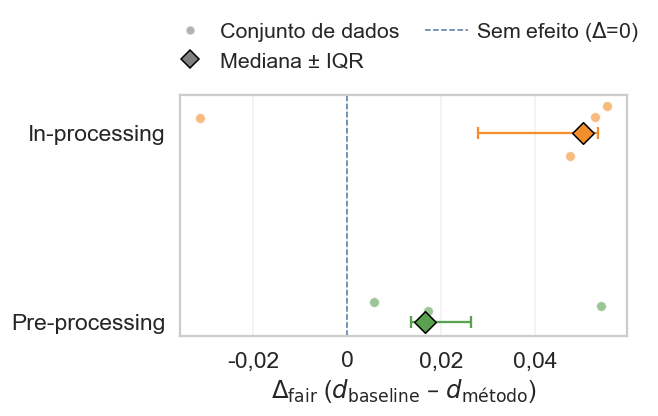

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_category_C_false_negative_rate_difference.tex
| category       |   n |    median |       iqr |         min |       max |
|:---------------|----:|----------:|----------:|------------:|----------:|
| in_processing  |   4 | 0.0501397 | 0.0257057 | -0.0312747  | 0.0553249 |
| pre_processing |   4 | 0.0166394 | 0.0127592 |  0.00575905 | 0.0539733 |


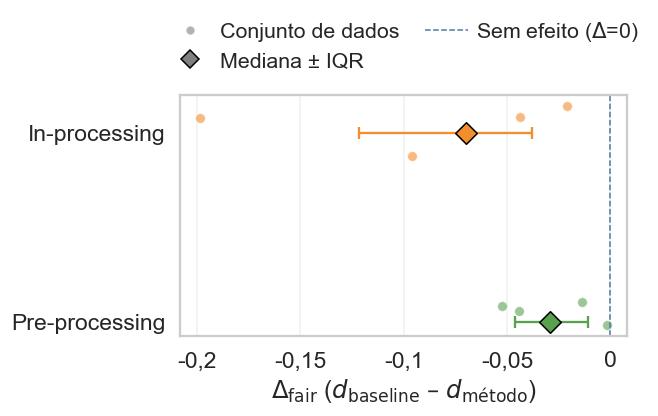

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_category_C_false_discovery_rate_difference.tex
| category       |   n |     median |       iqr |        min |         max |
|:---------------|----:|-----------:|----------:|-----------:|------------:|
| in_processing  |   4 | -0.069863  | 0.0838583 | -0.198519  | -0.0210201  |
| pre_processing |   4 | -0.0290026 | 0.0354969 | -0.0522914 | -0.00147036 |


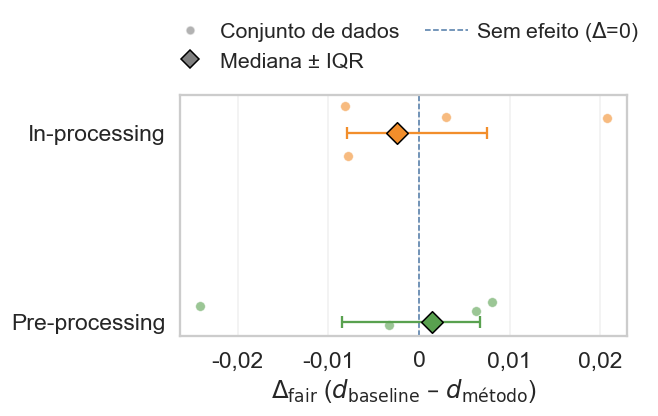

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_category_C_error_rate_difference.tex
| category       |   n |      median |       iqr |         min |        max |
|:---------------|----:|------------:|----------:|------------:|-----------:|
| in_processing  |   4 | -0.0024113  | 0.0154015 | -0.00818874 | 0.0207556  |
| pre_processing |   4 |  0.00146537 | 0.015257  | -0.0241431  | 0.00804571 |


In [215]:
# RQ2 — Padrão C: Δfairness por CATEGORIA (pre vs in)
metrics_C = ["false_negative_rate_difference", "false_discovery_rate_difference", "error_rate_difference"]

# === Controle de fontes — RQ2 ===
from auxiliar_analysis import rq1_utils

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 15,
    "legend_fontsize": 14,
})


for m in metrics_C:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="C",
    )
    if delta_cat.empty:
        continue

    metric_label = translate.get(m, m)

    plot_delta_fairness_category(
        delta_cat, metric=m, translate=translate, figsize = (6, 4),
        save_path=RQ2_FIGS / f"delta_fairness_by_category_C_{m}.pdf",
    )

    save_delta_table(
        delta_cat, group_cols=["category"],
        caption=f"Δfairness por categoria — {metric_label} (Padrão C). Cada ponto corresponde a um conjunto de dados (mediana dos métodos da categoria, agregada sobre \textit{{folds}} e repetições)",
        label=f"tab_rq2_delta_fair_category_C_{m}",
        result_dir=RQ2_TABLES,
    )

In [216]:
# Win rate por categoria — Padrão C
winrate_C_cat_rows = []

for m in metrics_C:
    delta_cat = compute_delta_fairness_category(
        df, metric=m, ideal_values=ideal_values, scope="C",
    )
    if delta_cat.empty:
        continue
    wr = compute_win_rate(delta_cat, group_col="category")
    wr["metric"] = m
    winrate_C_cat_rows.append(wr)

if winrate_C_cat_rows:
    winrate_C_cat = pd.concat(winrate_C_cat_rows, ignore_index=True)
    winrate_C_cat["metric_label"] = winrate_C_cat["metric"].map(lambda x: translate.get(x, x))
    winrate_C_cat["win_rate_pct"] = (winrate_C_cat["win_rate"] * 100).round(1)
    display(
        winrate_C_cat[["metric_label", "category", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica", "category": "Categoria",
            "n": "N datasets", "wins": "Vitórias (Δ>0)", "win_rate_pct": "Win rate (%)",
        })
    )
    latex_and_save(
        winrate_C_cat[["metric_label", "category", "n", "wins", "win_rate_pct"]],
        caption="Win rate por categoria — Padrão C",
        label="tab_rq2_winrate_category_C",
        result_dir=RQ2_TABLES,
    )

,Métrica,Categoria,N datasets,Vitórias (Δ>0),Win rate (%)
0,Diferença de Taxa de Falsos Negativos,in_processing,4,3,75.0
1,Diferença de Taxa de Falsos Negativos,pre_processing,4,4,100.0
2,Diferença de Taxa de Falsa Descoberta,in_processing,4,0,0.0
3,Diferença de Taxa de Falsa Descoberta,pre_processing,4,0,0.0
4,Diferença de Taxa de Erro,in_processing,4,2,50.0
5,Diferença de Taxa de Erro,pre_processing,4,2,50.0


Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_winrate_category_C.tex
| metric_label                          | category       |   n |   wins |   win_rate_pct |
|:--------------------------------------|:---------------|----:|-------:|---------------:|
| Diferença de Taxa de Falsos Negativos | in_processing  |   4 |      3 |             75 |
| Diferença de Taxa de Falsos Negativos | pre_processing |   4 |      4 |            100 |
| Diferença de Taxa de Falsa Descoberta | in_processing  |   4 |      0 |              0 |
| Diferença de Taxa de Falsa Descoberta | pre_processing |   4 |      0 |              0 |
| Diferença de Taxa de Erro             | in_processing  |   4 |      2 |             50 |
| Diferença de Taxa de Erro             | pre_processing |   4 |      2 |             50 |


In [217]:
# Teste estatístico: Friedman + Holm por CATEGORIA — Padrão C
stats_cat_C = run_all_category_analysis(df, ideal_values=ideal_values, scopes=["C"], metrics=metrics_C)

save_results_latex(
    stats_cat_C, metric='', analysis_type='category',
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_omnibus, cols_posthoc=cols_posthoc,
    scope_suffix="C"
)

stats_cat_C_omnibus = stats_cat_C.loc[stats_cat_C["test"] == "friedman"].copy()
stats_cat_C_posthoc = stats_cat_C.loc[stats_cat_C["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por categoria — Padrão C ===")
display(stats_cat_C_omnibus[cols_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico — Padrão C ===")
display(stats_cat_C_posthoc[cols_posthoc])


  false_negative_rate_difference - Análise por Categoria

📊 Teste Friedman (omnibus)
   N datasets: 4, k métodos: 3
   Estatística = 3.5000, p = 0.1738
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Categoria            Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.1409       0.0000         0.0000       -0.0443      0.2208     4
   pre_processing       0.1098       0.0166         0.0128       -0.0529      0.1522     4
   in_processing        0.0983       0.0501         0.0257       -0.0287      0.0654     4

📊 Pós-hoc vs baseline_typical (Holm)
   (* p<0.05, ** p<0.01, *** p<0.001)
| category       |   avg_rank |   delta_rank |      z | p_raw    |   p_holm | reject_holm   |   median_delta_fair |   iqr_delta_fair |   median_d |
|:---------------|----

,metric,category,p_value,median_delta_fair,iqr_delta_fair
0,false_negative_rate_difference,baseline_typical,0.173774,0.000000,0.000000
1,false_negative_rate_difference,pre_processing,0.173774,0.016639,0.012759
2,false_negative_rate_difference,in_processing,0.173774,0.050140,0.025706
5,false_discovery_rate_difference,baseline_typical,0.038774,0.000000,0.000000
6,false_discovery_rate_difference,pre_processing,0.038774,-0.029003,0.035497
7,false_discovery_rate_difference,in_processing,0.038774,-0.069863,0.083858
10,error_rate_difference,baseline_typical,1.000000,0.000000,0.000000
11,error_rate_difference,pre_processing,1.000000,0.001465,0.015257
12,error_rate_difference,in_processing,1.000000,-0.002411,0.015402



=== Pós-hoc (Holm) vs baseline típico — Padrão C ===


,metric,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
3,false_negative_rate_difference,pre_processing,1.50,0.07710,0.016639,0.012759
4,false_negative_rate_difference,in_processing,1.75,0.07865,0.050140,0.025706
8,false_discovery_rate_difference,pre_processing,2.25,1.00000,-0.029003,0.035497
9,false_discovery_rate_difference,in_processing,2.75,1.00000,-0.069863,0.083858
13,error_rate_difference,pre_processing,2.00,1.00000,0.001465,0.015257
14,error_rate_difference,in_processing,2.00,1.00000,-0.002411,0.015402


#### 3.3.2 Δfairness por método individual — Padrão C

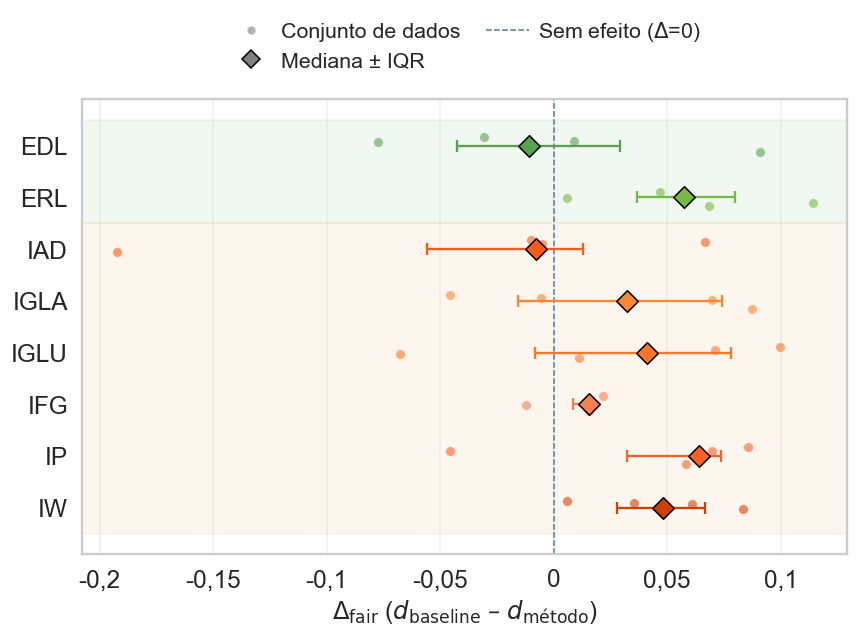

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_method_C_false_negative_rate_difference.tex
| method   | category       |   n |      median |        iqr |         min |       max |
|:---------|:---------------|----:|------------:|-----------:|------------:|----------:|
| EDL      | pre_processing |   4 | -0.0110061  | 0.0716439  | -0.077318   | 0.0908267 |
| ERL      | pre_processing |   4 |  0.0575435  | 0.0431289  |  0.00580844 | 0.114031  |
| IAD      | in_processing  |   4 | -0.00762062 | 0.0685187  | -0.192275   | 0.0667125 |
| IFG      | in_processing  |   4 |  0.0155947  | 0.00862645 | -0.0120178  | 0.021758  |
| IGLA     | in_processing  |   4 |  0.0320998  | 0.0898833  | -0.0456081  | 0.0872929 |
| IGLU     | in_processing  |   4 |  0.0411953  | 0.0867099  | -0.0675676  | 0.0995207 |
| IP       | in_processing  |   4 |  0.0640772  | 0.0414517  | -0.0456081  | 0.0857355 |
| IW       | in_processing  |   4 |  0.0480298  | 0.0385216  |  0.00580844 | 0.

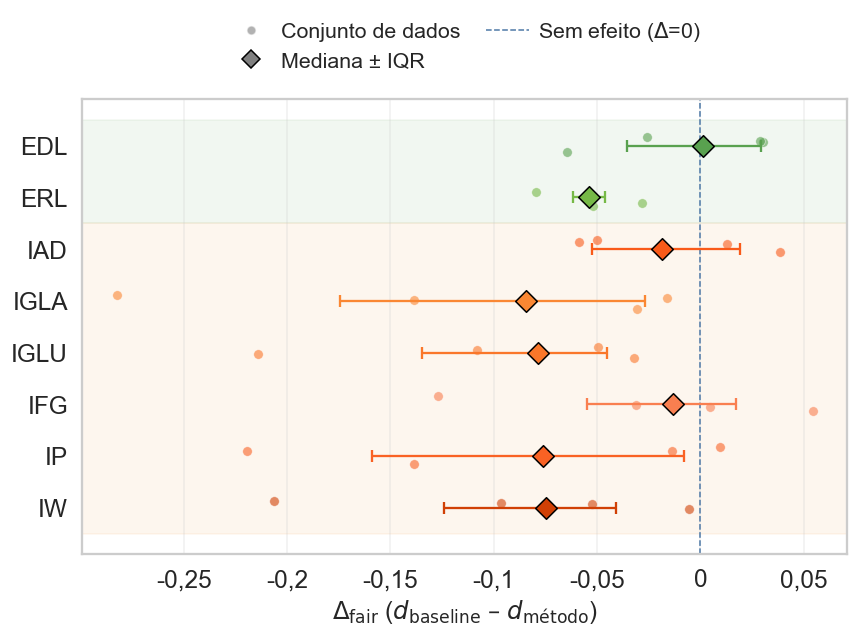

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_method_C_false_discovery_rate_difference.tex
| method   | category       |   n |      median |       iqr |        min |         max |
|:---------|:---------------|----:|------------:|----------:|-----------:|------------:|
| EDL      | pre_processing |   4 |  0.00145827 | 0.0650201 | -0.064694  |  0.0302783  |
| ERL      | pre_processing |   4 | -0.0539065  | 0.0153874 | -0.0794001 | -0.0281655  |
| IAD      | in_processing  |   4 | -0.0185411  | 0.0716615 | -0.0589935 |  0.0384122  |
| IFG      | in_processing  |   4 | -0.0131208  | 0.0721885 | -0.127028  |  0.0542677  |
| IGLA     | in_processing  |   4 | -0.0845766  | 0.147487  | -0.282152  | -0.0159655  |
| IGLU     | in_processing  |   4 | -0.0787064  | 0.0893647 | -0.214227  | -0.0320904  |
| IP       | in_processing  |   4 | -0.0762153  | 0.150639  | -0.219313  |  0.00933967 |
| IW       | in_processing  |   4 | -0.0746226  | 0.0830071 | -0.206103  | -0.

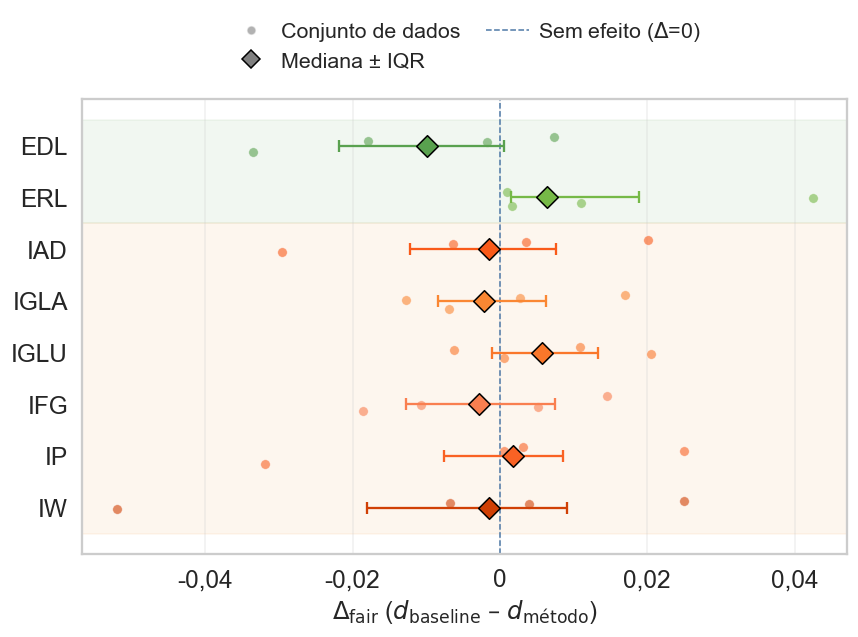

Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_delta_fair_method_C_error_rate_difference.tex
| method   | category       |   n |      median |       iqr |         min |        max |
|:---------|:---------------|----:|------------:|----------:|------------:|-----------:|
| EDL      | pre_processing |   4 | -0.0098438  | 0.0223709 | -0.0334395  | 0.00736416 |
| ERL      | pre_processing |   4 |  0.00635494 | 0.0174319 |  0.0009034  | 0.042444   |
| IAD      | in_processing  |   4 | -0.00142455 | 0.0197668 | -0.0295451  | 0.020056   |
| IFG      | in_processing  |   4 | -0.00281881 | 0.0201963 | -0.0185218  | 0.014567   |
| IGLA     | in_processing  |   4 | -0.00211607 | 0.0146586 | -0.0127032  | 0.0170243  |
| IGLU     | in_processing  |   4 |  0.00571875 | 0.014381  | -0.00625249 | 0.0205224  |
| IP       | in_processing  |   4 |  0.00181885 | 0.0161773 | -0.0318288  | 0.0249534  |
| IW       | in_processing  |   4 | -0.00144797 | 0.0272356 | -0.0519353  | 0.0249534  |

In [218]:
# RQ2 — Padrão C: Δfairness por MÉTODO individual

rq1_utils._VIZ.update({
    "title_fontsize": 18,
    "label_fontsize": 16,
    "tick_fontsize": 16,
    "legend_fontsize": 14,
})



for m in metrics_C:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="C",
    )
    if delta_method.empty:
        continue

    metric_label = translate.get(m, m)

    plot_delta_fairness_method(
        delta_method, metric=m, translate=translate,
        save_path=RQ2_FIGS / f"delta_fairness_by_method_C_{m}.pdf",
    )

    save_delta_table(
        delta_method, group_cols=["method", "category"],
        caption=f"Δfairness por método — {metric_label} (Padrão C)",
        label=f"tab_rq2_delta_fair_method_C_{m}",
        result_dir=RQ2_TABLES,
    )

In [219]:
# Win rate por método — Padrão C
winrate_C_method_rows = []

for m in metrics_C:
    delta_method = compute_delta_fairness_method(
        df, metric=m, ideal_values=ideal_values, scope="C",
    )
    if delta_method.empty:
        continue
    wr = compute_win_rate(delta_method, group_col="method")
    wr["metric"] = m
    winrate_C_method_rows.append(wr)

if winrate_C_method_rows:
    winrate_C_method = pd.concat(winrate_C_method_rows, ignore_index=True)
    winrate_C_method["metric_label"] = winrate_C_method["metric"].map(lambda x: translate.get(x, x))
    winrate_C_method["win_rate_pct"] = (winrate_C_method["win_rate"] * 100).round(1)
    display(
        winrate_C_method[["metric_label", "method", "n", "wins", "win_rate_pct"]]
        .rename(columns={
            "metric_label": "Métrica", "method": "Método",
            "n": "N datasets", "wins": "Vitórias (Δ>0)", "win_rate_pct": "Win rate (%)",
        })
    )
    latex_and_save(
        winrate_C_method[["metric_label", "method", "n", "wins", "win_rate_pct"]],
        caption="Win rate por método — Padrão C",
        label="tab_rq2_winrate_method_C",
        result_dir=RQ2_TABLES,
    )

,Métrica,Método,N datasets,Vitórias (Δ>0),Win rate (%)
0,Diferença de Taxa de Falsos Negativos,EDL,4,2,50.0
1,Diferença de Taxa de Falsos Negativos,ERL,4,4,100.0
2,Diferença de Taxa de Falsos Negativos,IAD,4,1,25.0
3,Diferença de Taxa de Falsos Negativos,IFG,4,3,75.0
4,Diferença de Taxa de Falsos Negativos,IGLA,4,2,50.0
5,Diferença de Taxa de Falsos Negativos,IGLU,4,3,75.0
6,Diferença de Taxa de Falsos Negativos,IP,4,3,75.0
7,Diferença de Taxa de Falsos Negativos,IW,4,4,100.0
8,Diferença de Taxa de Falsa Descoberta,EDL,4,2,50.0
9,Diferença de Taxa de Falsa Descoberta,ERL,4,0,0.0


Tabela salva em: experiments\results\analysis\RQ2\tables\tab_rq2_winrate_method_C.tex
| metric_label                          | method   |   n |   wins |   win_rate_pct |
|:--------------------------------------|:---------|----:|-------:|---------------:|
| Diferença de Taxa de Falsos Negativos | EDL      |   4 |      2 |             50 |
| Diferença de Taxa de Falsos Negativos | ERL      |   4 |      4 |            100 |
| Diferença de Taxa de Falsos Negativos | IAD      |   4 |      1 |             25 |
| Diferença de Taxa de Falsos Negativos | IFG      |   4 |      3 |             75 |
| Diferença de Taxa de Falsos Negativos | IGLA     |   4 |      2 |             50 |
| Diferença de Taxa de Falsos Negativos | IGLU     |   4 |      3 |             75 |
| Diferença de Taxa de Falsos Negativos | IP       |   4 |      3 |             75 |
| Diferença de Taxa de Falsos Negativos | IW       |   4 |      4 |            100 |
| Diferença de Taxa de Falsa Descoberta | EDL      |   4 |      

In [220]:
# Teste estatístico: Friedman + Holm por MÉTODO — Padrão C
stats_exp_C = run_all_experiment_analysis(
    df, ideal_values=ideal_values, scopes=["C"], metrics=metrics_C,
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_exp_omnibus, cols_posthoc=cols_exp_posthoc,
)

# Tabela consolidada por método — Padrão C
save_results_latex(
    stats_exp_C, metric='', analysis_type='experiment',
    save_dir=RQ2_TABLES, translate=translate,
    cols_omnibus=cols_exp_omnibus, cols_posthoc=cols_exp_posthoc,
    scope_suffix='method_C'
)

stats_exp_C_omnibus = stats_exp_C.loc[stats_exp_C["test"].isin(["friedman", "wilcoxon"])].copy()
stats_exp_C_posthoc = stats_exp_C.loc[stats_exp_C["test"] == "posthoc_holm"].copy()

print("=== Omnibus (Friedman) por método — Padrão C ===")
display(stats_exp_C_omnibus[cols_exp_omnibus])
print("\n=== Pós-hoc (Holm) vs baseline típico — Padrão C ===")
display(stats_exp_C_posthoc[cols_exp_posthoc])


  false_negative_rate_difference - Análise por Método

📊 Teste Friedman (omnibus)
   N datasets: 4, k métodos: 9
   Estatística = 6.0292, p = 0.6440
   Estatísticas descritivas:
   ----------------------------------------------------------------------------------------------------
   Método               Median(d)    Median(Δfair)  IQR(Δfair)   Median(raw)  IQR(raw)   N
   ----------------------------------------------------------------------------------------------------
   baseline_typical     0.1409       0.0000         0.0000       -0.0443      0.2208     4
   EDL                  0.1322       -0.0110        0.0716       -0.0699      0.2240     4
   ERL                  0.0834       0.0575         0.0431       -0.0130      0.0468     4
   IAD                  0.1270       -0.0076        0.0685       -0.0291      0.1757     4
   IGLA                 0.1091       0.0321         0.0899       -0.0983      0.1026     4
   IGLU                 0.0997       0.0412         0.0867       -0

,metric,method,category,p_value,median_delta_fair,iqr_delta_fair
0,false_negative_rate_difference,baseline_typical,baseline,0.643958,0.000000,0.000000
1,false_negative_rate_difference,EDL,pre_processing,0.643958,-0.011006,0.071644
2,false_negative_rate_difference,ERL,pre_processing,0.643958,0.057543,0.043129
3,false_negative_rate_difference,IAD,in_processing,0.643958,-0.007621,0.068519
4,false_negative_rate_difference,IGLA,in_processing,0.643958,0.032100,0.089883
5,false_negative_rate_difference,IGLU,in_processing,0.643958,0.041195,0.086710
6,false_negative_rate_difference,IFG,in_processing,0.643958,0.015595,0.008626
7,false_negative_rate_difference,IP,in_processing,0.643958,0.064077,0.041452
8,false_negative_rate_difference,IW,in_processing,0.643958,0.048030,0.038522
17,false_discovery_rate_difference,baseline_typical,baseline,0.190622,0.000000,0.000000



=== Pós-hoc (Holm) vs baseline típico — Padrão C ===


,metric,method,category,avg_rank,p_holm,median_delta_fair,iqr_delta_fair
9,false_negative_rate_difference,EDL,pre_processing,5.000,0.998765,-0.011006,0.071644
10,false_negative_rate_difference,ERL,pre_processing,2.875,0.244859,0.057543,0.043129
11,false_negative_rate_difference,IAD,in_processing,6.750,0.998765,-0.007621,0.068519
12,false_negative_rate_difference,IGLA,in_processing,5.500,0.998765,0.032100,0.089883
13,false_negative_rate_difference,IGLU,in_processing,4.750,0.998765,0.041195,0.086710
14,false_negative_rate_difference,IFG,in_processing,5.000,0.998765,0.015595,0.008626
15,false_negative_rate_difference,IP,in_processing,4.000,0.688470,0.064077,0.041452
16,false_negative_rate_difference,IW,in_processing,4.625,0.998765,0.048030,0.038522
26,false_discovery_rate_difference,EDL,pre_processing,2.750,1.000000,0.001458,0.065020
27,false_discovery_rate_difference,ERL,pre_processing,5.500,1.000000,-0.053906,0.015387


## 4) RQ3 — A intensidade do viés afeta mitigação?

**Objetivo:** Verificar se a eficácia dos métodos depende da **magnitude inicial do gap** no baseline.

**Hipóteses:**
- **Proporcional:** $\Delta|gap|$ aumenta linearmente com $|gap|_{baseline}$ (mais viés → mais redução).
- **Teto/piso (saturação):** redução estabiliza (ou diminui) em gaps extremos.
- **Independente:** sem correlação entre magnitude e redução.

**Abordagem:**
- **Mitigação relativa** = $\Delta|gap| / |gap|_{baseline}$ — fração do gap removida (adimensional, comparável entre métricas).
- **Heatmap** método × métrica: mediana da mitigação relativa (visão compacta).
- **Strip chart pooled**: distribuição cross-metric da mitigação relativa por método.
- **Strip chart facetado**: distribuição per-metric (small multiples) como alternativa.
- Correlação Spearman $
ho$ e tabelas de resumo como suporte.

**Nota sobre N=6:** com apenas 6 datasets, o poder estatístico é limitado. 
Ênfase no tamanho de efeito ($
ho$, $r$), não em p-valores.

In [221]:
# === Controle de fontes — RQ3 ===
from auxiliar_analysis import rq3_utils

rq3_utils._VIZ.update({
    "title_fontsize": 16,
    "subtitle_fontsize": 12,
    "label_fontsize": 15,
    "tick_fontsize": 16,
    "legend_fontsize": 13,
    "annotation_fontsize": 12,
    "suptitle_fontsize": 14,
    "colorbar_label_fontsize": 12,
    "supxlabel_fontsize": 13,
    "facet_title_fontsize": 11,
    "facet_tick_fontsize": 11,
    "facet_suptitle_fontsize": 15,
    "severity_title_fontsize": 15,
})


In [222]:
# RQ3 — Setup: importações e construção dos dados de scatter
from auxiliar_analysis.rq3_utils import (
    build_intensity_scatter_data,
    compute_intensity_correlation_table,
    build_intensity_summary_table,
)

# Dados por método individual
scatter_all = build_intensity_scatter_data(
    df, classified,
    metrics=sorted(METRICS_PAPER),
    ideal_values=ideal_values,
    scope="all", level="method",
)

# Dados por categoria (pre vs in-processing) — para perfil por categoria
scatter_cat = build_intensity_scatter_data(
    df, classified,
    metrics=sorted(METRICS_PAPER),
    ideal_values=ideal_values,
    scope="all", level="category",
)

# ── Remover datasets inelegíveis (severity_level == 0) ──
_n_all_before = len(scatter_all)
_n_cat_before = len(scatter_cat)
scatter_all = scatter_all[scatter_all["severity_level"] > 0].reset_index(drop=True)
scatter_cat = scatter_cat[scatter_cat["severity_level"] > 0].reset_index(drop=True)
print(f"Inelegíveis removidos: scatter_all {_n_all_before} → {len(scatter_all)}, "
      f"scatter_cat {_n_cat_before} → {len(scatter_cat)}")

# ── Verificação ──
print(f"scatter_all : {scatter_all.shape[0]} linhas, "
      f"{scatter_all["metric"].nunique()} métricas, "
      f"{scatter_all["method"].nunique()} métodos")
print(f"scatter_cat : {scatter_cat.shape[0]} linhas, "
      f"{scatter_cat["metric"].nunique()} métricas")
print(f"Métodos    : {sorted(scatter_all["method"].unique())}")
print(f"Categorias : {sorted(scatter_all["category"].dropna().unique())}")

if scatter_all.empty:
    print("⚠ ATENÇÃO: scatter_all está vazio — verificar dados de entrada.")

scatter_all.head(8)


Inelegíveis removidos: scatter_all 336 → 224, scatter_cat 84 → 56
scatter_all : 224 linhas, 7 métricas, 8 métodos
scatter_cat : 56 linhas, 7 métricas
Métodos    : ['EDL', 'ERL', 'IAD', 'IFG', 'IGLA', 'IGLU', 'IP', 'IW']
Categorias : ['in_processing', 'pre_processing']


,dataset,metric,method,category,gap_baseline,delta_fair,mitigation_rel,severity_level,severity_label
0,11_arrhythmia,bias_amplification,EDL,pre_processing,0.039692,0.039692,1.000000,2,medium
1,15_mental,bias_amplification,EDL,pre_processing,0.111302,-0.212929,-1.913077,3,low
2,6_aids,bias_amplification,EDL,pre_processing,0.458255,0.063877,0.139391,1,high
3,11_arrhythmia,bias_amplification,ERL,pre_processing,0.039692,0.039692,1.000000,2,medium
4,15_mental,bias_amplification,ERL,pre_processing,0.111302,0.111302,1.000000,3,low
5,6_aids,bias_amplification,ERL,pre_processing,0.458255,0.370735,0.809014,1,high
6,11_arrhythmia,bias_amplification,IAD,in_processing,0.039692,0.039692,1.000000,2,medium
7,15_mental,bias_amplification,IAD,in_processing,0.111302,-0.509065,-4.573729,3,low


### 4.2b Scatter contínuo: viés baseline × mitigação absoluta

Complementar ao perfil de severidade (que discretiza o eixo X em faixas), 
estes gráficos mantêm o viés baseline contínuo para 
investigar visualmente correlação e proporcionalidade.

**Variáveis:** X = {	ext{baseline}}$, Y = $\Delta_{	ext{fair}}$

Três visualizações:
1. **Scatter por método** — todos os métodos no mesmo painel
2. **Dot-plot por dataset** — eixo X = conjuntos ordenados por {	ext{baseline}}$
3. **Scatter facetado** — um painel por método, pontos rotulados pelo dataset

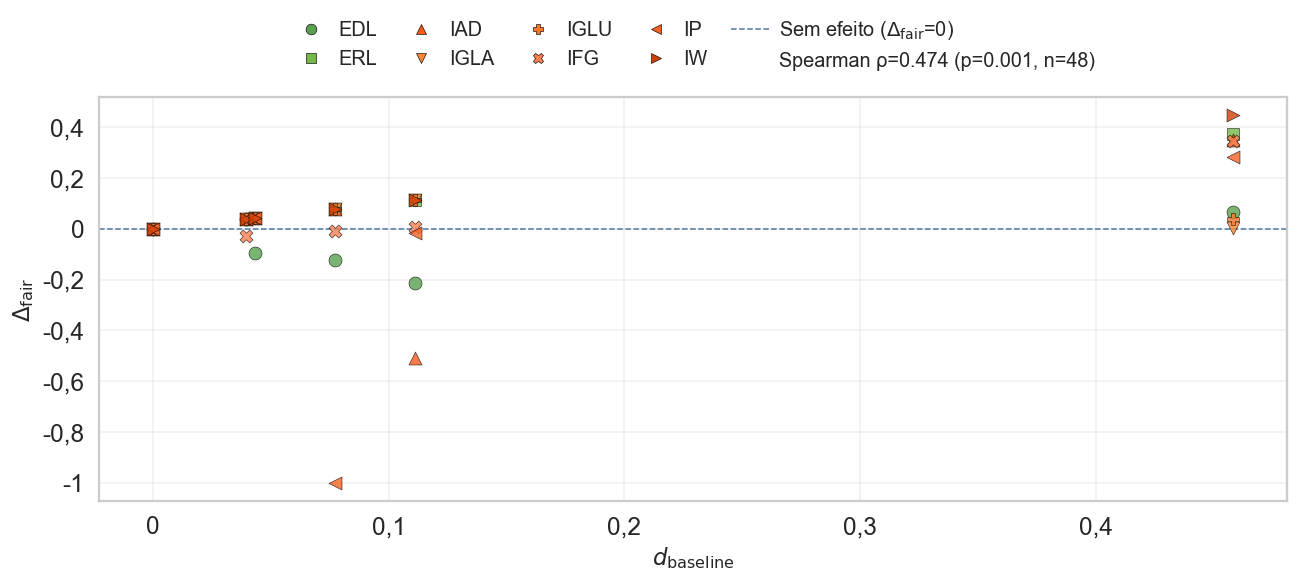

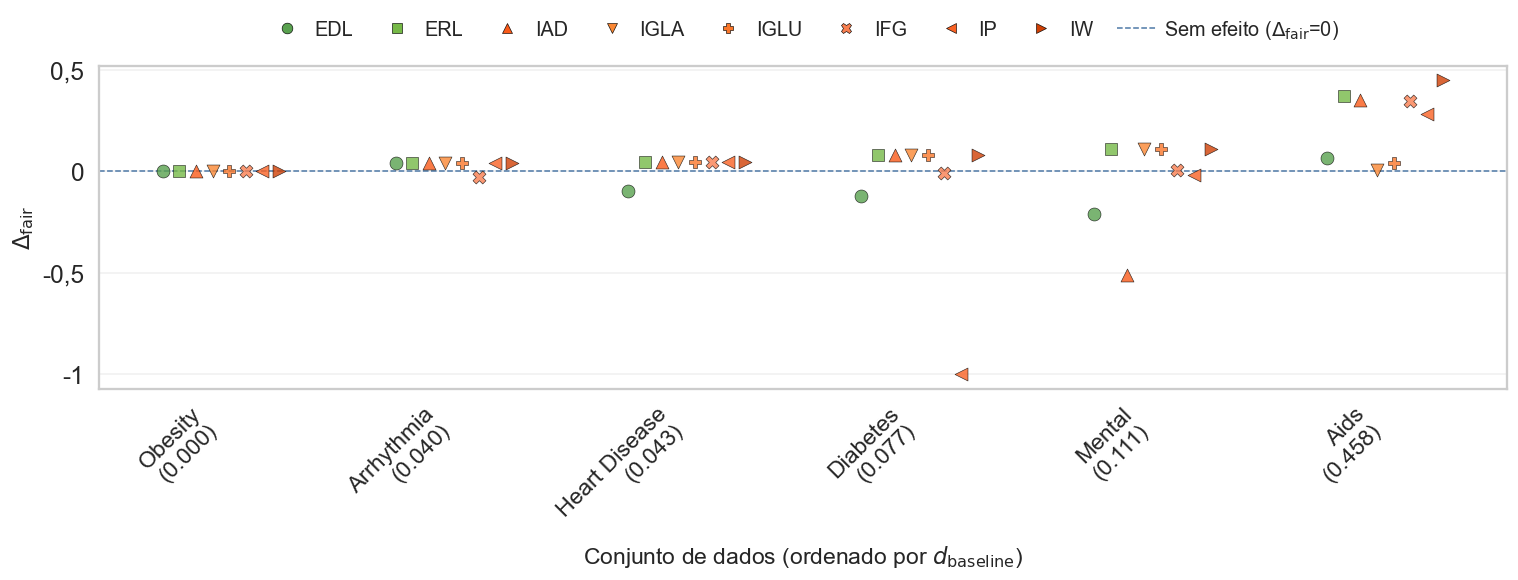

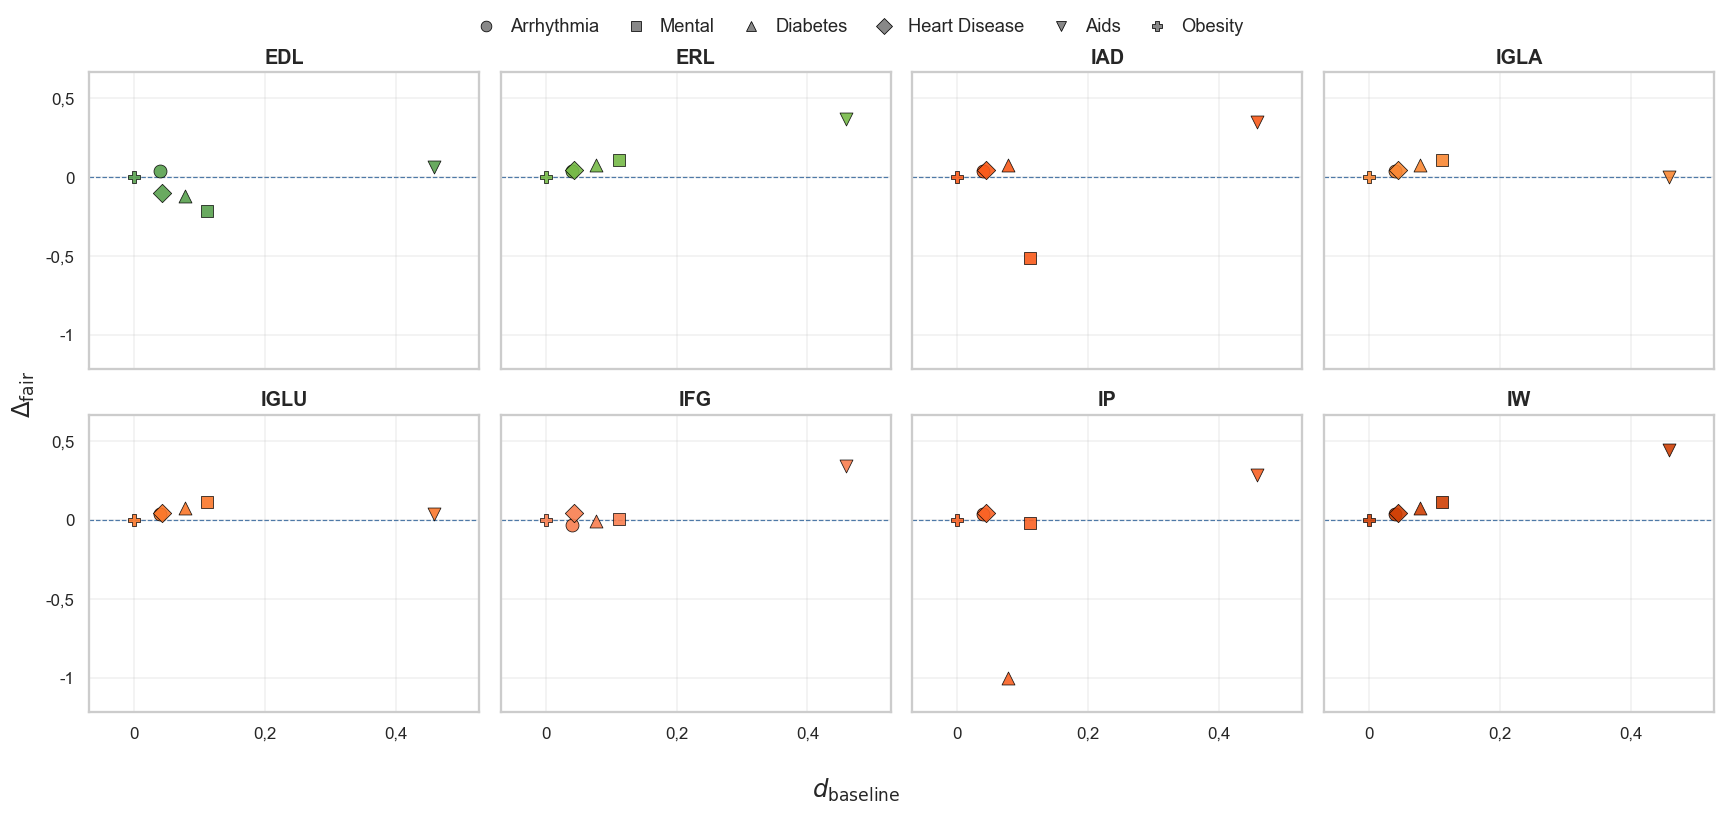

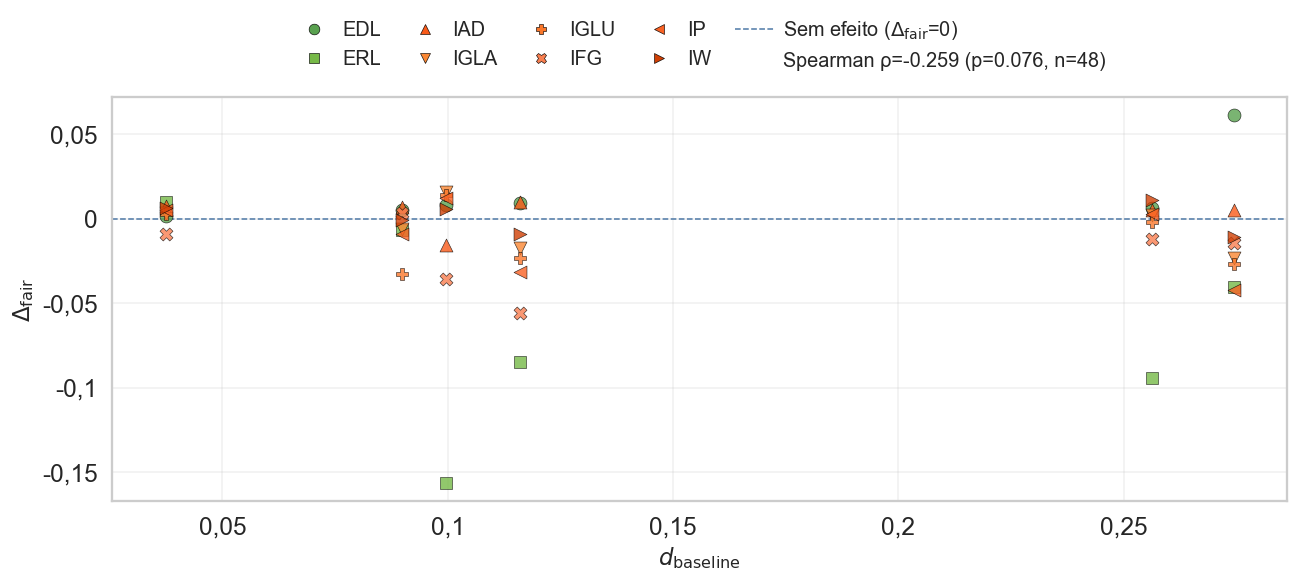

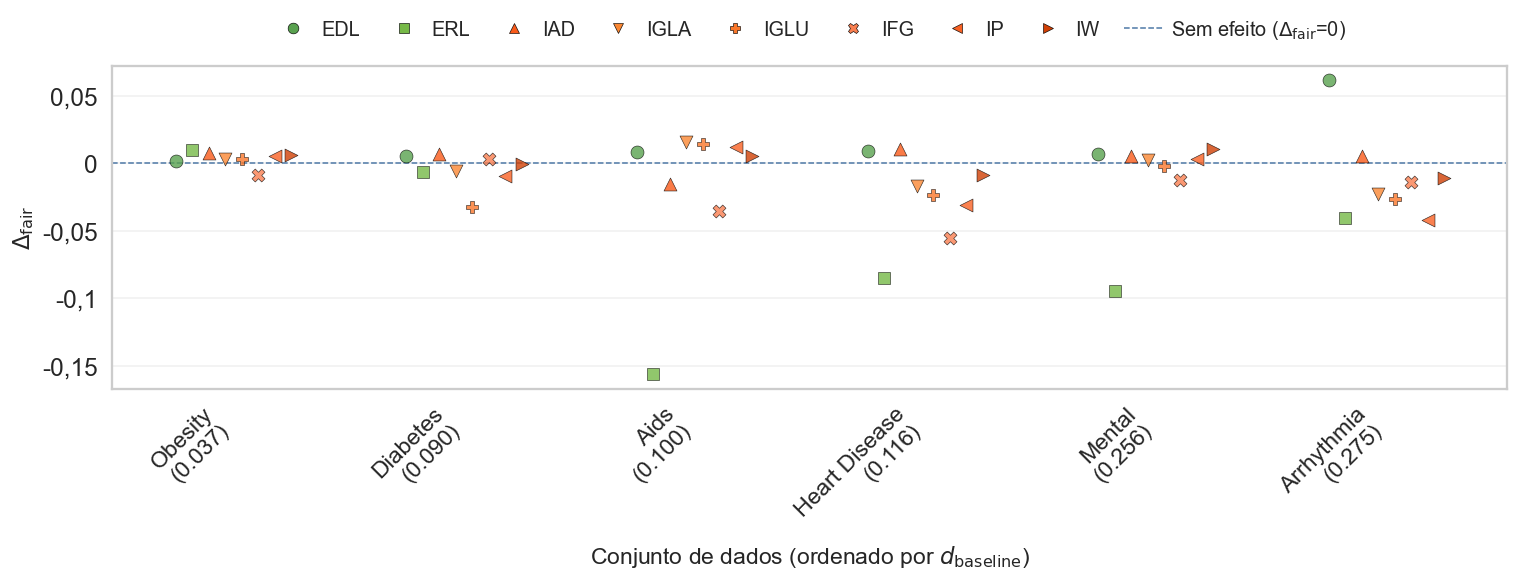

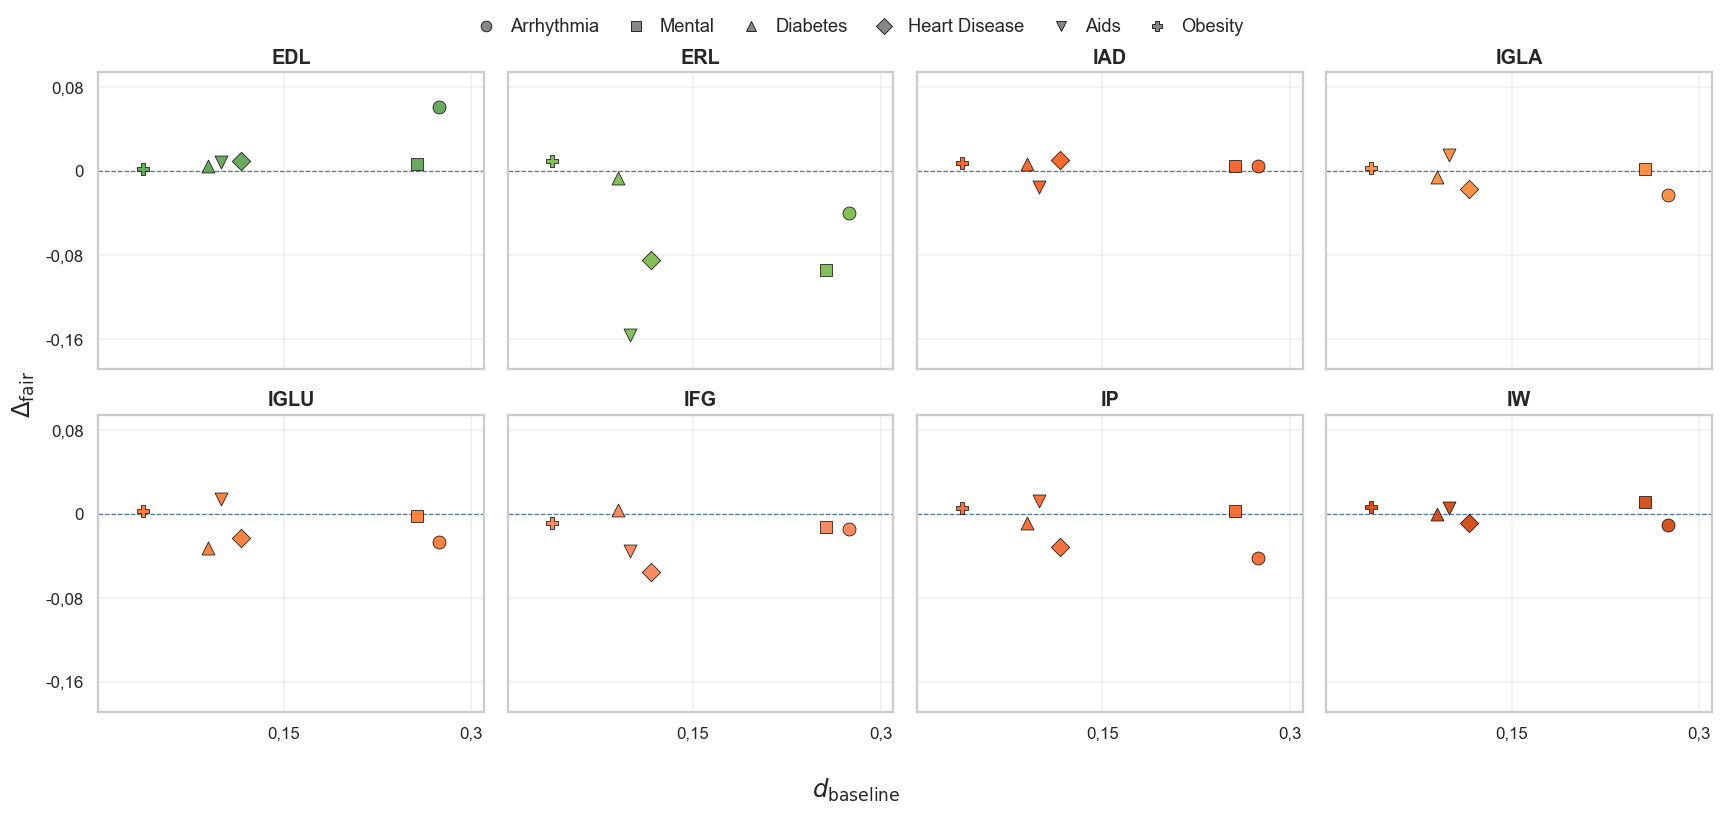

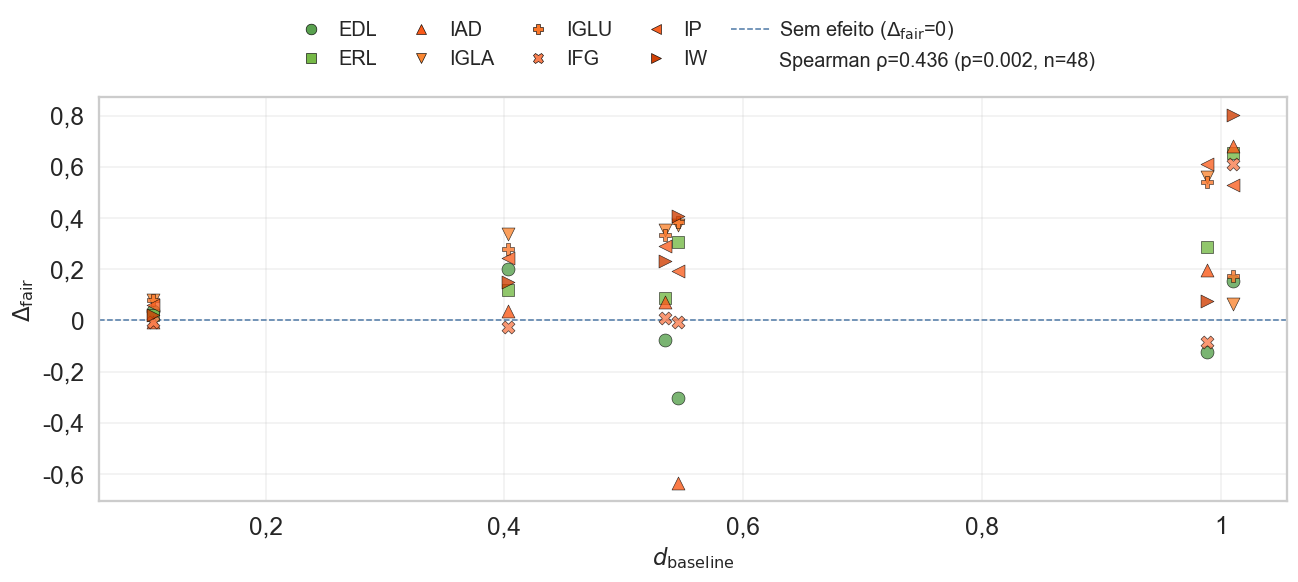

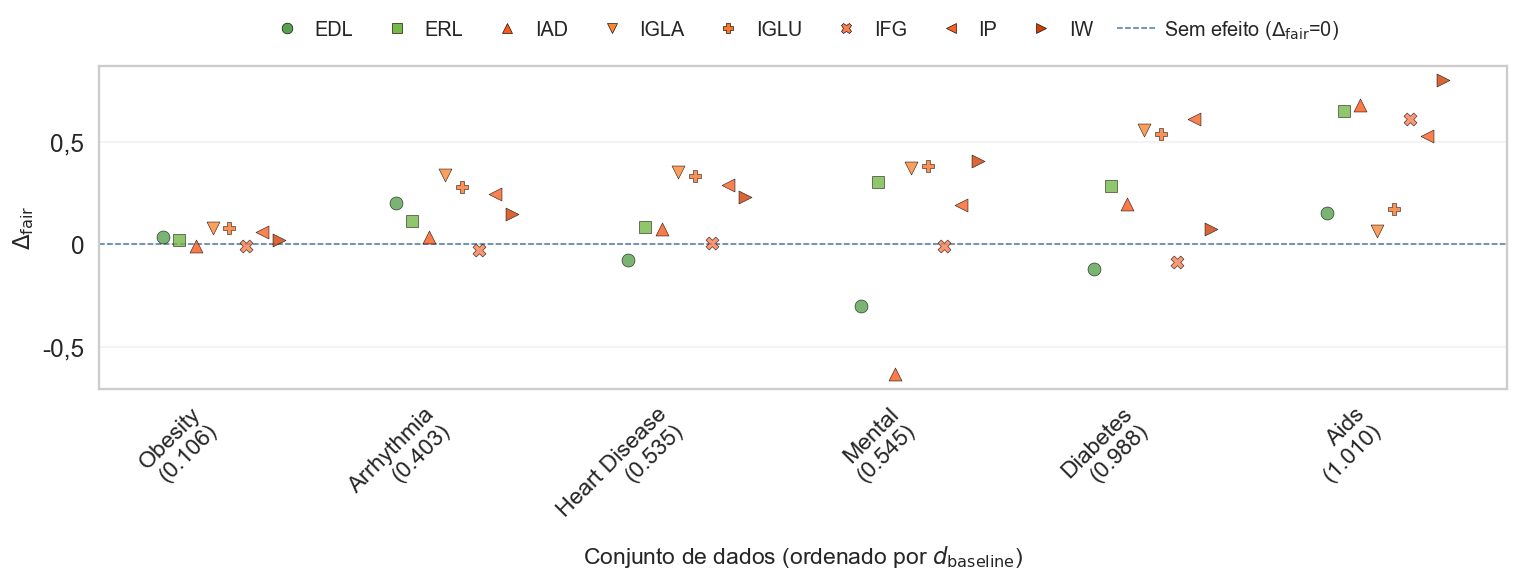

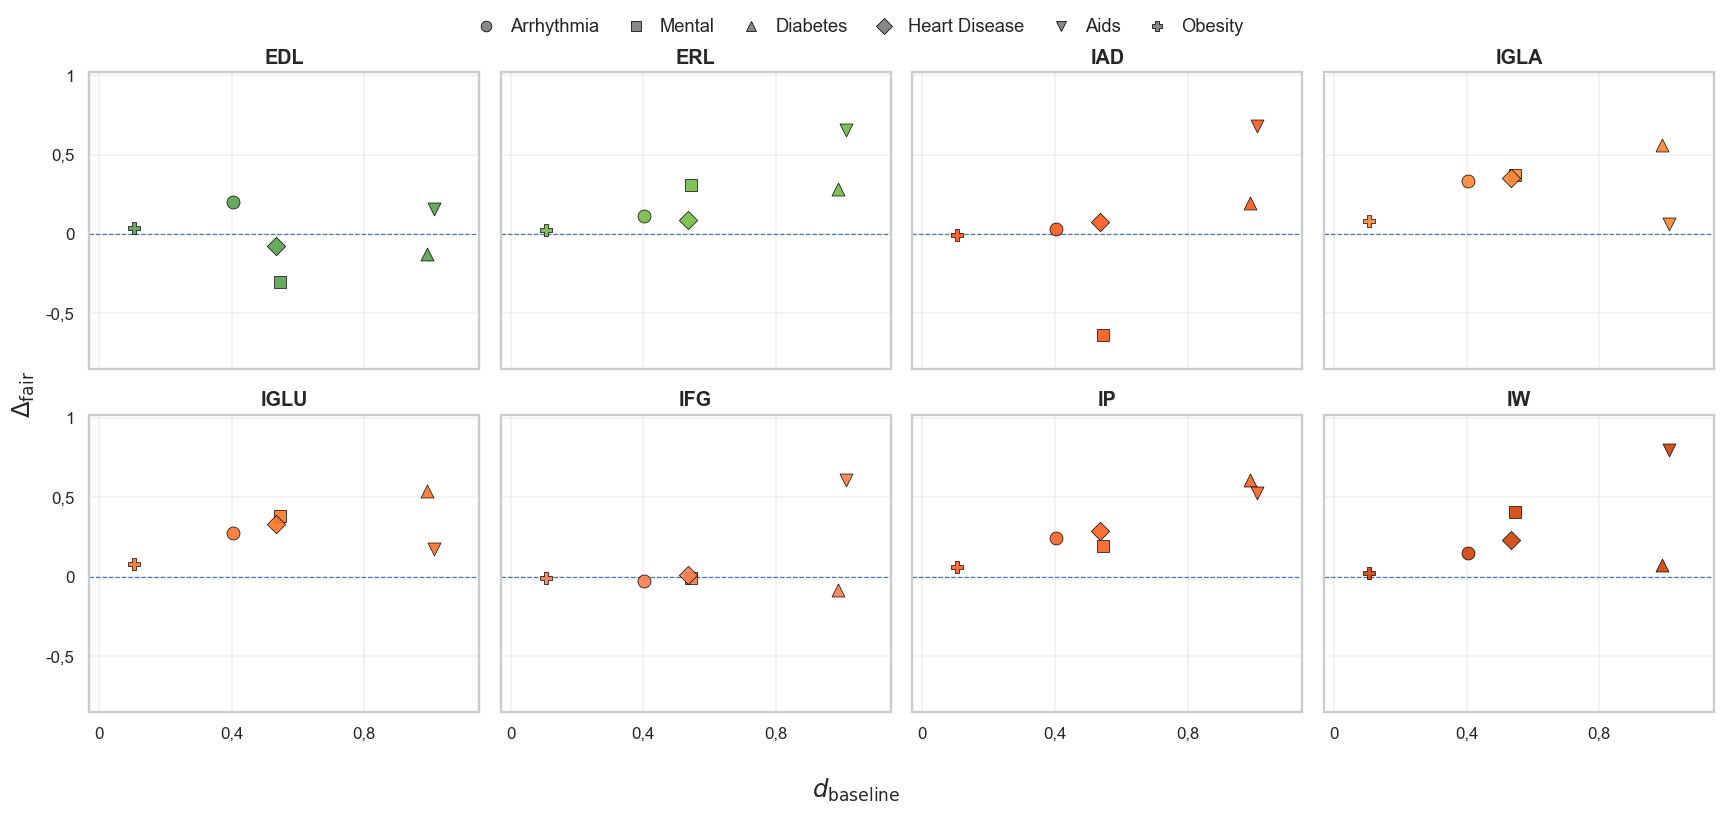

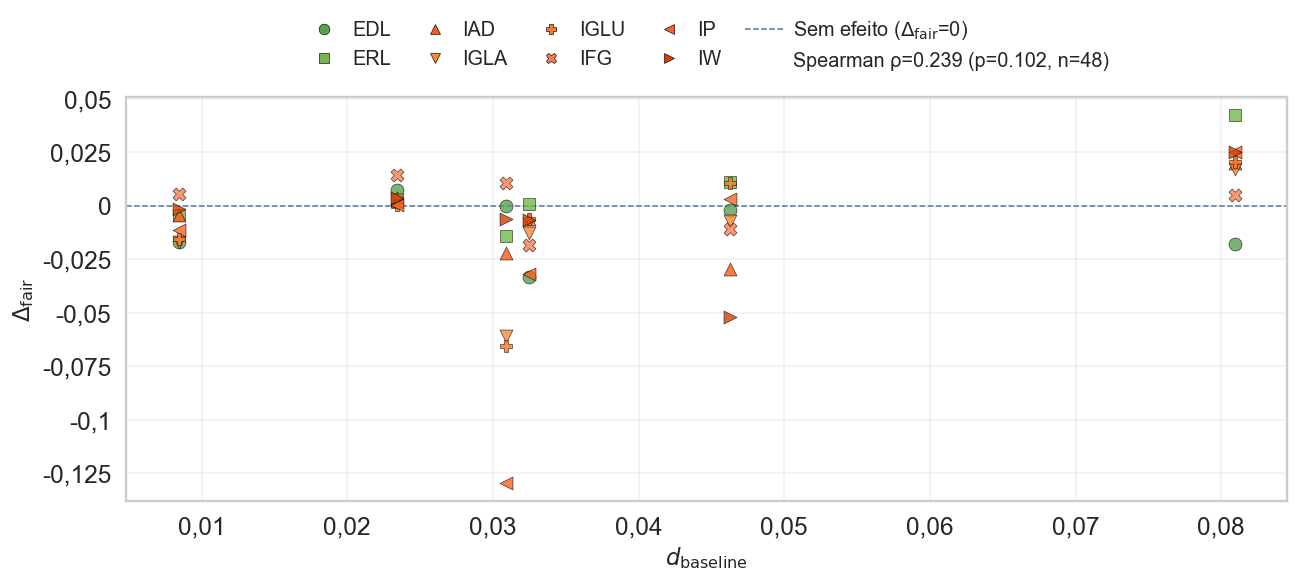

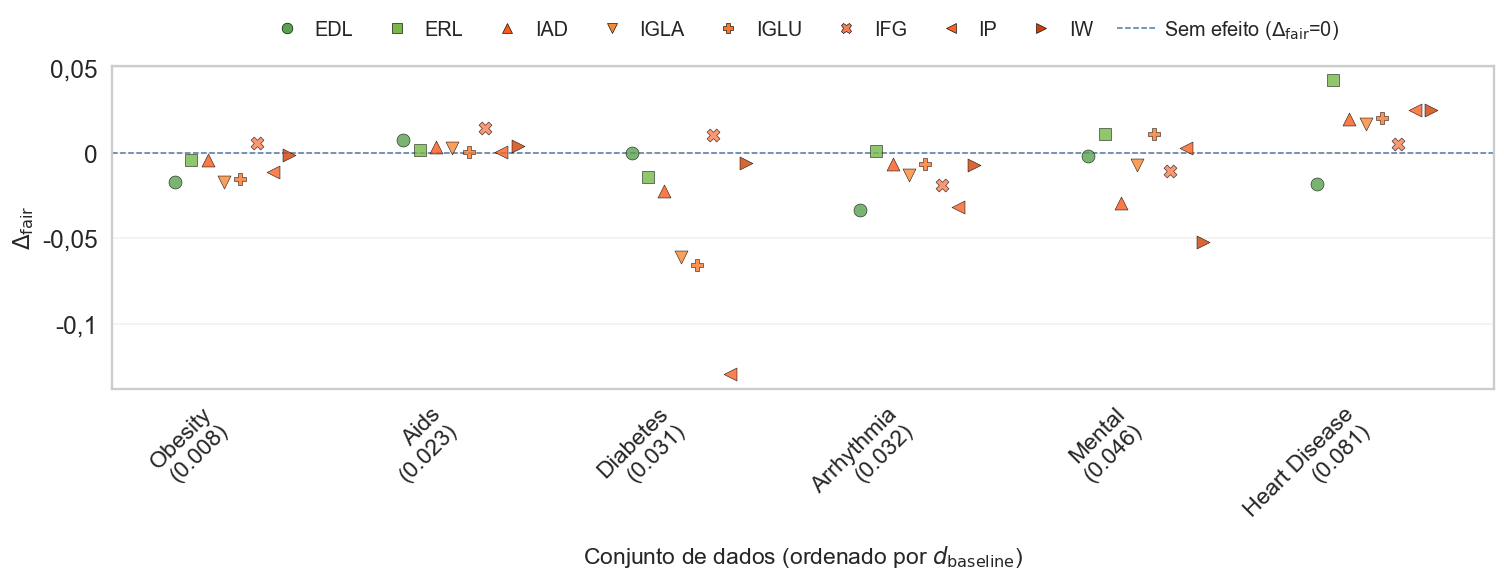

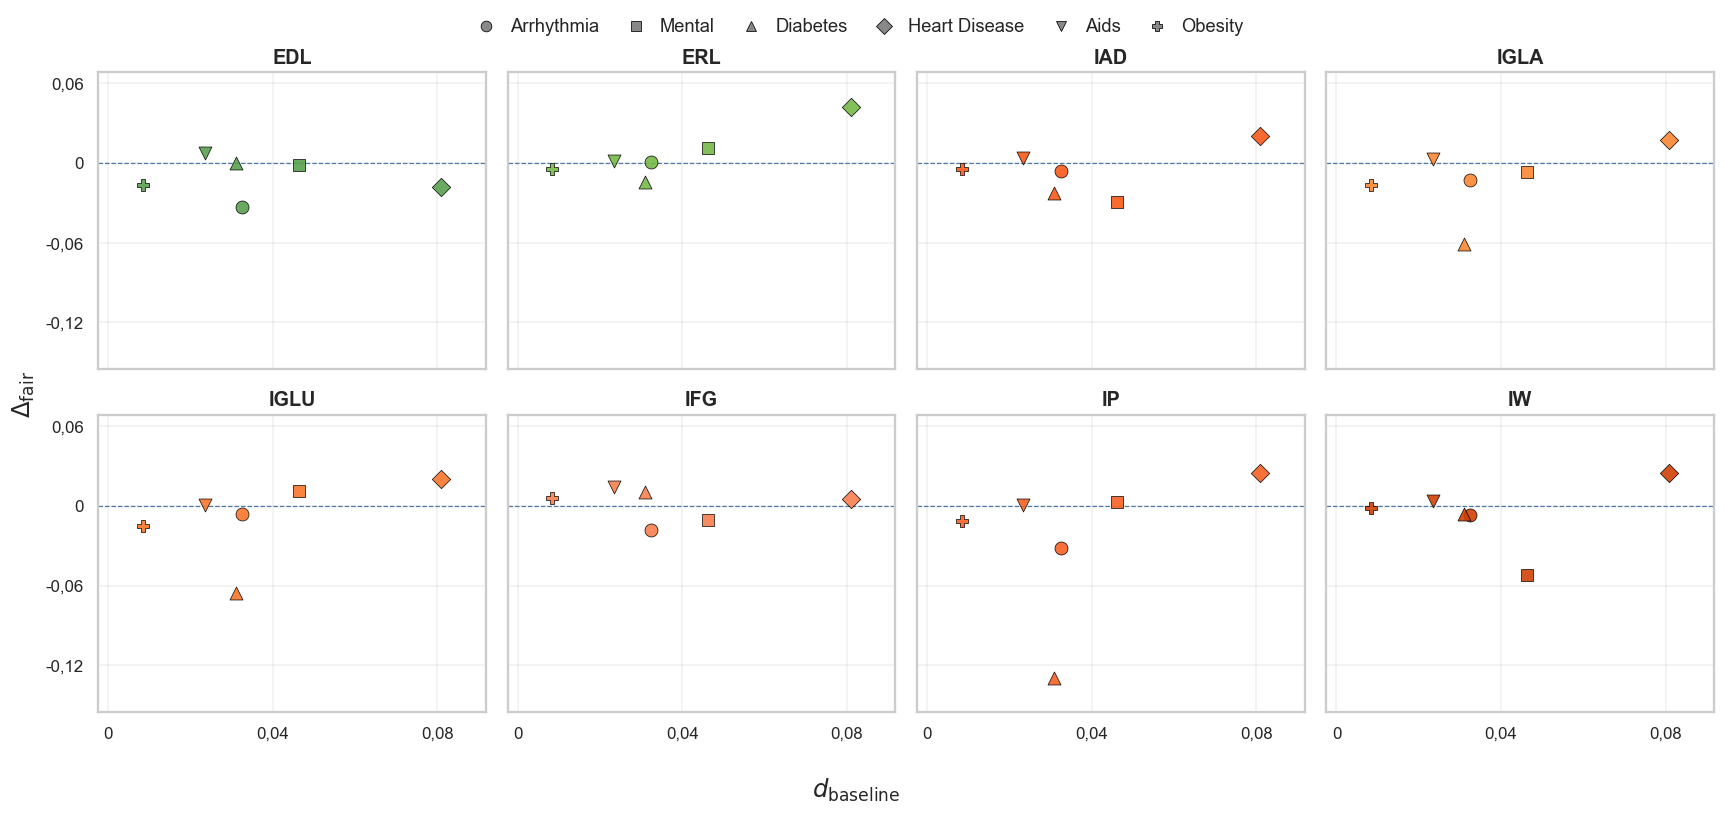

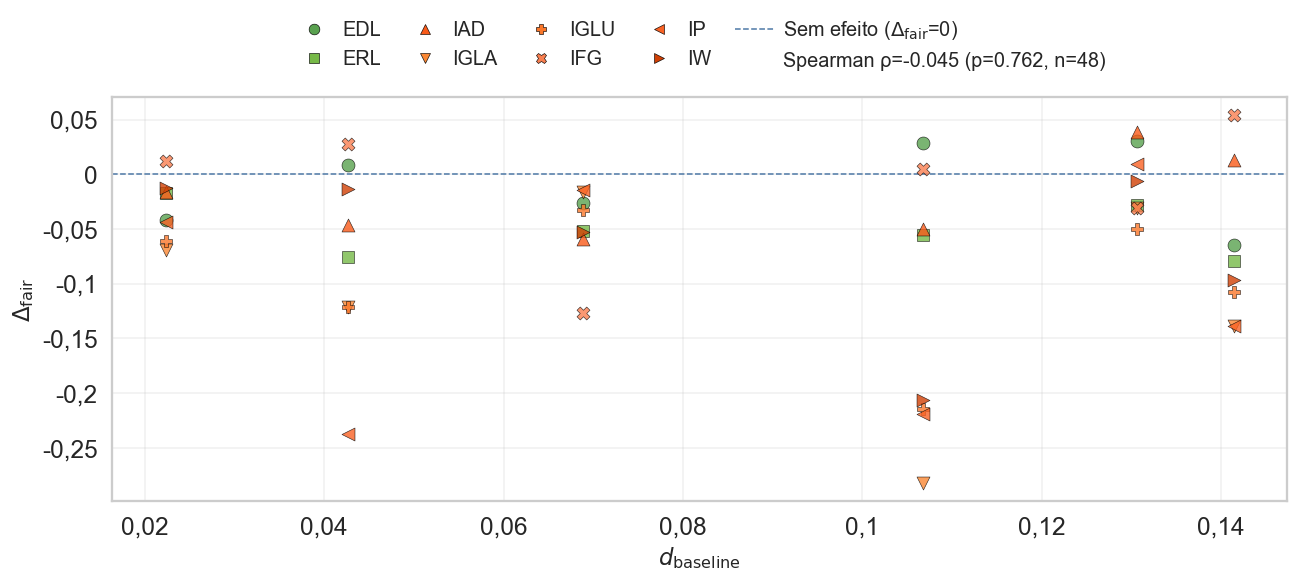

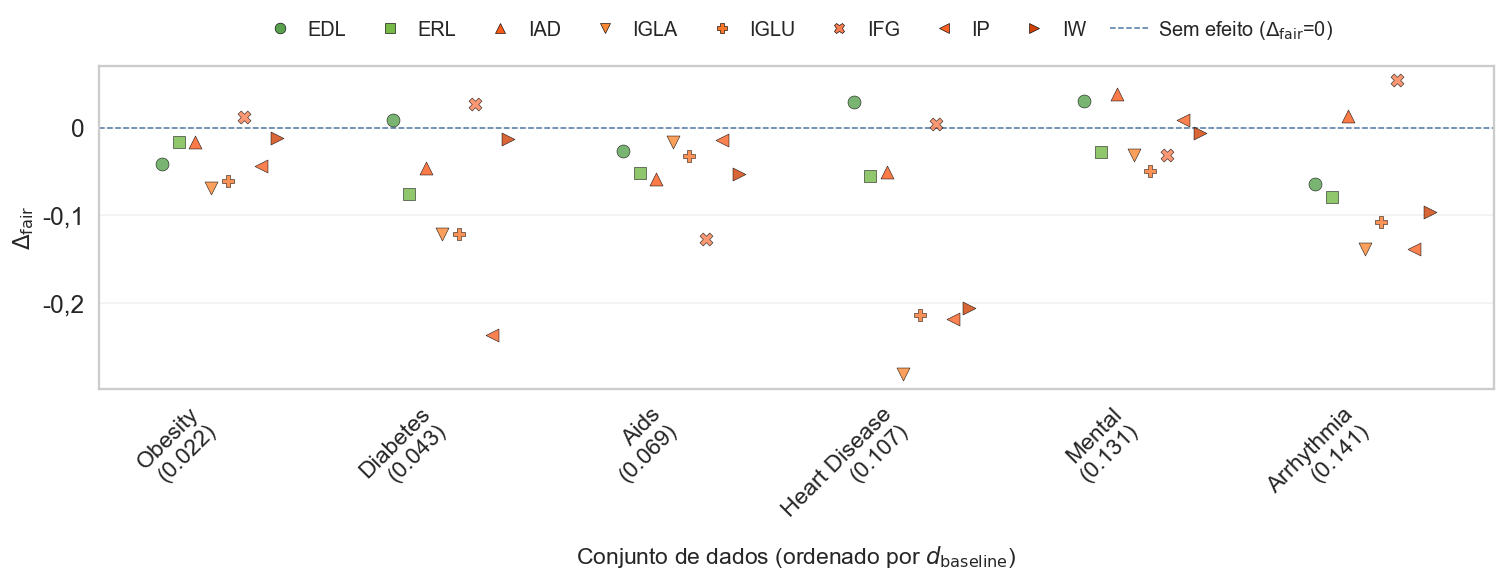

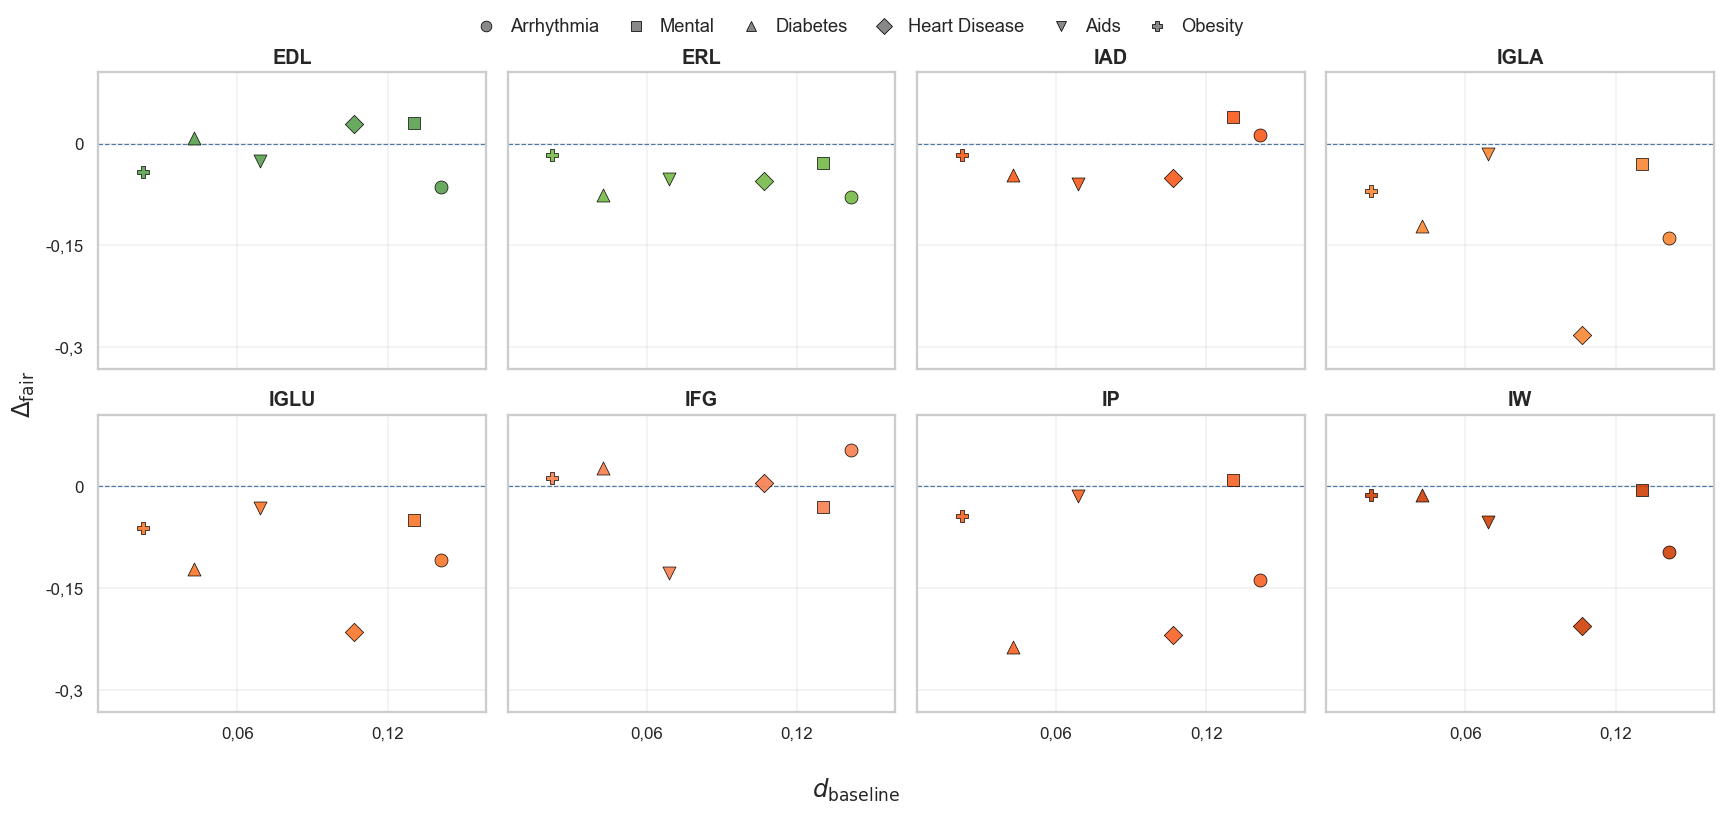

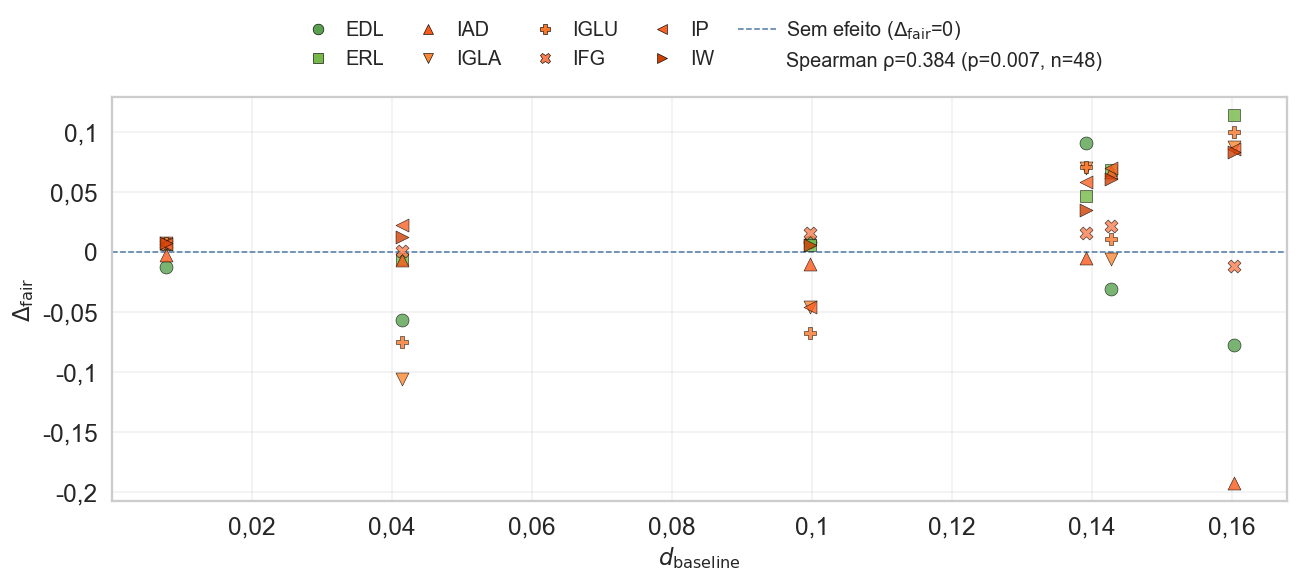

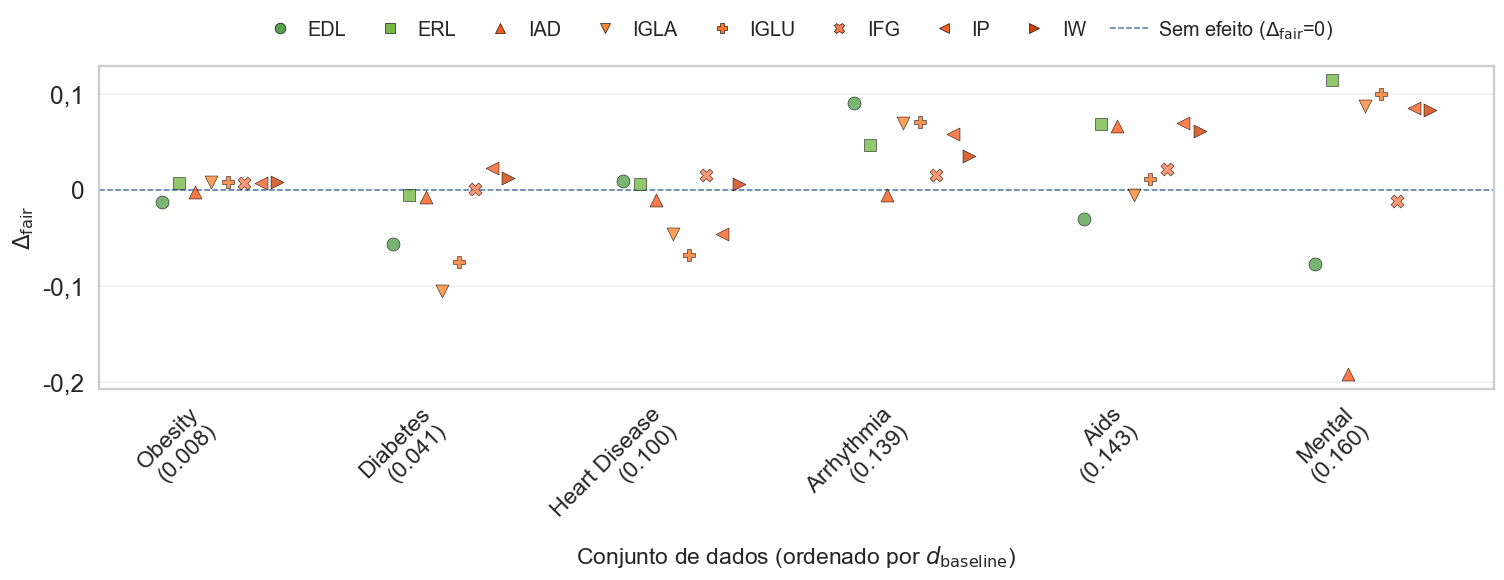

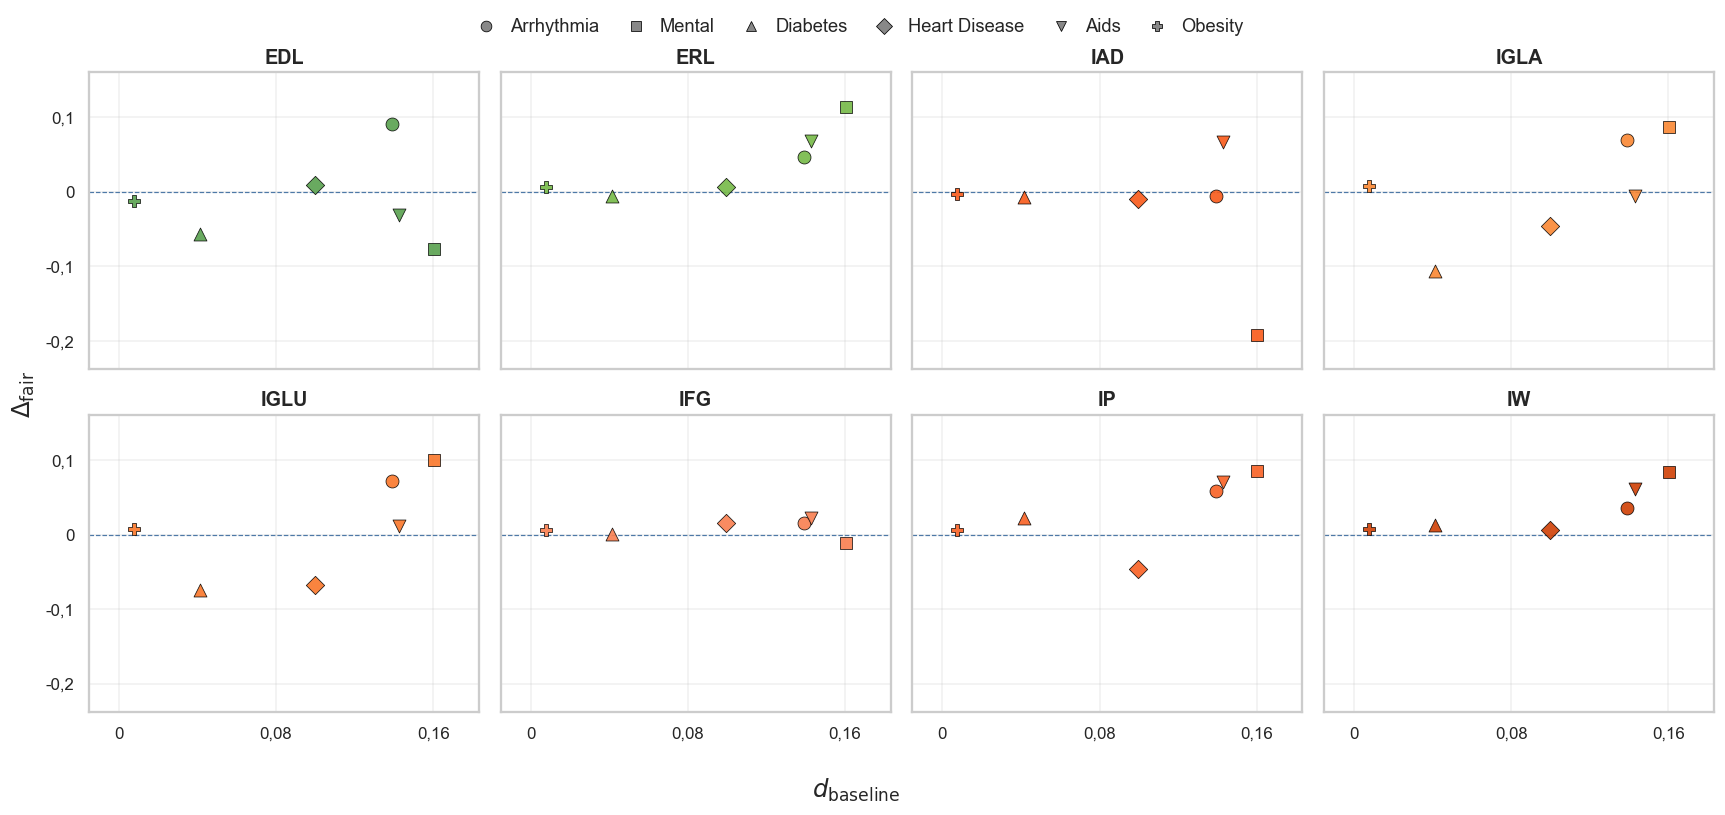

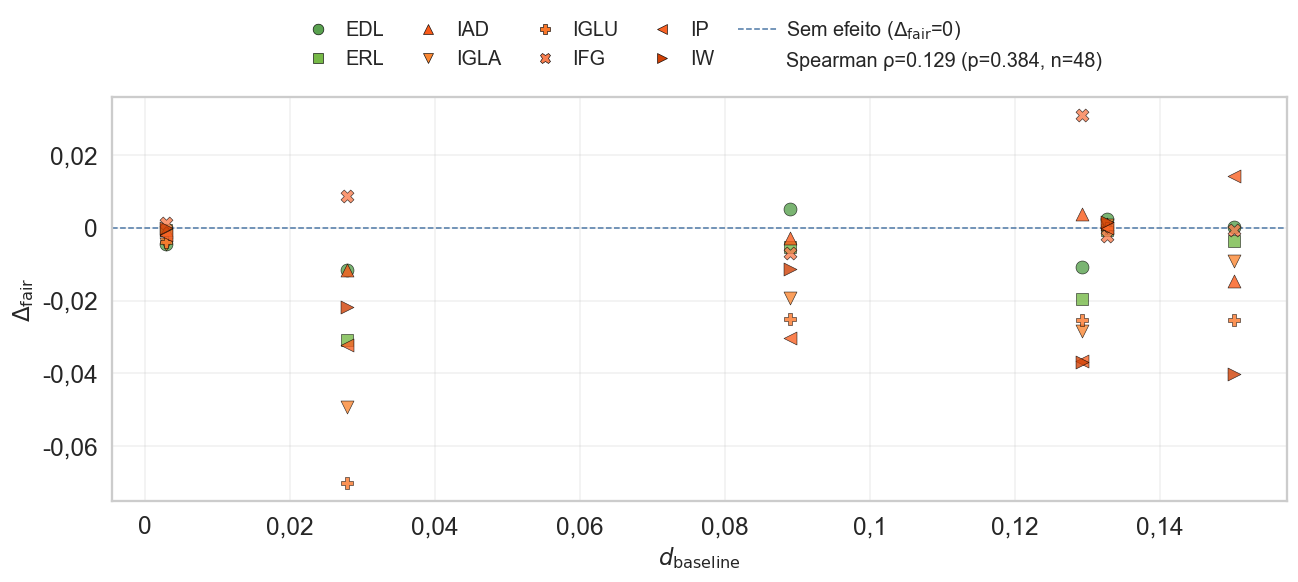

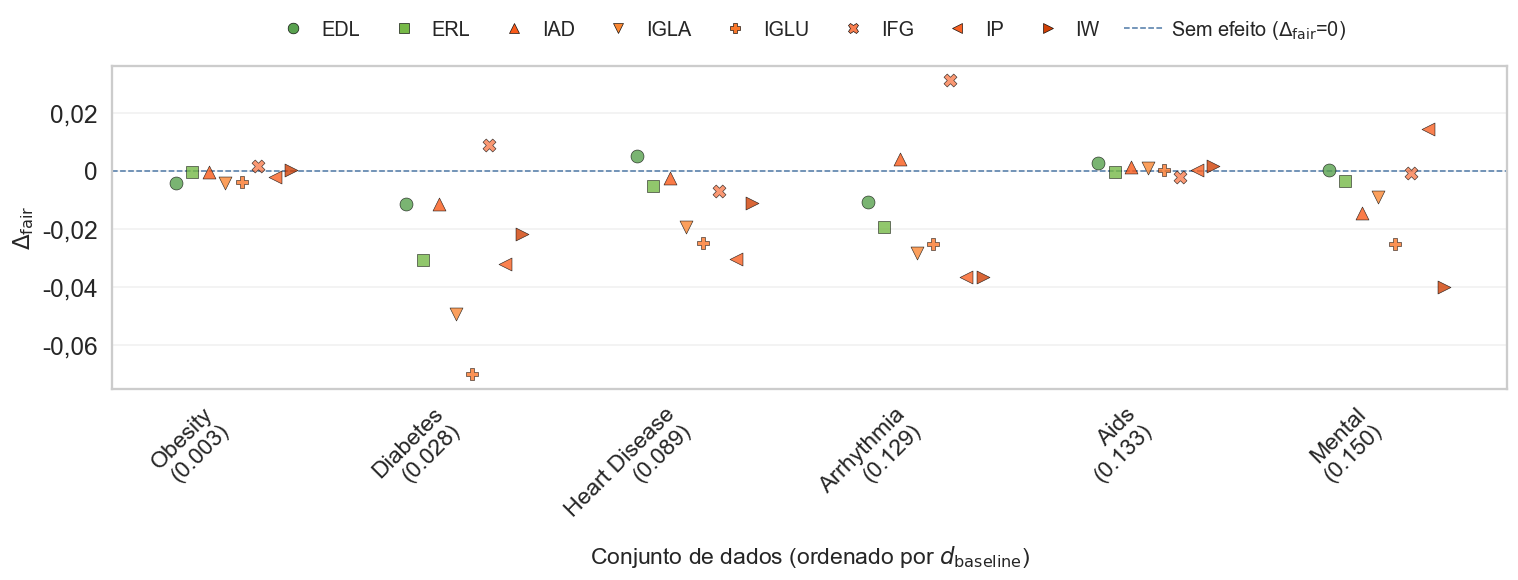

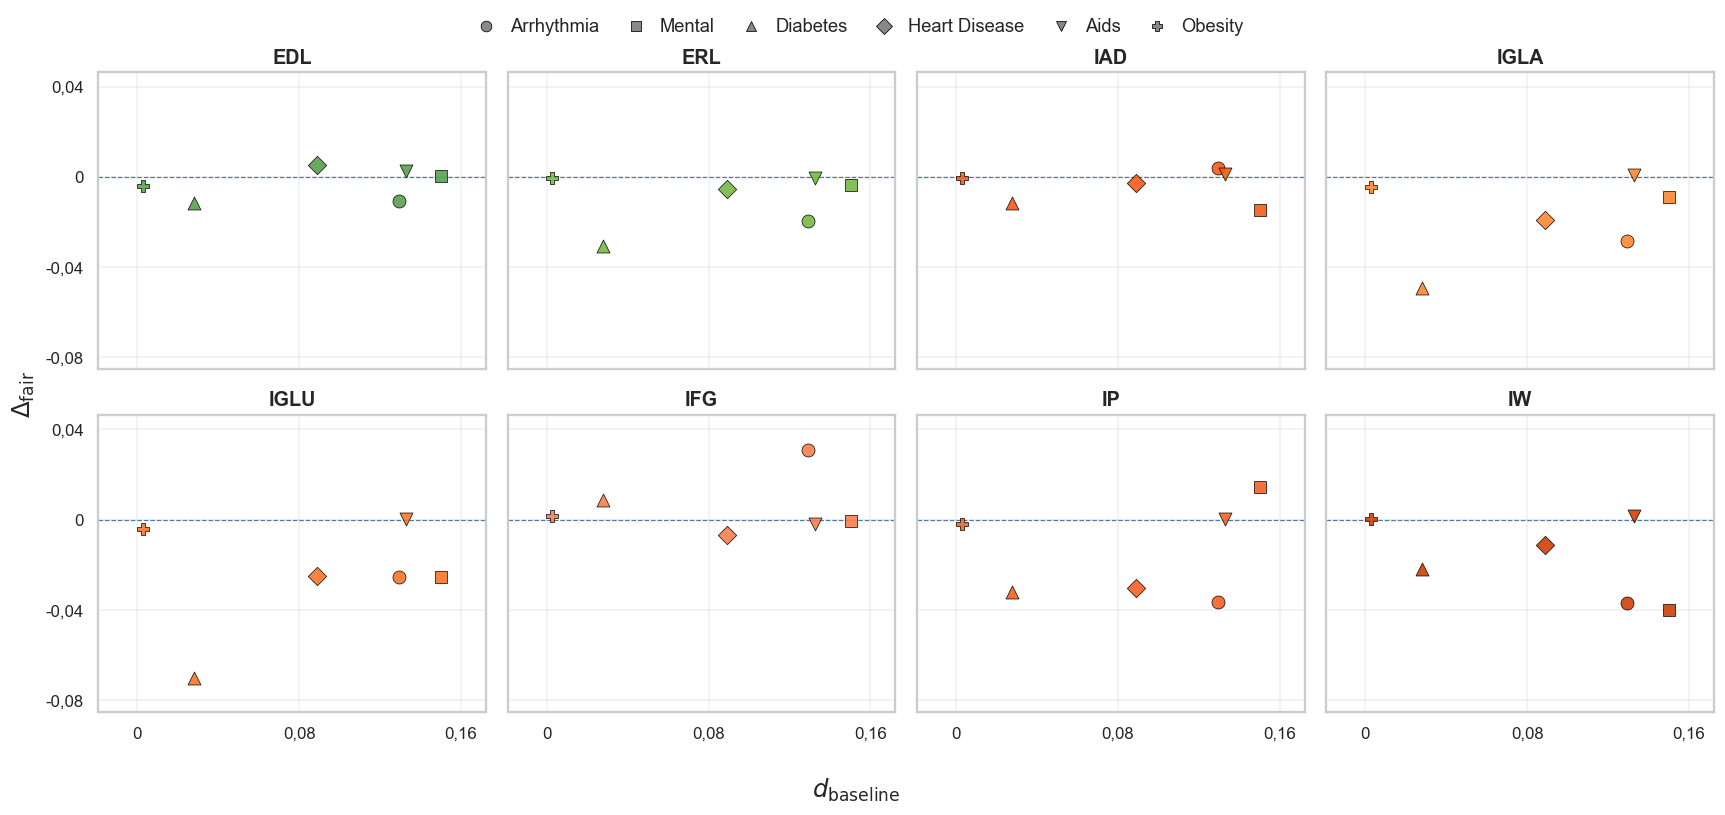

In [223]:
# RQ3 — Scatter contínuo: d_baseline (X) vs Δ_fair (Y)
# Inclui datasets inelegíveis (severity_level == 0) para visão completa
from auxiliar_analysis.rq3_utils import (
    build_intensity_scatter_data,
    plot_baseline_vs_mitigation,
    plot_baseline_vs_mitigation_by_dataset,
    plot_baseline_vs_mitigation_faceted,
)

# Reconstruir scatter COM inelegíveis para esta análise
scatter_all_full = build_intensity_scatter_data(
    df, classified,
    metrics=sorted(METRICS_PAPER),
    ideal_values=ideal_values,
    scope="all", level="method",
)

for metric in sorted(METRICS_PAPER):
    # (a) Scatter por método
    plot_baseline_vs_mitigation(
        scatter_all_full, metric,
        translate=translate,
        save_path=RQ3_FIGS / f"scatter_baseline_delta_{metric}.pdf",
    )
    # (b) Dot-plot por dataset
    plot_baseline_vs_mitigation_by_dataset(
        scatter_all_full, metric,
        translate=translate,
        save_path=RQ3_FIGS / f"dotplot_baseline_delta_{metric}.pdf",
    )
    # (c) Scatter facetado por método
    plot_baseline_vs_mitigation_faceted(
        scatter_all_full, metric,
        translate=translate,
        save_path=RQ3_FIGS / f"faceted_baseline_delta_{metric}.pdf",
    )

### 4.3 Tabelas resumo

In [224]:
# RQ3 — Bloco 3: Tabelas de correlação (Spearman/Pearson)
cols_corr = ["metric", "category", "n", "spearman_rho", "spearman_p", "pearson_r", "pearson_p"]

# Correlação por categoria
corr_cat = compute_intensity_correlation_table(
    scatter_cat, group_col="category", translate=translate,
)
display(corr_cat)

latex_and_save(
    corr_cat,
    caption="Correlação entre intensidade do viés e redução (por categoria)",
    label="tab_rq3_correlation_category",
    result_dir=RQ3_TABLES,
    translate=translate,
    cols=cols_corr,
    multirow_cols=["metric"],
    group_col="metric",
)

# Correlação por método
cols_corr_method = ["metric", "method", "n", "spearman_rho", "spearman_p", "pearson_r", "pearson_p"]

corr_method = compute_intensity_correlation_table(
    scatter_all, group_col="method", translate=translate,
)
display(corr_method)

latex_and_save(
    corr_method,
    caption="Correlação entre intensidade do viés e redução (por método)",
    label="tab_rq3_correlation_method",
    result_dir=RQ3_TABLES,
    translate=translate,
    cols=cols_corr_method,
    multirow_cols=["metric"],
    group_col="metric",
)


,metric,category,n,spearman_rho,spearman_p,pearson_r,pearson_p,interpretacao_N
0,Amplificação de viés,In-Processing,3,-0.5,0.6667,-0.9871,0.1023,N<5: cautela extrema
1,Amplificação de viés,Pre-Processing,3,-0.5,0.6667,0.1077,0.9313,N<5: cautela extrema
2,Consistência,In-Processing,5,-0.3,0.6238,0.0356,0.9546,N<10: focar em efeito
3,Consistência,Pre-Processing,5,0.4,0.5046,0.5176,0.3718,N<10: focar em efeito
4,Impacto Díspar,In-Processing,5,0.1,0.8729,-0.4881,0.4042,N<10: focar em efeito
5,Impacto Díspar,Pre-Processing,5,0.3,0.6238,0.1672,0.7881,N<10: focar em efeito
6,Diferença de Taxa de Erro,In-Processing,4,0.4,0.6000,0.5096,0.4904,N<5: cautela extrema
7,Diferença de Taxa de Erro,Pre-Processing,4,-0.2,0.8000,0.2190,0.7810,N<5: cautela extrema
8,Diferença de Taxa de Falsa Descoberta,In-Processing,4,0.0,1.0000,0.1969,0.8031,N<5: cautela extrema
9,Diferença de Taxa de Falsa Descoberta,Pre-Processing,4,0.4,0.6000,0.6376,0.3624,N<5: cautela extrema


Tabela salva em: experiments\results\analysis\RQ3\tables\tab_rq3_correlation_category.tex
| metric                                | category       |   n |   spearman_rho |   spearman_p |   pearson_r |   pearson_p | interpretacao_N       |
|:--------------------------------------|:---------------|----:|---------------:|-------------:|------------:|------------:|:----------------------|
| Amplificação de viés                  | In-Processing  |   3 |           -0.5 |       0.6667 |     -0.9871 |      0.1023 | N<5: cautela extrema  |
| Amplificação de viés                  | Pre-Processing |   3 |           -0.5 |       0.6667 |      0.1077 |      0.9313 | N<5: cautela extrema  |
| Consistência                          | In-Processing  |   5 |           -0.3 |       0.6238 |      0.0356 |      0.9546 | N<10: focar em efeito |
| Consistência                          | Pre-Processing |   5 |            0.4 |       0.5046 |      0.5176 |      0.3718 | N<10: focar em efeito |
| Impacto Díspar

,metric,method,n,spearman_rho,spearman_p,pearson_r,pearson_p,interpretacao_N
0,Amplificação de viés,EDL,3,-0.5,0.6667,0.0713,0.9546,N<5: cautela extrema
1,Amplificação de viés,ERL,3,-0.5,0.6667,-0.9871,0.1023,N<5: cautela extrema
2,Amplificação de viés,IAD,3,-0.5,0.6667,0.3191,0.7933,N<5: cautela extrema
3,Amplificação de viés,IFG,3,1.0,0.0000,0.9185,0.2587,N<5: cautela extrema
4,Amplificação de viés,IGLA,3,-0.5,0.6667,-0.9871,0.1023,N<5: cautela extrema
5,Amplificação de viés,IGLU,3,-0.5,0.6667,-0.9871,0.1023,N<5: cautela extrema
6,Amplificação de viés,IP,3,-0.5,0.6667,0.0318,0.9797,N<5: cautela extrema
7,Amplificação de viés,IW,3,-0.5,0.6667,-0.9871,0.1023,N<5: cautela extrema
8,Consistência,EDL,5,0.3,0.6238,0.4454,0.4523,N<10: focar em efeito
9,Consistência,ERL,5,0.0,1.0000,0.4567,0.4395,N<10: focar em efeito


Tabela salva em: experiments\results\analysis\RQ3\tables\tab_rq3_correlation_method.tex
| metric                                | method   |   n |   spearman_rho |   spearman_p |   pearson_r |   pearson_p | interpretacao_N       |
|:--------------------------------------|:---------|----:|---------------:|-------------:|------------:|------------:|:----------------------|
| Amplificação de viés                  | EDL      |   3 |           -0.5 |       0.6667 |      0.0713 |      0.9546 | N<5: cautela extrema  |
| Amplificação de viés                  | ERL      |   3 |           -0.5 |       0.6667 |     -0.9871 |      0.1023 | N<5: cautela extrema  |
| Amplificação de viés                  | IAD      |   3 |           -0.5 |       0.6667 |      0.3191 |      0.7933 | N<5: cautela extrema  |
| Amplificação de viés                  | IFG      |   3 |            1   |       0      |      0.9185 |      0.2587 | N<5: cautela extrema  |
| Amplificação de viés                  | IGLA     |  

'\\begin{table}[H]\n\\caption{Correlação entre intensidade do viés e redução (por método)}\n\\label{tab_rq3_correlation_method}\n\\centering\n\\scriptsize\n\\begin{tabular}{lllllll}\n\\toprule\nMétrica & Método & $n$ & Spearman $\\rho$ & $p$ (Spearman) & Pearson $r$ & $p$ (Pearson) \\\\\n\\midrule\n\\multirow{8}{*}{Amplificação de viés} & EDL & 3 & -0,5000 & 0,6667 & 0,0713 & 0,9546 \\\\\n & ERL & 3 & -0,5000 & 0,6667 & -0,9871 & 0,1023 \\\\\n & IAD & 3 & -0,5000 & 0,6667 & 0,3191 & 0,7933 \\\\\n & IFG & 3 & 1,0000 & 0,0000 & 0,9185 & 0,2587 \\\\\n & IGLA & 3 & -0,5000 & 0,6667 & -0,9871 & 0,1023 \\\\\n & IGLU & 3 & -0,5000 & 0,6667 & -0,9871 & 0,1023 \\\\\n & IP & 3 & -0,5000 & 0,6667 & 0,0318 & 0,9797 \\\\\n & IW & 3 & -0,5000 & 0,6667 & -0,9871 & 0,1023 \\\\\n\\cmidrule(lr){1-7}\n\\multirow{8}{*}{Consistência} & EDL & 5 & 0,3000 & 0,6238 & 0,4454 & 0,4523 \\\\\n & ERL & 5 & 0,0000 & 1,0000 & 0,4567 & 0,4395 \\\\\n & IAD & 5 & -0,2000 & 0,7471 & 0,1111 & 0,8589 \\\\\n & IFG & 5 & -0,

In [225]:
# RQ3 — Tabelas descritivas: mediana/IQR de Δfair e r_fair por método e categoria

# ── Seleção de colunas (ajuste aqui o que incluir) ──
cols_rq3_method = ["metric", "method", "category", "median_delta_fair", "iqr_delta_fair", "median_r_fair", "iqr_r_fair"] #n, win_rate_pct
cols_rq3_cat    = ["metric", "category", "median_delta_fair", "iqr_delta_fair", "median_r_fair", "iqr_r_fair"] #n, win_rate_pct
cols_rq3_sev        = ["metric", "category", "severity_level", "n", "median_delta_fair", "iqr_delta_fair", "median_r_fair", "iqr_r_fair"]
cols_rq3_sev_method = ["metric", "method", "category", "severity_level", "n", "median_delta_fair", "iqr_delta_fair", "median_r_fair", "iqr_r_fair"]

# ── Tabela por método ──
summary_method = build_intensity_summary_table(
    scatter_all, group_col="method", translate=translate,
)

# Adicionar coluna de categoria para cada método
from auxiliar_analysis.statistic_test import EXP_TO_CATEGORY
summary_method["category"] = summary_method["method"].map(
    lambda m: translate.get(EXP_TO_CATEGORY.get(m, m), EXP_TO_CATEGORY.get(m, m))
)

display(summary_method)

latex_and_save(
    summary_method,
    caption="Resumo descritivo de mitigação por método",
    label="tab_rq3_summary_method",
    result_dir=RQ3_TABLES,
    translate=translate,
    cols=cols_rq3_method,
    multirow_cols=["metric", "category"],
    group_col=["metric", "category"],
)

# ── Tabela por categoria ──
summary_cat = build_intensity_summary_table(
    scatter_all, group_col="category", translate=translate,
)
display(summary_cat)

latex_and_save(
    summary_cat,
    caption="Resumo descritivo de mitigação por categoria de método",
    label="tab_rq3_summary_category",
    result_dir=RQ3_TABLES,
    translate=translate,
    cols=cols_rq3_cat,
    multirow_cols=["metric"],
    group_col="metric",
)

# ── Tabela por categoria × severidade (números dos gráficos de perfil) ──
summary_sev = build_intensity_summary_table(
    scatter_cat, group_col="category", translate=translate, by_severity=True,
)
display(summary_sev)

latex_and_save(
    summary_sev,
    caption="Resumo descritivo de mitigação por categoria e nível de severidade",
    label="tab_rq3_summary_severity",
    result_dir=RQ3_TABLES,
    translate=translate,
    cols=cols_rq3_sev,
    multirow_cols=["metric", "category"],
    group_col=["metric", "category"],
)

# ── Tabela por método × severidade ──
summary_sev_method = build_intensity_summary_table(
    scatter_all, group_col="method", translate=translate, by_severity=True,
)

summary_sev_method["category"] = summary_sev_method["method"].map(
    lambda m: translate.get(EXP_TO_CATEGORY.get(m, m), EXP_TO_CATEGORY.get(m, m))
)

display(summary_sev_method)

latex_and_save(
    summary_sev_method,
    caption="Resumo descritivo de mitigação por método e nível de severidade",
    label="tab_rq3_summary_severity_method",
    result_dir=RQ3_TABLES,
    translate=translate,
    cols=cols_rq3_sev_method,
    multirow_cols=["metric", "category", "method"],
    group_col=["metric", "category"],
)


,metric,method,n,median_gap_baseline,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair,win_rate_pct,category
0,Amplificação de viés,EDL,3,0.1113,0.0397,0.1384,0.1394,1.4565,66.7,Pre-Processing
1,Amplificação de viés,ERL,3,0.1113,0.1113,0.1655,1.0000,0.0955,100.0,Pre-Processing
2,Amplificação de viés,IAD,3,0.1113,0.0397,0.4285,0.7591,2.7869,66.7,In-Processing
3,Amplificação de viés,IFG,3,0.1113,0.0074,0.1860,0.0663,0.7381,66.7,In-Processing
4,Amplificação de viés,IGLA,3,0.1113,0.0397,0.0537,1.0000,0.4956,100.0,In-Processing
5,Amplificação de viés,IGLU,3,0.1113,0.0397,0.0362,1.0000,0.4576,100.0,In-Processing
6,Amplificação de viés,IP,3,0.1113,0.0397,0.1500,0.6156,0.5803,66.7,In-Processing
7,Amplificação de viés,IW,3,0.1113,0.1113,0.2035,1.0000,0.0125,100.0,In-Processing
8,Consistência,EDL,5,0.1162,0.0081,0.0026,0.0783,0.0242,100.0,Pre-Processing
9,Consistência,ERL,5,0.1162,-0.0848,0.0540,-0.3685,0.5831,0.0,Pre-Processing


Tabela salva em: experiments\results\analysis\RQ3\tables\tab_rq3_summary_method.tex
| metric                                | method   |   n |   median_gap_baseline |   median_delta_fair |   iqr_delta_fair |   median_r_fair |   iqr_r_fair |   win_rate_pct | category       |
|:--------------------------------------|:---------|----:|----------------------:|--------------------:|-----------------:|----------------:|-------------:|---------------:|:---------------|
| Amplificação de viés                  | EDL      |   3 |                0.1113 |              0.0397 |           0.1384 |          0.1394 |       1.4565 |           66.7 | Pre-Processing |
| Amplificação de viés                  | ERL      |   3 |                0.1113 |              0.1113 |           0.1655 |          1      |       0.0955 |          100   | Pre-Processing |
| Amplificação de viés                  | IAD      |   3 |                0.1113 |              0.0397 |           0.4285 |          0.7591 |       2.78

,metric,category,n,median_gap_baseline,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair,win_rate_pct
0,Amplificação de viés,In-Processing,18,0.1113,0.0397,0.0961,0.8670,0.9291,83.3
1,Amplificação de viés,Pre-Processing,6,0.1113,0.0518,0.0598,0.9045,0.6932,83.3
2,Consistência,In-Processing,30,0.1162,-0.0076,0.0267,-0.0436,0.1701,40.0
3,Consistência,Pre-Processing,10,0.1162,-0.0008,0.0815,-0.0244,0.3863,50.0
4,Impacto Díspar,In-Processing,30,0.5454,0.2619,0.3284,0.5346,0.5526,86.7
5,Impacto Díspar,Pre-Processing,10,0.5454,0.1358,0.3003,0.2247,0.5021,70.0
6,Diferença de Taxa de Erro,In-Processing,24,0.0394,0.0016,0.0197,0.0444,0.4315,58.3
7,Diferença de Taxa de Erro,Pre-Processing,8,0.0394,0.0013,0.0141,0.0493,0.3414,62.5
8,Diferença de Taxa de Falsa Descoberta,In-Processing,24,0.1187,-0.0498,0.1181,-0.4675,0.8173,20.8
9,Diferença de Taxa de Falsa Descoberta,Pre-Processing,8,0.1187,-0.0402,0.0456,-0.4178,0.4274,25.0


Tabela salva em: experiments\results\analysis\RQ3\tables\tab_rq3_summary_category.tex
| metric                                | category       |   n |   median_gap_baseline |   median_delta_fair |   iqr_delta_fair |   median_r_fair |   iqr_r_fair |   win_rate_pct |
|:--------------------------------------|:---------------|----:|----------------------:|--------------------:|-----------------:|----------------:|-------------:|---------------:|
| Amplificação de viés                  | In-Processing  |  18 |                0.1113 |              0.0397 |           0.0961 |          0.867  |       0.9291 |           83.3 |
| Amplificação de viés                  | Pre-Processing |   6 |                0.1113 |              0.0518 |           0.0598 |          0.9045 |       0.6932 |           83.3 |
| Consistência                          | In-Processing  |  30 |                0.1162 |             -0.0076 |           0.0267 |         -0.0436 |       0.1701 |           40   |
| Consistência

,metric,category,severity_level,n,median_gap_baseline,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair,win_rate_pct
0,Amplificação de viés,In-Processing,Alto,1,0.4583,0.2457,0.0000,0.5362,0.0000,100.0
1,Amplificação de viés,In-Processing,Médio,1,0.0397,0.0397,0.0000,1.0000,0.0000,100.0
2,Amplificação de viés,In-Processing,Baixo,1,0.1113,0.1113,0.0000,1.0000,0.0000,100.0
3,Amplificação de viés,Pre-Processing,Alto,1,0.4583,0.2295,0.0000,0.5009,0.0000,100.0
4,Amplificação de viés,Pre-Processing,Médio,1,0.0397,0.0333,0.0000,0.8402,0.0000,100.0
5,Amplificação de viés,Pre-Processing,Baixo,1,0.1113,-0.0508,0.0000,-0.4565,0.0000,0.0
6,Consistência,In-Processing,Alto,2,0.2654,-0.0082,0.0097,-0.0296,0.0355,50.0
7,Consistência,In-Processing,Médio,1,0.1162,-0.0187,0.0000,-0.1609,0.0000,0.0
8,Consistência,In-Processing,Baixo,2,0.0948,0.0011,0.0057,0.0087,0.0602,50.0
9,Consistência,Pre-Processing,Alto,2,0.2654,-0.0132,0.0291,-0.0535,0.1114,50.0


Tabela salva em: experiments\results\analysis\RQ3\tables\tab_rq3_summary_severity.tex
| metric                                | category       | severity_level   |   n |   median_gap_baseline |   median_delta_fair |   iqr_delta_fair |   median_r_fair |   iqr_r_fair |   win_rate_pct |
|:--------------------------------------|:---------------|:-----------------|----:|----------------------:|--------------------:|-----------------:|----------------:|-------------:|---------------:|
| Amplificação de viés                  | In-Processing  | Alto             |   1 |                0.4583 |              0.2457 |           0      |          0.5362 |       0      |          100   |
| Amplificação de viés                  | In-Processing  | Médio            |   1 |                0.0397 |              0.0397 |           0      |          1      |       0      |          100   |
| Amplificação de viés                  | In-Processing  | Baixo            |   1 |                0.1113 |           

,metric,method,severity_level,n,median_gap_baseline,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair,win_rate_pct,category
0,Amplificação de viés,EDL,Alto,1,0.4583,0.0639,0.0000,0.1394,0.0000,100.0,Pre-Processing
1,Amplificação de viés,EDL,Médio,1,0.0397,0.0397,0.0000,1.0000,0.0000,100.0,Pre-Processing
2,Amplificação de viés,EDL,Baixo,1,0.1113,-0.2129,0.0000,-1.9131,0.0000,0.0,Pre-Processing
3,Amplificação de viés,ERL,Alto,1,0.4583,0.3707,0.0000,0.8090,0.0000,100.0,Pre-Processing
4,Amplificação de viés,ERL,Médio,1,0.0397,0.0397,0.0000,1.0000,0.0000,100.0,Pre-Processing
...,...,...,...,...,...,...,...,...,...,...,...
123,Índice de Entropia Generalizada,IGLU,Médio,3,0.1293,-0.0250,0.0128,-0.1966,0.1410,33.3,In-Processing
124,Índice de Entropia Generalizada,IP,Alto,1,0.1502,0.0144,0.0000,0.0959,0.0000,100.0,In-Processing
125,Índice de Entropia Generalizada,IP,Médio,3,0.1293,-0.0303,0.0183,-0.2828,0.1708,33.3,In-Processing
126,Índice de Entropia Generalizada,IW,Alto,1,0.1502,-0.0401,0.0000,-0.2672,0.0000,0.0,In-Processing


Tabela salva em: experiments\results\analysis\RQ3\tables\tab_rq3_summary_severity_method.tex
| metric                                | method   | severity_level   |   n |   median_gap_baseline |   median_delta_fair |   iqr_delta_fair |   median_r_fair |   iqr_r_fair |   win_rate_pct | category       |
|:--------------------------------------|:---------|:-----------------|----:|----------------------:|--------------------:|-----------------:|----------------:|-------------:|---------------:|:---------------|
| Amplificação de viés                  | EDL      | Alto             |   1 |                0.4583 |              0.0639 |           0      |          0.1394 |       0      |          100   | Pre-Processing |
| Amplificação de viés                  | EDL      | Médio            |   1 |                0.0397 |              0.0397 |           0      |          1      |       0      |          100   | Pre-Processing |
| Amplificação de viés                  | EDL      | Baixo         

'\\begin{table}[H]\n\\caption{Resumo descritivo de mitigação por método e nível de severidade}\n\\label{tab_rq3_summary_severity_method}\n\\centering\n\\scriptsize\n\\begin{tabular}{lllllllll}\n\\toprule\nMétrica & Método & Categoria & Severidade & $n$ & Mediana $\\Delta_{\\text{fair}}$ & IQR($\\Delta_{\\text{fair}}$) & Mediana $r_{\\text{fair}}$ & IQR($r_{\\text{fair}}$) \\\\\n\\midrule\n\\multirow{24}{*}{Amplificação de viés} & \\multirow{3}{*}{EDL} & \\multirow{6}{*}{Pre-Processing} & Alto & 1 & 0,0639 & 0,0000 & 0,1394 & 0,0000 \\\\\n &  &  & Médio & 1 & 0,0397 & 0,0000 & 1,0000 & 0,0000 \\\\\n &  &  & Baixo & 1 & -0,2129 & 0,0000 & -1,9131 & 0,0000 \\\\\n & \\multirow{3}{*}{ERL} &  & Alto & 1 & 0,3707 & 0,0000 & 0,8090 & 0,0000 \\\\\n &  &  & Médio & 1 & 0,0397 & 0,0000 & 1,0000 & 0,0000 \\\\\n &  &  & Baixo & 1 & 0,1113 & 0,0000 & 1,0000 & 0,0000 \\\\\n\\cmidrule(lr){2-9}\n & \\multirow{3}{*}{IAD} & \\multirow{18}{*}{In-Processing} & Alto & 1 & 0,3479 & 0,0000 & 0,7591 & 0,0000 \

In [226]:
from auxiliar_analysis.rq3_utils import build_baseline_delta_latex_table


for metric in ["disparate_impact",
    "bias_amplification",
    "consistency",
    "generalized_entropy_index",
    "false_discovery_rate_difference",
    "false_negative_rate_difference",
    "error_rate_difference",]:
    build_baseline_delta_latex_table(
        scatter_all_full, metric, translate, result_dir=RQ3_TABLES,
    )

## 5) RQ4 — O sentido do viés altera a mitigação?

**Objetivo:** Investigar se a direção do viés no baseline (U = contra não-privilegiado,
P = contra privilegiado) influencia a eficácia das estratégias de mitigação.

- O rótulo U/P é propriedade do **(dataset × métrica)** no baseline, derivado de δ(m).
- Uma vez classificado U ou P, mantém-se para todos os métodos.
- Categorias A e C possuem direção interpretável; categoria B é excluída desta análise.

### 5.0 Verificação de discordância de direção

Antes de analisar sentido, verificar se há datasets com métricas direcionais
elegíveis apontando direções opostas (U vs P) na mesma categoria.

In [227]:
# RQ4 — Pré-requisito: verificar discordância de own_direction
from auxiliar_analysis.bias_pattern_classifier import check_direction_discordance

discord = check_direction_discordance(classified)
if discord.empty:
    print("Nenhuma discordância de direção encontrada. "
          "Herança de direção por categoria é consistente.")
else:
    print(f"ATENÇÃO: {len(discord)} casos de discordância encontrados:")
    display(discord)
    print("Direção herdada pode precisar de ressalva para esses datasets.")

ATENÇÃO: 8 casos de discordância encontrados:


,dataset,category,metric,own_direction
0,11_arrhythmia,C,error_rate_difference,P
1,11_arrhythmia,C,false_discovery_rate_difference,U
2,11_arrhythmia,C,false_negative_rate_difference,U
3,4_heart_disease,C,error_rate_difference,P
4,4_heart_disease,C,false_discovery_rate_difference,U
5,6_aids,C,error_rate_difference,U
6,6_aids,C,false_discovery_rate_difference,P
7,6_aids,C,false_negative_rate_difference,P


Direção herdada pode precisar de ressalva para esses datasets.


### 5.1 Cobertura e distribuição U/P por categoria

In [228]:
# === Controle de fontes — RQ4 ===
from auxiliar_analysis import rq4_utils

rq4_utils._VIZ.update({
    "title_fontsize": 16,
    "subtitle_fontsize": 12,
    "label_fontsize": 17,
    "tick_fontsize": 15,
    "legend_fontsize": 13,
    "annotation_fontsize": 12,
    "suptitle_fontsize": 14,
    "colorbar_label_fontsize": 12,
    "paired_legend_fontsize": 10,
})

In [229]:
# RQ4 — Bloco 1: Tabela de cobertura e distribuição U/P
from auxiliar_analysis.rq4_utils import build_direction_coverage_table

direction_coverage = build_direction_coverage_table(
    classified,
    categories=["A", "C"],
    translate=translate,
)

display(direction_coverage)

latex_and_save(
    direction_coverage,
    caption="Distribuição de datasets por direção do viés (U/P) e categoria de padrão",
    label="tab_rq4_direction_coverage",
    result_dir=RQ4_TABLES,
    translate=translate,
)


,Categoria,Métrica,Total,U (não-priv.),P (priv.),Sem direção,Inelegível
0,A,Amplificação de viés,6,2,3,0,1
1,A,Impacto Díspar,6,2,3,0,1
2,A,— Total A —,6,2,3,0,1
3,C,Diferença de Taxa de Erro,6,1,3,0,2
4,C,Diferença de Taxa de Falsa Descoberta,6,1,3,0,2
5,C,Diferença de Taxa de Falsos Negativos,6,1,3,0,2
6,C,— Total C —,6,1,3,0,2


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_direction_coverage.tex
| Categoria   | Métrica                               |   Total |   U (não-priv.) |   P (priv.) |   Sem direção |   Inelegível |
|:------------|:--------------------------------------|--------:|----------------:|------------:|--------------:|-------------:|
| A           | Amplificação de viés                  |       6 |               2 |           3 |             0 |            1 |
| A           | Impacto Díspar                        |       6 |               2 |           3 |             0 |            1 |
| A           | — Total A —                           |       6 |               2 |           3 |             0 |            1 |
| C           | Diferença de Taxa de Erro             |       6 |               1 |           3 |             0 |            2 |
| C           | Diferença de Taxa de Falsa Descoberta |       6 |               1 |           3 |             0 |            2 |
| C      

'\\begin{table}[H]\n\\caption{Distribuição de conjuntos de dados por direção do viés (U/P) e categoria de padrão}\n\\label{tab_rq4_direction_coverage}\n\\centering\n\\scriptsize\n\\begin{tabular}{lllllll}\n\\toprule\nCategoria & Métrica & Total & U (não-priv.) & P (priv.) & Sem direção & Inelegível \\\\\n\\midrule\nA & Amplificação de viés & 6 & 2 & 3 & 0 & 1 \\\\\nA & Impacto Díspar & 6 & 2 & 3 & 0 & 1 \\\\\nA & — Total A — & 6 & 2 & 3 & 0 & 1 \\\\\nC & Diferença de Taxa de Erro & 6 & 1 & 3 & 0 & 2 \\\\\nC & Diferença de Taxa de Falsa Descoberta & 6 & 1 & 3 & 0 & 2 \\\\\nC & Diferença de Taxa de Falsos Negativos & 6 & 1 & 3 & 0 & 2 \\\\\nC & — Total C — & 6 & 1 & 3 & 0 & 2 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

### 5.2 Win rate por direção (U vs P)

#### 5.2.1 Win rate segmentado por categoria

In [230]:
# RQ4 — Win rate por direção — Segmentado por categoria (Padrões A + C)
from auxiliar_analysis.rq4_utils import compute_win_rate_by_direction
import pandas as pd

cols_wr_cat = ["metric_label", "category", "direction", "n", "wins", "win_rate_pct"]

# Padrão A
wr_cat_A = compute_win_rate_by_direction(
    df, classified,
    metrics=["disparate_impact", "bias_amplification"],
    category="A", ideal_values=ideal_values,
    group_col="category", translate=translate,
)

# Padrão C
wr_cat_C = compute_win_rate_by_direction(
    df, classified,
    metrics=["false_negative_rate_difference", "false_discovery_rate_difference", "error_rate_difference"],
    category="C", ideal_values=ideal_values,
    group_col="category", translate=translate,
)

# Consolidar ambos os padrões em uma única tabela
wr_cat_all = pd.concat([wr_cat_A, wr_cat_C], ignore_index=True)

# Ordenar: métrica → categoria → direção
wr_cat_all = wr_cat_all.sort_values(
    ["metric_label", "category", "direction"],
    key=lambda col: col.map(lambda x: x) if col.name != "direction" else col.map({"U": 0, "P": 1}),
).reset_index(drop=True)

display(wr_cat_all)

latex_and_save(
    wr_cat_all,
    caption="Win rate por direção do viés --- segmentado por categoria",
    label="tab_rq4_winrate_cat_direction",
    result_dir=RQ4_TABLES,
    translate=translate,
    cols=cols_wr_cat,
    multirow_cols=["metric_label", "category"],
    group_col="metric_label",
    longtable=True,
)


,metric_label,category,direction,n,wins,win_rate_pct
0,Amplificação de viés,in_processing,U,2,2,100.0
1,Amplificação de viés,in_processing,P,3,3,100.0
2,Amplificação de viés,pre_processing,U,2,1,50.0
3,Amplificação de viés,pre_processing,P,3,1,33.3
4,Diferença de Taxa de Erro,in_processing,U,1,0,0.0
5,Diferença de Taxa de Erro,in_processing,P,3,2,66.7
6,Diferença de Taxa de Erro,pre_processing,U,1,0,0.0
7,Diferença de Taxa de Erro,pre_processing,P,3,2,66.7
8,Diferença de Taxa de Falsa Descoberta,in_processing,U,1,0,0.0
9,Diferença de Taxa de Falsa Descoberta,in_processing,P,3,0,0.0


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_winrate_cat_direction.tex
| metric_label                          | category       | direction   |   n |   wins |   win_rate_pct |
|:--------------------------------------|:---------------|:------------|----:|-------:|---------------:|
| Amplificação de viés                  | in_processing  | U           |   2 |      2 |          100   |
| Amplificação de viés                  | in_processing  | P           |   3 |      3 |          100   |
| Amplificação de viés                  | pre_processing | U           |   2 |      1 |           50   |
| Amplificação de viés                  | pre_processing | P           |   3 |      1 |           33.3 |
| Diferença de Taxa de Erro             | in_processing  | U           |   1 |      0 |            0   |
| Diferença de Taxa de Erro             | in_processing  | P           |   3 |      2 |           66.7 |
| Diferença de Taxa de Erro             | pre_processing | U         

'{\\scriptsize\n\\begin{longtable}{llllll}\n\\caption{Win rate por direção do viés --- segmentado por categoria}\n\\label{tab_rq4_winrate_cat_direction} \\\\\n\\toprule\nMétrica & Categoria & Sentido & $n$ & Vitórias & Win rate (\\\\%) \\\\\n\\midrule\n\\endfirsthead\n\n\\multicolumn{6}{c}{{\\tablename\\ \\thetable{} -- continuação}} \\\\\n\\toprule\nMétrica & Categoria & Sentido & $n$ & Vitórias & Win rate (\\\\%) \\\\\n\\midrule\n\\endhead\n\n\\midrule\n\\multicolumn{6}{r}{{Continua na próxima página}} \\\\\n\\endfoot\n\n\\bottomrule\n\\endlastfoot\n\n\\multirow{4}{*}{Amplificação de viés} & \\multirow{2}{*}{In-Processing} & U & 2 & 2 & 100,0000 \\\\\n &  & P & 3 & 3 & 100,0000 \\\\\n & \\multirow{2}{*}{Pre-Processing} & U & 2 & 1 & 50,0000 \\\\\n &  & P & 3 & 1 & 33,3000 \\\\\n\\cmidrule(lr){1-6}\n\\multirow{4}{*}{Diferença de Taxa de Erro} & \\multirow{2}{*}{In-Processing} & U & 1 & 0 & 0,0000 \\\\\n &  & P & 3 & 2 & 66,7000 \\\\\n & \\multirow{2}{*}{Pre-Processing} & U & 1 & 0 & 0

#### 5.2.2 Win rate segmentado por método

In [231]:
# RQ4 — Win rate por direção — Segmentado por método (Padrões A + C)
cols_wr_meth = ["metric_label", "method", "direction", "n", "wins", "win_rate_pct"]

# Padrão A
wr_meth_A = compute_win_rate_by_direction(
    df, classified,
    metrics=["disparate_impact", "bias_amplification"],
    category="A", ideal_values=ideal_values,
    group_col="method", translate=translate,
)

# Padrão C
wr_meth_C = compute_win_rate_by_direction(
    df, classified,
    metrics=["false_negative_rate_difference", "false_discovery_rate_difference", "error_rate_difference"],
    category="C", ideal_values=ideal_values,
    group_col="method", translate=translate,
)

# Consolidar ambos os padrões em uma única tabela
wr_meth_all = pd.concat([wr_meth_A, wr_meth_C], ignore_index=True)

# Ordenar: métrica → método → direção
wr_meth_all = wr_meth_all.sort_values(
    ["metric_label", "method", "direction"],
    key=lambda col: col.map(lambda x: x) if col.name != "direction" else col.map({"U": 0, "P": 1}),
).reset_index(drop=True)

display(wr_meth_all)

latex_and_save(
    wr_meth_all,
    caption="Win rate por direção do viés --- segmentado por método",
    label="tab_rq4_winrate_method_direction",
    result_dir=RQ4_TABLES,
    translate=translate,
    cols=cols_wr_meth,
    multirow_cols=["metric_label"],
    group_col="metric_label",
    longtable=True,
)


,metric_label,method,direction,n,wins,win_rate_pct
0,Amplificação de viés,EDL,U,2,1,50.0
1,Amplificação de viés,EDL,P,3,1,33.3
2,Amplificação de viés,ERL,U,2,2,100.0
3,Amplificação de viés,ERL,P,3,3,100.0
4,Amplificação de viés,IAD,U,2,2,100.0
...,...,...,...,...,...,...
75,Impacto Díspar,IGLU,P,3,3,100.0
76,Impacto Díspar,IP,U,2,2,100.0
77,Impacto Díspar,IP,P,3,3,100.0
78,Impacto Díspar,IW,U,2,2,100.0


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_winrate_method_direction.tex
| metric_label                          | method   | direction   |   n |   wins |   win_rate_pct |
|:--------------------------------------|:---------|:------------|----:|-------:|---------------:|
| Amplificação de viés                  | EDL      | U           |   2 |      1 |           50   |
| Amplificação de viés                  | EDL      | P           |   3 |      1 |           33.3 |
| Amplificação de viés                  | ERL      | U           |   2 |      2 |          100   |
| Amplificação de viés                  | ERL      | P           |   3 |      3 |          100   |
| Amplificação de viés                  | IAD      | U           |   2 |      2 |          100   |
| Amplificação de viés                  | IAD      | P           |   3 |      2 |           66.7 |
| Amplificação de viés                  | IFG      | U           |   2 |      1 |           50   |
| Amplificação 

'{\\scriptsize\n\\begin{longtable}{llllll}\n\\caption{Win rate por direção do viés --- segmentado por método}\n\\label{tab_rq4_winrate_method_direction} \\\\\n\\toprule\nMétrica & Método & Sentido & $n$ & Vitórias & Win rate (\\\\%) \\\\\n\\midrule\n\\endfirsthead\n\n\\multicolumn{6}{c}{{\\tablename\\ \\thetable{} -- continuação}} \\\\\n\\toprule\nMétrica & Método & Sentido & $n$ & Vitórias & Win rate (\\\\%) \\\\\n\\midrule\n\\endhead\n\n\\midrule\n\\multicolumn{6}{r}{{Continua na próxima página}} \\\\\n\\endfoot\n\n\\bottomrule\n\\endlastfoot\n\n\\multirow{16}{*}{Amplificação de viés} & EDL & U & 2 & 1 & 50,0000 \\\\\n & EDL & P & 3 & 1 & 33,3000 \\\\\n & ERL & U & 2 & 2 & 100,0000 \\\\\n & ERL & P & 3 & 3 & 100,0000 \\\\\n & IAD & U & 2 & 2 & 100,0000 \\\\\n & IAD & P & 3 & 2 & 66,7000 \\\\\n & IFG & U & 2 & 1 & 50,0000 \\\\\n & IFG & P & 3 & 2 & 66,7000 \\\\\n & IGLA & U & 2 & 2 & 100,0000 \\\\\n & IGLA & P & 3 & 3 & 100,0000 \\\\\n & IGLU & U & 2 & 2 & 100,0000 \\\\\n & IGLU & P &

### 5.3 Resumo descritivo por direção

Tabelas descritivas (mediana + IQR) separadas por direção do viés (U vs P)
dentro de cada padrão. Devido à baixa volumetria (poucos datasets por direção),
não são aplicados testes estatísticos de Friedman/Holm nesta seção.


In [232]:
from auxiliar_analysis.rq4_utils import run_stats_by_direction

#### 5.3.1 Padrão A — por categoria (U vs P)

In [233]:
# RQ4 — Resumo descritivo por CATEGORIA — Padrão A (U vs P)
stats_dir_cat_A = run_stats_by_direction(
    df, classified,
    metrics=["disparate_impact", "bias_amplification"],
    category="A",
    ideal_values=ideal_values,
    analysis_type="category",
    save_dir=RQ4_TABLES,
    translate=translate,
    cols=cols_desc_cat,
)

for direction in stats_dir_cat_A["direction"].unique():
    sub = stats_dir_cat_A[stats_dir_cat_A["direction"] == direction]
    # Filtrar apenas linhas descritivas (friedman/wilcoxon) — evita NaN
    sub = sub[sub["test"].isin(["friedman", "wilcoxon"])]
    n_ds = sub["n"].iloc[0] if not sub.empty else 0
    print(f"\n{'='*60}")
    print(f"  Direção {direction} (n={int(n_ds)} datasets) — Padrão A por Categoria")
    print(f"{'='*60}")
    display(sub[[c for c in cols_desc_cat if c in sub.columns]])



  Direção U (n=2 datasets) — Padrão A por Categoria


,metric,category,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair
0,disparate_impact,baseline_typical,0.000000,0.000000,0.000000,0.000000e+00
1,disparate_impact,pre_processing,0.085609,0.070029,0.207650,1.785122e-01
2,disparate_impact,in_processing,0.215270,0.028728,0.459574,3.266075e-03
5,bias_amplification,baseline_typical,0.000000,0.000000,0.000000,0.000000e+00
6,bias_amplification,pre_processing,0.003318,0.030030,0.112684,7.274936e-01
7,bias_amplification,in_processing,0.041569,0.001877,1.000000,1.088680e-08



  Direção P (n=3 datasets) — Padrão A por Categoria


,metric,category,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair
10,disparate_impact,baseline_typical,0.000000,0.000000,0.000000,0.000000
11,disparate_impact,pre_processing,0.074126,0.219511,0.075012,0.224585
12,disparate_impact,in_processing,0.355129,0.091259,0.477932,0.095619
15,bias_amplification,baseline_typical,0.000000,0.000000,0.000000,0.000000
16,bias_amplification,pre_processing,-0.022058,0.140170,-0.284728,0.478704
17,bias_amplification,in_processing,0.111302,0.084129,1.000000,0.231887


#### 5.3.2 Padrão A — por método (U vs P)


In [234]:
# RQ4 — Resumo descritivo por MÉTODO — Padrão A (U vs P)
stats_dir_exp_A = run_stats_by_direction(
    df, classified,
    metrics=["disparate_impact", "bias_amplification"],
    category="A",
    ideal_values=ideal_values,
    analysis_type="experiment",
    save_dir=RQ4_TABLES,
    translate=translate,
    cols=cols_desc_exp,
)

for direction in stats_dir_exp_A["direction"].unique():
    sub = stats_dir_exp_A[stats_dir_exp_A["direction"] == direction]
    sub = sub[sub["test"].isin(["friedman", "wilcoxon"])]
    n_ds = sub["n"].iloc[0] if not sub.empty else 0
    print(f"\n{'='*60}")
    print(f"  Direção {direction} (n={int(n_ds)} datasets) — Padrão A por Método")
    print(f"{'='*60}")
    display(sub[[c for c in cols_desc_exp if c in sub.columns]])



  Direção U (n=2 datasets) — Padrão A por Método


,metric,method,category,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair
0,disparate_impact,baseline_typical,baseline,0.000000,0.000000,0.000000,0.000000e+00
1,disparate_impact,EDL,pre_processing,0.062320,0.139199,0.178112,3.218861e-01
2,disparate_impact,ERL,pre_processing,0.101345,0.015327,0.225173,6.430900e-02
3,disparate_impact,IAD,in_processing,0.053990,0.019323,0.111560,2.554532e-02
4,disparate_impact,IGLA,in_processing,0.344762,0.007864,0.747676,8.821987e-02
5,disparate_impact,IGLU,in_processing,0.307288,0.027986,0.659998,3.299308e-02
6,disparate_impact,IFG,in_processing,-0.008810,0.017757,-0.024592,4.132541e-02
7,disparate_impact,IP,in_processing,0.267854,0.023351,0.575619,3.102764e-02
8,disparate_impact,IW,in_processing,0.191771,0.040868,0.404740,3.032510e-02
17,bias_amplification,baseline_typical,baseline,0.000000,0.000000,0.000000,0.000000e+00



  Direção P (n=3 datasets) — Padrão A por Método


,metric,method,category,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair
34,disparate_impact,baseline_typical,baseline,0.000000,0.000000,0.000000,0.000000
35,disparate_impact,EDL,pre_processing,-0.122647,0.229442,-0.124113,0.355317
36,disparate_impact,ERL,pre_processing,0.306764,0.183914,0.562408,0.178885
37,disparate_impact,IAD,in_processing,0.196913,0.658252,0.199268,0.919745
38,disparate_impact,IGLA,in_processing,0.371734,0.247483,0.566307,0.308765
39,disparate_impact,IGLU,in_processing,0.383266,0.182292,0.545909,0.264785
40,disparate_impact,IFG,in_processing,-0.007177,0.347759,-0.013159,0.345153
41,disparate_impact,IP,in_processing,0.530058,0.209776,0.524659,0.133168
42,disparate_impact,IW,in_processing,0.408413,0.363541,0.748767,0.359007
51,bias_amplification,baseline_typical,baseline,0.000000,0.000000,0.000000,0.000000


#### 5.3.3 Padrão C — por categoria (U vs P)

In [235]:
# RQ4 — Resumo descritivo por CATEGORIA — Padrão C (U vs P)
metrics_C_rq3 = ["false_negative_rate_difference", "false_discovery_rate_difference", "error_rate_difference"]

stats_dir_cat_C = run_stats_by_direction(
    df, classified,
    metrics=metrics_C_rq3,
    category="C",
    ideal_values=ideal_values,
    analysis_type="category",
    save_dir=RQ4_TABLES,
    translate=translate,
    cols=cols_desc_cat,
)

if stats_dir_cat_C.empty:
    print("Sem dados suficientes — Padrão C por direção.")
else:
    for direction in stats_dir_cat_C["direction"].unique():
        sub = stats_dir_cat_C[stats_dir_cat_C["direction"] == direction]
        sub = sub[sub["test"].isin(["friedman", "wilcoxon"])]
        n_ds = sub["n"].iloc[0] if not sub.empty else 0
        print(f"\n{'='*60}")
        print(f"  Direção {direction} (n={int(n_ds)} datasets) — Padrão C por Categoria")
        print(f"{'='*60}")
        display(sub[[c for c in cols_desc_cat if c in sub.columns]])


d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:693: UserWarning: Teste requer pelo menos 2 datasets com dados completos. Encontrados: 1 (de 1 totais). Datasets removidos: []
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:693: UserWarning: Teste requer pelo menos 2 datasets com dados completos. Encontrados: 1 (de 1 totais). Datasets removidos: []
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:693: UserWarning: Teste requer pelo menos 2 datasets com dados completos. Encontrados: 1 (de 1 totais). Datasets removidos: []
  warnings.warn(



  Direção P (n=3 datasets) — Padrão C por Categoria


,metric,category,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair
0,false_negative_rate_difference,baseline_typical,0.000000,0.000000,0.000000,0.000000
1,false_negative_rate_difference,pre_processing,0.016169,0.005675,0.100882,0.031035
2,false_negative_rate_difference,in_processing,0.052844,0.043300,0.345185,0.341991
5,false_discovery_rate_difference,baseline_typical,0.000000,0.000000,0.000000,0.000000
6,false_discovery_rate_difference,pre_processing,-0.013808,0.021363,-0.129366,0.315161
7,false_discovery_rate_difference,in_processing,-0.043541,0.088749,-0.632052,0.849459
10,error_rate_difference,baseline_typical,0.000000,0.000000,0.000000,0.000000
11,error_rate_difference,pre_processing,0.006272,0.005693,0.099424,0.170143
12,error_rate_difference,in_processing,0.003032,0.014472,0.129601,0.216751


#### 5.3.4 Padrão C — por método (U vs P)

In [236]:
# RQ4 — Resumo descritivo por MÉTODO — Padrão C (U vs P)
stats_dir_exp_C = run_stats_by_direction(
    df, classified,
    metrics=metrics_C_rq3,
    category="C",
    ideal_values=ideal_values,
    analysis_type="experiment",
    save_dir=RQ4_TABLES,
    translate=translate,
    cols=cols_desc_exp,
)

if stats_dir_exp_C.empty:
    print("Sem dados suficientes — Padrão C por direção (método).")
else:
    for direction in stats_dir_exp_C["direction"].unique():
        sub = stats_dir_exp_C[stats_dir_exp_C["direction"] == direction]
        sub = sub[sub["test"].isin(["friedman", "wilcoxon"])]
        n_ds = sub["n"].iloc[0] if not sub.empty else 0
        print(f"\n{'='*60}")
        print(f"  Direção {direction} (n={int(n_ds)} datasets) — Padrão C por Método")
        print(f"{'='*60}")
        display(sub[[c for c in cols_desc_exp if c in sub.columns]])


d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:693: UserWarning: Teste requer pelo menos 2 datasets com dados completos. Encontrados: 1 (de 1 totais). Datasets removidos: []
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:693: UserWarning: Teste requer pelo menos 2 datasets com dados completos. Encontrados: 1 (de 1 totais). Datasets removidos: []
  warnings.warn(
d:\UFRGS\Mestrado\fairnes_treatment\auxiliar_analysis\statistic_test.py:693: UserWarning: Teste requer pelo menos 2 datasets com dados completos. Encontrados: 1 (de 1 totais). Datasets removidos: []
  warnings.warn(



  Direção P (n=3 datasets) — Padrão C por Método


,metric,method,category,median_delta_fair,iqr_delta_fair,median_r_fair,iqr_r_fair
0,false_negative_rate_difference,baseline_typical,baseline,0.000000,0.000000,0.000000,0.000000
1,false_negative_rate_difference,EDL,pre_processing,-0.030745,0.043025,-0.215369,0.285012
2,false_negative_rate_difference,ERL,pre_processing,0.068259,0.054111,0.478162,0.326593
3,false_negative_rate_difference,IAD,in_processing,-0.010135,0.129494,-0.101695,0.833489
4,false_negative_rate_difference,IGLA,in_processing,-0.005672,0.066451,-0.039735,0.501134
5,false_negative_rate_difference,IGLU,in_processing,0.011237,0.083544,0.078714,0.649449
6,false_negative_rate_difference,IFG,in_processing,0.015716,0.016888,0.152417,0.116339
7,false_negative_rate_difference,IP,in_processing,0.069821,0.065672,0.489105,0.496275
8,false_negative_rate_difference,IW,in_processing,0.060803,0.038723,0.425933,0.230582
17,false_discovery_rate_difference,baseline_typical,baseline,0.000000,0.000000,0.000000,0.000000


### 5.4 Comparação por método — U vs P

Para cada método individual, comparamos a mediana de Δfairness e o win rate
obtidos em datasets com viés U vs P. Isso permite identificar se algum método
é particularmente mais eficaz para uma direção específica.

In [237]:
from auxiliar_analysis.rq4_utils import (
    build_method_direction_comparison,
    plot_method_direction_paired,
)


In [238]:
# === Controle de fontes — RQ4 ===
from auxiliar_analysis import rq4_utils

rq4_utils._VIZ.update({
    "title_fontsize": 18,
    "subtitle_fontsize": 10,
    "label_fontsize": 14,
    "tick_fontsize": 16,
    "legend_fontsize": 16,
    "annotation_fontsize": 14,
    "suptitle_fontsize": 12,
    "colorbar_label_fontsize": 12,
    "paired_legend_fontsize": 12,
})


#### 5.4.1 Padrão A — tabela comparativa por método (U vs P)

In [239]:
# RQ4 — Bloco 5: Comparação por método — Padrão A (U vs P)
comp_A = build_method_direction_comparison(
    df, classified,
    metrics=["disparate_impact", "bias_amplification"],
    category="A",
    ideal_values=ideal_values,
    translate=translate,
)

print("=== Comparação método × direção — Padrão A ===")
print("Colunas U: datasets com viés contra não-privilegiado")
print("Colunas P: datasets com viés contra privilegiado")
print("diff_median = median_P − median_U (positivo = melhor em P)\n")
display(comp_A)

=== Comparação método × direção — Padrão A ===
Colunas U: datasets com viés contra não-privilegiado
Colunas P: datasets com viés contra privilegiado
diff_median = median_P − median_U (positivo = melhor em P)



,metric,metric_label,method,category,n_U,median_U,iqr_U,wr_U,n_P,median_P,iqr_P,wr_P,diff_median
0,bias_amplification,Amplificação de viés,EDL,pre_processing,2,-0.0286,0.0683,50.0,3,-0.1216,0.1384,33.3,-0.0930
1,bias_amplification,Amplificação de viés,ERL,pre_processing,2,0.0416,0.0019,100.0,3,0.1113,0.1466,100.0,0.0697
2,bias_amplification,Amplificação de viés,IAD,in_processing,2,0.0416,0.0019,100.0,3,0.0775,0.4285,66.7,0.0359
3,bias_amplification,Amplificação de viés,IGLA,in_processing,2,0.0416,0.0019,100.0,3,0.0775,0.0537,100.0,0.0359
4,bias_amplification,Amplificação de viés,IGLU,in_processing,2,0.0416,0.0019,100.0,3,0.0775,0.0362,100.0,0.0359
5,bias_amplification,Amplificação de viés,IFG,in_processing,2,0.0073,0.0362,50.0,3,0.0074,0.1760,66.7,0.0001
6,bias_amplification,Amplificação de viés,IP,in_processing,2,0.0416,0.0019,100.0,3,-0.0179,0.6409,33.3,-0.0595
7,bias_amplification,Amplificação de viés,IW,in_processing,2,0.0416,0.0019,100.0,3,0.1113,0.1846,100.0,0.0697
8,disparate_impact,Impacto Díspar,EDL,pre_processing,2,0.0623,0.1392,50.0,3,-0.1226,0.2294,33.3,-0.1849
9,disparate_impact,Impacto Díspar,ERL,pre_processing,2,0.1013,0.0153,100.0,3,0.3068,0.1839,100.0,0.2055


### 5.6 Análise com r_fair (mitigação relativa) — U vs P

Repete as comparações U vs P usando $r_{\text{fair}} = \Delta_{\text{fair}} / (d_{\text{baseline}} + \varepsilon)$
como medida principal, controlando confundimento entre severidade e sentido.

In [240]:
# RQ4 — Construção dos dados r_fair estratificados por direção
from auxiliar_analysis.rq4_utils import build_direction_rfair_data

METRICS_A = ["disparate_impact", "bias_amplification"]
METRICS_C = ["false_negative_rate_difference", "false_discovery_rate_difference", "error_rate_difference"]

# Padrão A
rfair_A_method = build_direction_rfair_data(
    df, classified, metrics=METRICS_A, category="A",
    ideal_values=ideal_values, level="method",
)
rfair_A_cat = build_direction_rfair_data(
    df, classified, metrics=METRICS_A, category="A",
    ideal_values=ideal_values, level="category",
)

# Padrão C
rfair_C_method = build_direction_rfair_data(
    df, classified, metrics=METRICS_C, category="C",
    ideal_values=ideal_values, level="method",
)
rfair_C_cat = build_direction_rfair_data(
    df, classified, metrics=METRICS_C, category="C",
    ideal_values=ideal_values, level="category",
)

print(f"r_fair A method: {rfair_A_method.shape}, A cat: {rfair_A_cat.shape}")
print(f"r_fair C method: {rfair_C_method.shape}, C cat: {rfair_C_cat.shape}")

r_fair A method: (80, 10), A cat: (20, 10)
r_fair C method: (96, 10), C cat: (24, 10)


#### 5.6.5 Tabelas descritivas r_fair por direção

In [241]:
# RQ4 — Tabelas descritivas r_fair por direção (mediana/IQR)
from auxiliar_analysis.rq4_utils import (
    build_method_direction_comparison,
    build_category_direction_comparison,
)
from auxiliar_analysis.analysis_utils import latex_and_save

for cat, metrics_list, rfair_method, rfair_cat in [
    ("A", METRICS_A, rfair_A_method, rfair_A_cat),
    ("C", METRICS_C, rfair_C_method, rfair_C_cat),
]:
    # Por método
    comp_m = build_method_direction_comparison(
        df, classified, metrics=metrics_list, category=cat,
        ideal_values=ideal_values, translate=translate,
        value_col="mitigation_rel", precomputed=rfair_method,
    )
    if not comp_m.empty:
        display(comp_m)
        latex_and_save(
            comp_m,
            label=f"tab_rq4_descritivo_method_{cat}_rfair",
            caption=f"r_fair por método e direção — Padrão {cat}",
            result_dir=RQ4_TABLES,
        )

    # Por categoria
    comp_c = build_category_direction_comparison(
        df, classified, metrics=metrics_list, category=cat,
        ideal_values=ideal_values, translate=translate,
        value_col="mitigation_rel", precomputed=rfair_cat,
    )
    if not comp_c.empty:
        display(comp_c)
        latex_and_save(
            comp_c,
            label=f"tab_rq4_descritivo_cat_{cat}_rfair",
            caption=f"r_fair por categoria e direção — Padrão {cat}",
            result_dir=RQ4_TABLES,
        )

,metric,metric_label,method,category,n_U,median_U,iqr_U,wr_U,n_P,median_P,iqr_P,wr_P,diff_median
0,bias_amplification,Amplificação de viés,EDL,pre_processing,2,-0.6148,1.6148,50.0,3,-1.5695,1.0262,33.3,-0.9547
1,bias_amplification,Amplificação de viés,ERL,pre_processing,2,1.0000,0.0000,100.0,3,1.0000,0.0955,100.0,0.0000
2,bias_amplification,Amplificação de viés,IAD,in_processing,2,1.0000,0.0000,100.0,3,0.7591,2.7869,66.7,-0.2409
3,bias_amplification,Amplificação de viés,IGLA,in_processing,2,1.0000,0.0000,100.0,3,1.0000,0.4956,100.0,0.0000
4,bias_amplification,Amplificação de viés,IGLU,in_processing,2,1.0000,0.0000,100.0,3,1.0000,0.4576,100.0,0.0000
5,bias_amplification,Amplificação de viés,IFG,in_processing,2,0.1363,0.8637,50.0,3,0.0663,0.4318,66.7,-0.0700
6,bias_amplification,Amplificação de viés,IP,in_processing,2,1.0000,0.0000,100.0,3,-0.1606,6.7601,33.3,-1.1606
7,bias_amplification,Amplificação de viés,IW,in_processing,2,1.0000,0.0000,100.0,3,1.0000,0.0125,100.0,0.0000
8,disparate_impact,Impacto Díspar,EDL,pre_processing,2,0.1781,0.3219,50.0,3,-0.1241,0.3553,33.3,-0.3022
9,disparate_impact,Impacto Díspar,ERL,pre_processing,2,0.2252,0.0643,100.0,3,0.5624,0.1789,100.0,0.3372


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_descritivo_method_A_rfair.tex
| metric             | metric_label         | method   | category       |   n_U |   median_U |   iqr_U |   wr_U |   n_P |   median_P |   iqr_P |   wr_P |   diff_median |
|:-------------------|:---------------------|:---------|:---------------|------:|-----------:|--------:|-------:|------:|-----------:|--------:|-------:|--------------:|
| bias_amplification | Amplificação de viés | EDL      | pre_processing |     2 |    -0.6148 |  1.6148 |     50 |     3 |    -1.5695 |  1.0262 |   33.3 |       -0.9547 |
| bias_amplification | Amplificação de viés | ERL      | pre_processing |     2 |     1      |  0      |    100 |     3 |     1      |  0.0955 |  100   |        0      |
| bias_amplification | Amplificação de viés | IAD      | in_processing  |     2 |     1      |  0      |    100 |     3 |     0.7591 |  2.7869 |   66.7 |       -0.2409 |
| bias_amplification | Amplificação de viés | IGLA     

,metric,metric_label,group,group_label,n_U,median_U,iqr_U,wr_U,n_P,median_P,iqr_P,wr_P,diff_median
0,disparate_impact,Impacto Díspar,pre_processing,Pre-processing,2,0.2076,0.1785,100.0,3,0.0750,0.2246,66.7,-0.1326
1,disparate_impact,Impacto Díspar,in_processing,In-processing,2,0.4596,0.0033,100.0,3,0.4779,0.0956,100.0,0.0183
2,bias_amplification,Amplificação de viés,pre_processing,Pre-processing,2,0.1127,0.7275,50.0,3,-0.2847,0.4787,33.3,-0.3974
3,bias_amplification,Amplificação de viés,in_processing,In-processing,2,1.0000,0.0000,100.0,3,1.0000,0.2319,100.0,0.0000


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_descritivo_cat_A_rfair.tex
| metric             | metric_label         | group          | group_label    |   n_U |   median_U |   iqr_U |   wr_U |   n_P |   median_P |   iqr_P |   wr_P |   diff_median |
|:-------------------|:---------------------|:---------------|:---------------|------:|-----------:|--------:|-------:|------:|-----------:|--------:|-------:|--------------:|
| disparate_impact   | Impacto Díspar       | pre_processing | Pre-processing |     2 |     0.2076 |  0.1785 |    100 |     3 |     0.075  |  0.2246 |   66.7 |       -0.1326 |
| disparate_impact   | Impacto Díspar       | in_processing  | In-processing  |     2 |     0.4596 |  0.0033 |    100 |     3 |     0.4779 |  0.0956 |  100   |        0.0183 |
| bias_amplification | Amplificação de viés | pre_processing | Pre-processing |     2 |     0.1127 |  0.7275 |     50 |     3 |    -0.2847 |  0.4787 |   33.3 |       -0.3974 |
| bias_amplification | Ampli

,metric,metric_label,method,category,n_U,median_U,iqr_U,wr_U,n_P,median_P,iqr_P,wr_P,diff_median
0,error_rate_difference,Diferença de Taxa de Erro,EDL,pre_processing,1,-1.0302,0.0,0.0,3,-0.0374,0.2683,33.3,0.9928
1,error_rate_difference,Diferença de Taxa de Erro,ERL,pre_processing,1,0.0278,0.0,100.0,3,0.2389,0.2268,100.0,0.2111
2,error_rate_difference,Diferença de Taxa de Erro,IAD,in_processing,1,-0.1952,0.0,0.0,3,0.1490,0.4433,66.7,0.3442
3,error_rate_difference,Diferença de Taxa de Erro,IGLA,in_processing,1,-0.3914,0.0,0.0,3,0.1155,0.1801,66.7,0.5069
4,error_rate_difference,Diferença de Taxa de Erro,IGLU,in_processing,1,-0.1926,0.0,0.0,3,0.2344,0.1141,100.0,0.4270
5,error_rate_difference,Diferença de Taxa de Erro,IFG,in_processing,1,-0.5706,0.0,0.0,3,0.0634,0.4277,66.7,0.6340
6,error_rate_difference,Diferença de Taxa de Erro,IP,in_processing,1,-0.9806,0.0,0.0,3,0.0679,0.1435,100.0,1.0485
7,error_rate_difference,Diferença de Taxa de Erro,IW,in_processing,1,-0.2092,0.0,0.0,3,0.1664,0.7155,66.7,0.3756
8,false_discovery_rate_difference,Diferença de Taxa de Falsa Descoberta,EDL,pre_processing,1,-0.4574,0.0,0.0,3,0.2319,0.3249,66.7,0.6893
9,false_discovery_rate_difference,Diferença de Taxa de Falsa Descoberta,ERL,pre_processing,1,-0.5614,0.0,0.0,3,-0.5211,0.2709,0.0,0.0403


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_descritivo_method_C_rfair.tex
| metric                          | metric_label                          | method   | category       |   n_U |   median_U |   iqr_U |   wr_U |   n_P |   median_P |   iqr_P |   wr_P |   diff_median |
|:--------------------------------|:--------------------------------------|:---------|:---------------|------:|-----------:|--------:|-------:|------:|-----------:|--------:|-------:|--------------:|
| error_rate_difference           | Diferença de Taxa de Erro             | EDL      | pre_processing |     1 |    -1.0302 |       0 |      0 |     3 |    -0.0374 |  0.2683 |   33.3 |        0.9928 |
| error_rate_difference           | Diferença de Taxa de Erro             | ERL      | pre_processing |     1 |     0.0278 |       0 |    100 |     3 |     0.2389 |  0.2268 |  100   |        0.2111 |
| error_rate_difference           | Diferença de Taxa de Erro             | IAD      | in_processing  |  

,metric,metric_label,group,group_label,n_U,median_U,iqr_U,wr_U,n_P,median_P,iqr_P,wr_P,diff_median
0,false_negative_rate_difference,Diferença de Taxa de Falsos Negativos,pre_processing,Pre-processing,1,0.3880,0.0,100.0,3,0.1009,0.0310,100.0,-0.2871
1,false_negative_rate_difference,Diferença de Taxa de Falsos Negativos,in_processing,In-processing,1,0.3410,0.0,100.0,3,0.3452,0.3420,66.7,0.0042
2,false_discovery_rate_difference,Diferença de Taxa de Falsa Descoberta,pre_processing,Pre-processing,1,-0.3697,0.0,0.0,3,-0.1294,0.3152,0.0,0.2403
3,false_discovery_rate_difference,Diferença de Taxa de Falsa Descoberta,in_processing,In-processing,1,-0.6800,0.0,0.0,3,-0.6321,0.8495,0.0,0.0479
4,error_rate_difference,Diferença de Taxa de Erro,pre_processing,Pre-processing,1,-0.7438,0.0,0.0,3,0.0994,0.1701,66.7,0.8432
5,error_rate_difference,Diferença de Taxa de Erro,in_processing,In-processing,1,-0.2420,0.0,0.0,3,0.1296,0.2168,66.7,0.3716


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_descritivo_cat_C_rfair.tex
| metric                          | metric_label                          | group          | group_label    |   n_U |   median_U |   iqr_U |   wr_U |   n_P |   median_P |   iqr_P |   wr_P |   diff_median |
|:--------------------------------|:--------------------------------------|:---------------|:---------------|------:|-----------:|--------:|-------:|------:|-----------:|--------:|-------:|--------------:|
| false_negative_rate_difference  | Diferença de Taxa de Falsos Negativos | pre_processing | Pre-processing |     1 |     0.388  |       0 |    100 |     3 |     0.1009 |  0.031  |  100   |       -0.2871 |
| false_negative_rate_difference  | Diferença de Taxa de Falsos Negativos | in_processing  | In-processing  |     1 |     0.341  |       0 |    100 |     3 |     0.3452 |  0.342  |   66.7 |        0.0042 |
| false_discovery_rate_difference | Diferença de Taxa de Falsa Descoberta | pre_proc

#### 5.7 Composição de severidade por estrato (U/P)

In [242]:
# RQ4 — Composição de severidade por estrato de direção (U/P)
from auxiliar_analysis.rq4_utils import build_severity_by_direction_table

sev_dir = build_severity_by_direction_table(
    classified,
    categories=["A", "C"],
    translate=translate,
)
display(sev_dir)

latex_and_save(
    sev_dir,
    label="tab_rq4_severity_by_direction",
    caption="Composição de severidade por sentido do viés (U/P)",
    result_dir=RQ4_TABLES,
)

,Categoria,Sentido,Alto,Médio,Baixo,Total
0,A,U,2,0,0,2
1,A,P,3,0,0,3
2,C,U,0,1,0,1
3,C,P,2,1,0,3


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_severity_by_direction.tex
| Categoria   | Sentido   |   Alto |   Médio |   Baixo |   Total |
|:------------|:----------|-------:|--------:|--------:|--------:|
| A           | U         |      2 |       0 |       0 |       2 |
| A           | P         |      3 |       0 |       0 |       3 |
| C           | U         |      0 |       1 |       0 |       1 |
| C           | P         |      2 |       1 |       0 |       3 |


'\\begin{table}[H]\n\\caption{Composição de severidade por sentido do viés (U/P)}\n\\label{tab_rq4_severity_by_direction}\n\\centering\n\\scriptsize\n\\begin{tabular}{llllll}\n\\toprule\nCategoria & Sentido & Alto & Médio & Baixo & Total \\\\\n\\midrule\nA & U & 2 & 0 & 0 & 2 \\\\\nA & P & 3 & 0 & 0 & 3 \\\\\nC & U & 0 & 1 & 0 & 1 \\\\\nC & P & 2 & 1 & 0 & 3 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

#### 5.8 Análise de over-correction (inversão de sentido)

In [243]:
# RQ4 — Detecção de over-correction por padrão (A e C)
from auxiliar_analysis.rq4_utils import detect_overcorrection, build_overcorrection_summary

oc_results = []
for cat, metrics_list in [("A", METRICS_A), ("C", METRICS_C)]:
    oc = detect_overcorrection(
        df, classified, metrics=metrics_list, category=cat,
        ideal_values=ideal_values,
    )
    if not oc.empty:
        oc["pattern"] = cat
        oc_results.append(oc)
        print(f"Padrão {cat}: {len(oc)} observações")

if oc_results:
    oc_all = pd.concat(oc_results, ignore_index=True)
    
    # Resumo por estrato (direção)
    summary_dir = build_overcorrection_summary(oc_all, by="direction")
    display(summary_dir)
    latex_and_save(
        summary_dir,
        label="tab_rq4_overcorrection_summary",
        caption="Frequência de classificações de over-correction por sentido (U/P)",
        result_dir=RQ4_TABLES,
    )
    
    # Resumo por método e estrato
    summary_method = build_overcorrection_summary(oc_all, by="method")
    display(summary_method)
    latex_and_save(
        summary_method,
        label="tab_rq4_overcorrection_method",
        caption="Frequência de classificações de over-correction por método e sentido",
        result_dir=RQ4_TABLES,
    )
else:
    print("Nenhum dado de over-correction encontrado.")

Padrão A: 80 observações
Padrão C: 96 observações


,direction,classification,n,total,pct
0,P,mitigação,53,120,44.2
1,P,over-correction,28,120,23.3
2,P,degradação,39,120,32.5
3,U,mitigação,20,56,35.7
4,U,over-correction,23,56,41.1
5,U,degradação,13,56,23.2


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_overcorrection_summary.tex
| direction   | classification   |   n |   total |   pct |
|:------------|:-----------------|----:|--------:|------:|
| P           | mitigação        |  53 |     120 |  44.2 |
| P           | over-correction  |  28 |     120 |  23.3 |
| P           | degradação       |  39 |     120 |  32.5 |
| U           | mitigação        |  20 |      56 |  35.7 |
| U           | over-correction  |  23 |      56 |  41.1 |
| U           | degradação       |  13 |      56 |  23.2 |


,method,direction,classification,n,total,pct
0,EDL,P,mitigação,5,15,33.3
1,EDL,P,over-correction,2,15,13.3
2,EDL,P,degradação,8,15,53.3
3,EDL,U,mitigação,2,7,28.6
4,EDL,U,over-correction,2,7,28.6
5,EDL,U,degradação,3,7,42.9
6,ERL,P,mitigação,8,15,53.3
7,ERL,P,over-correction,3,15,20.0
8,ERL,P,degradação,4,15,26.7
9,ERL,U,mitigação,3,7,42.9


Tabela salva em: experiments\results\analysis\RQ4\tables\tab_rq4_overcorrection_method.tex
| method   | direction   | classification   |   n |   total |   pct |
|:---------|:------------|:-----------------|----:|--------:|------:|
| EDL      | P           | mitigação        |   5 |      15 |  33.3 |
| EDL      | P           | over-correction  |   2 |      15 |  13.3 |
| EDL      | P           | degradação       |   8 |      15 |  53.3 |
| EDL      | U           | mitigação        |   2 |       7 |  28.6 |
| EDL      | U           | over-correction  |   2 |       7 |  28.6 |
| EDL      | U           | degradação       |   3 |       7 |  42.9 |
| ERL      | P           | mitigação        |   8 |      15 |  53.3 |
| ERL      | P           | over-correction  |   3 |      15 |  20   |
| ERL      | P           | degradação       |   4 |      15 |  26.7 |
| ERL      | U           | mitigação        |   3 |       7 |  42.9 |
| ERL      | U           | over-correction  |   3 |       7 |  42.9 |

#### 5.9 Bar chart — Δfair por dataset agrupado por direção (U/P)

Visualização da mediana de $\Delta_{	ext{fair}}$ (entre métodos) por dataset,
agrupada pela direção do viés no baseline (U = contra não-privilegiado, P = contra privilegiado).
Permite identificar visualmente se datasets com viés em determinada direção
recebem mais ou menos correção.

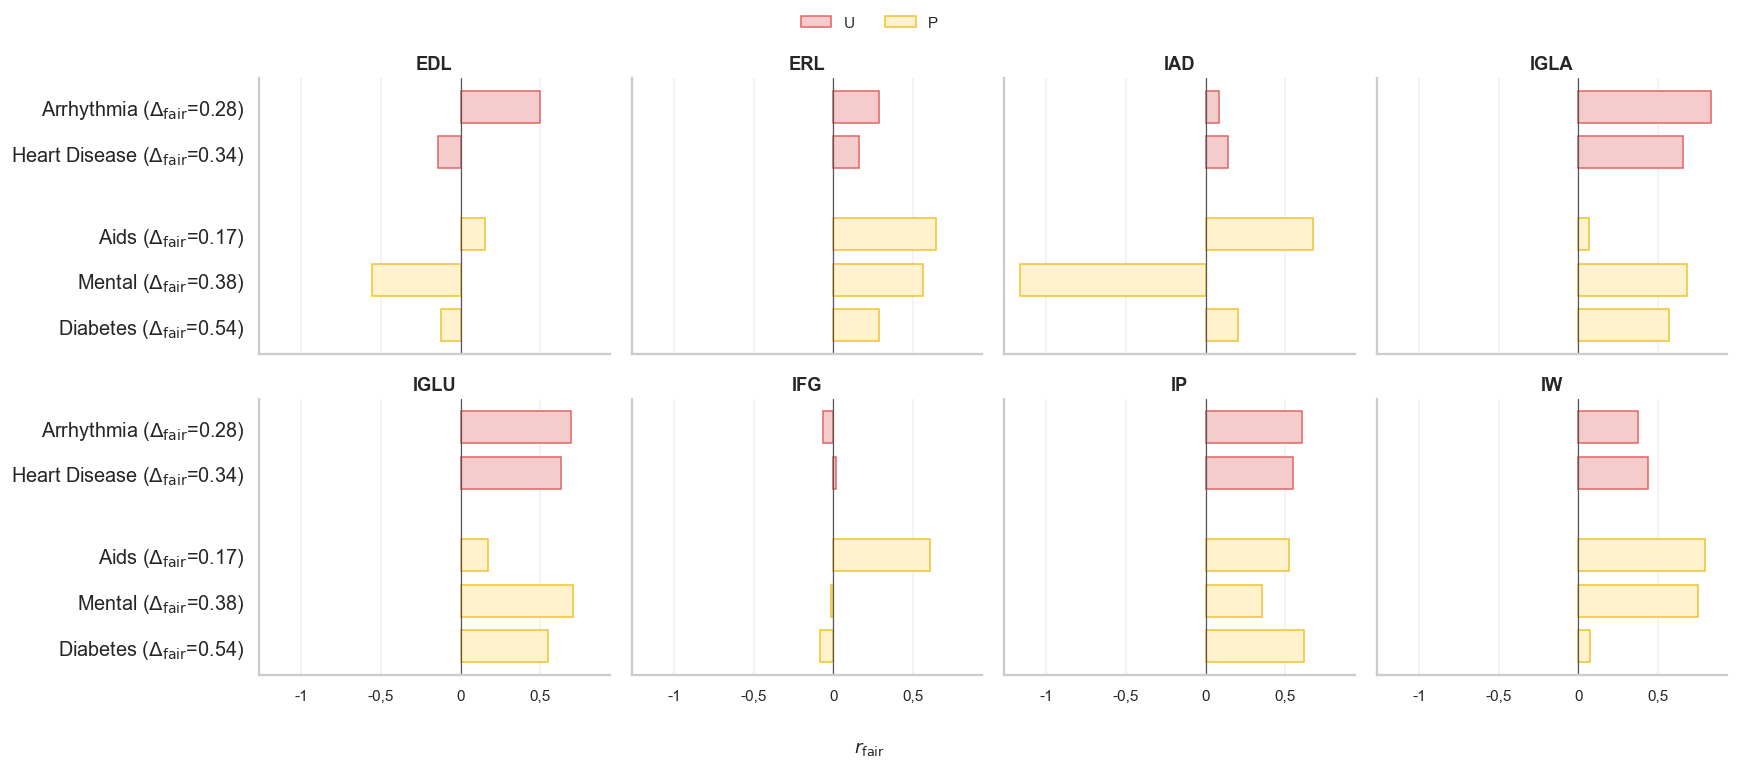

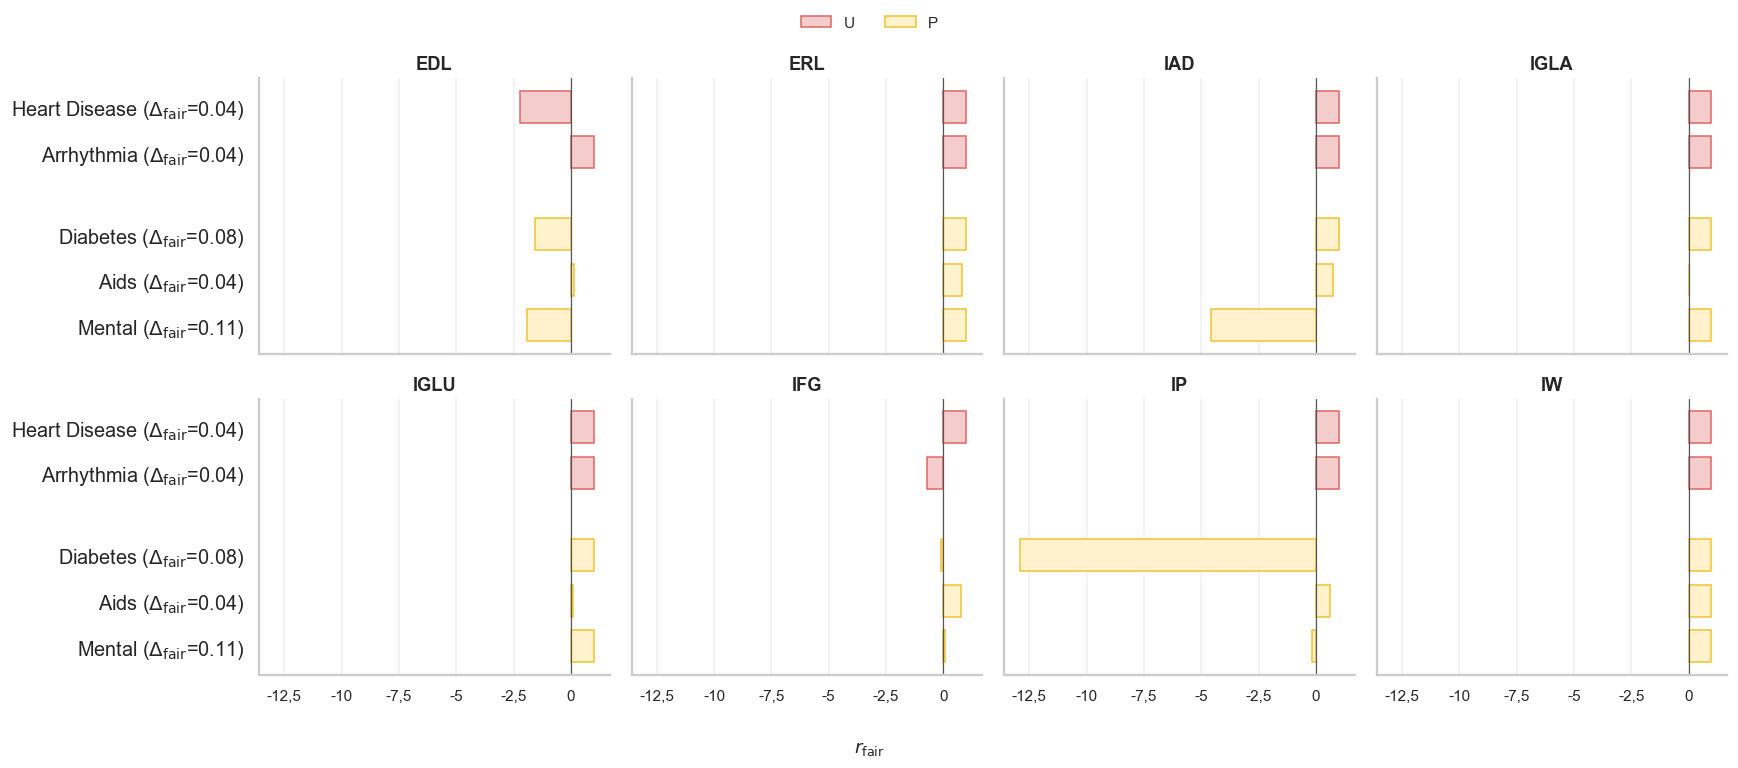

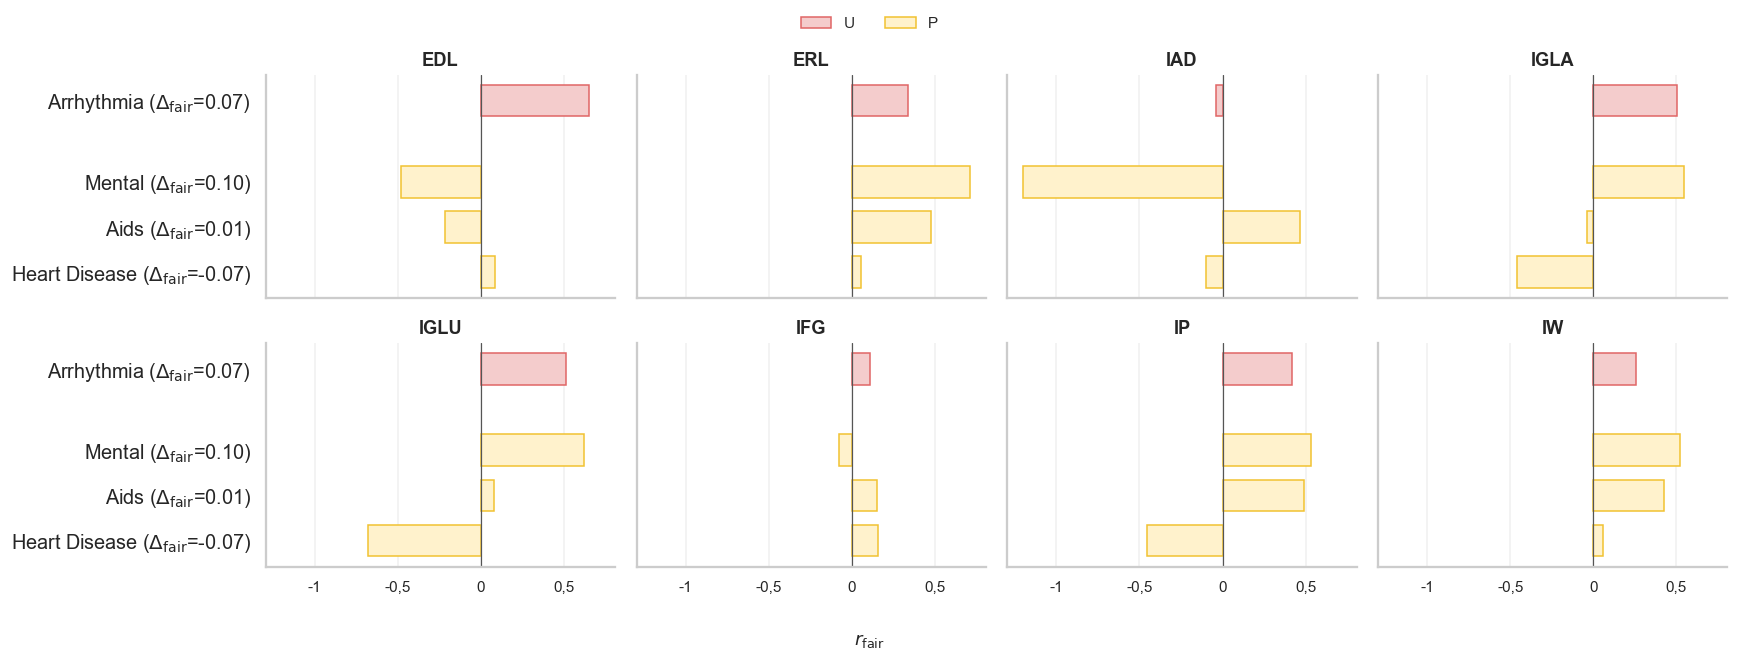

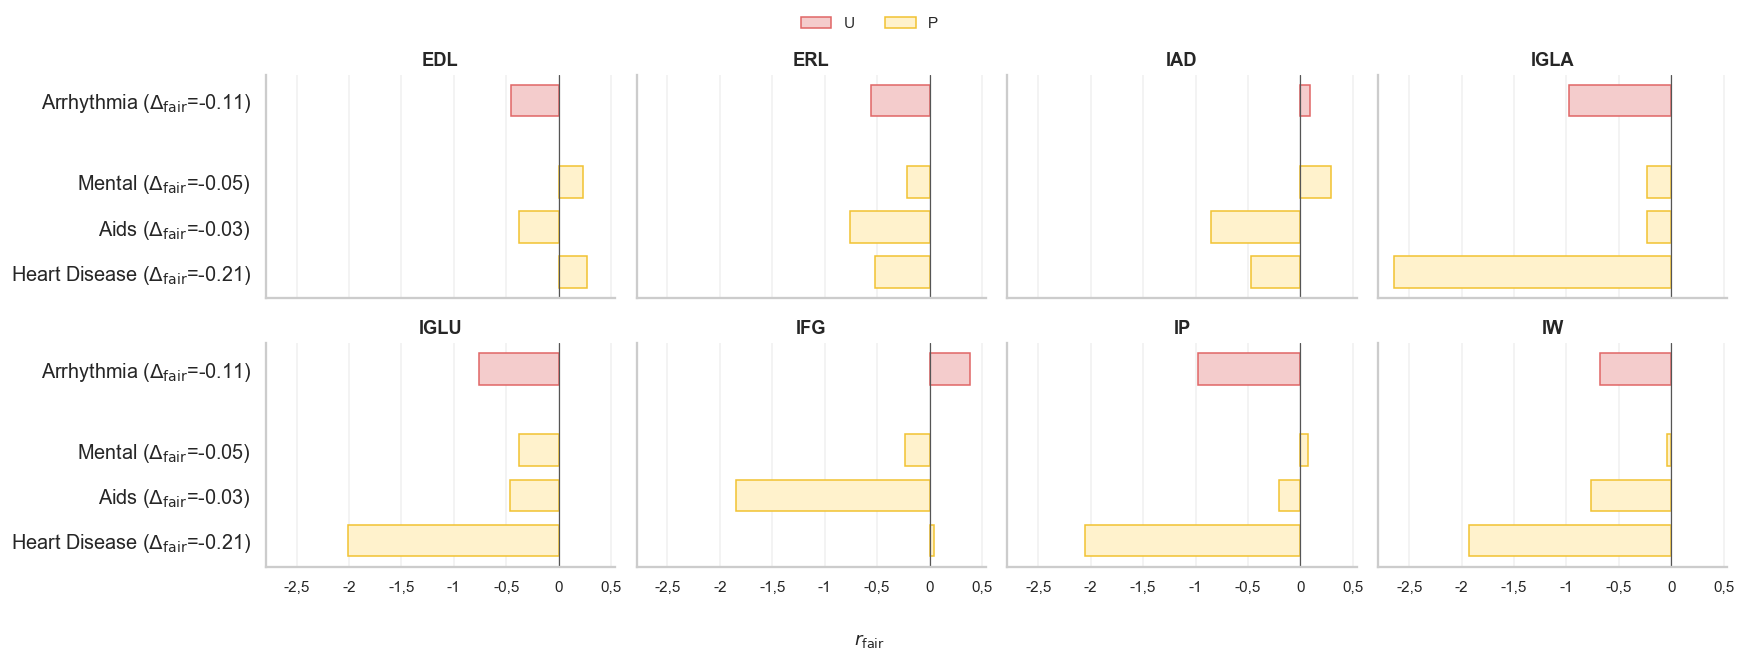

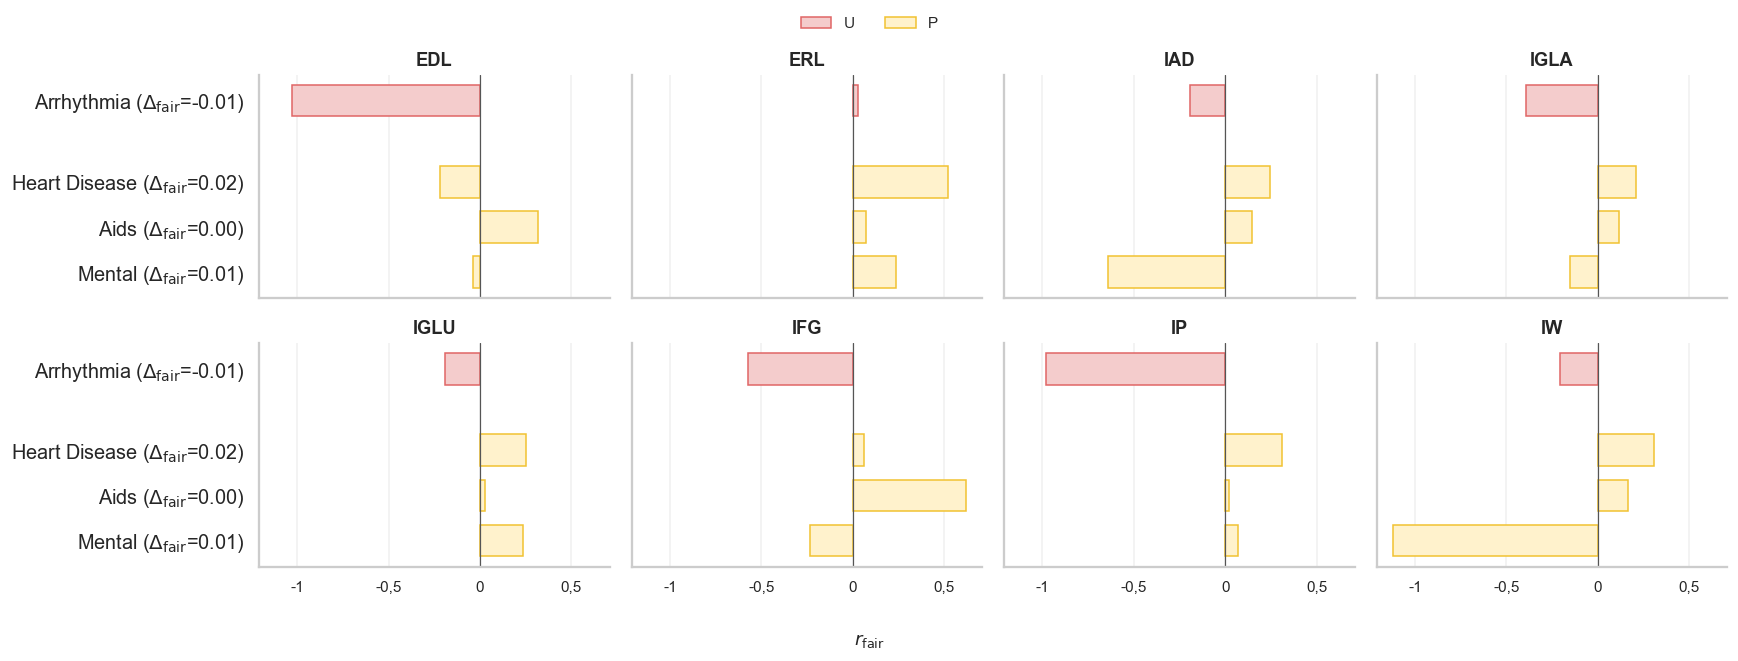

In [251]:
# RQ4 — Bar chart facetado: r_fair por dataset × método, agrupado por direção (U/P)
from auxiliar_analysis.rq4_utils import plot_rfair_bar_by_direction_faceted

METRICS_A = ["disparate_impact", "bias_amplification"]
METRICS_C = ["false_negative_rate_difference", "false_discovery_rate_difference", "error_rate_difference"]

for cat, metrics_list in [("A", METRICS_A), ("C", METRICS_C)]:
    for m in metrics_list:
        save = RQ_DIRS["RQ4"] / "figs" / f"bar_direction_{cat}_{m}.pdf"
        plot_rfair_bar_by_direction_faceted(
            df, classified,
            metric=m, category=cat,
            ideal_values=ideal_values,
            translate=translate,
            save_path=str(save),
        )

## 6) RQ5 - Como fica o trade off Fairness e Desempenho?

**Objetivo:** Sintetizar custo/beneficio em desempenho preditivo vs ganho em fairness.  
Unidade de analise: **dataset** (cada ponto = 1 dataset).  

Analises:
- Scatter: delta_F1 (eixo x) vs delta_fair (eixo y), baseado no baseline tipico
- Quadrantes: Q1 win-win, Q2 trade-off, Q3 lose-lose, Q4 perf-only
- Fronteira de Pareto: metodos nao-dominados
- Tabela de contagem por quadrante


In [245]:
# === Controle de fontes — RQ5 ===
from auxiliar_analysis import rq5_utils

rq5_utils._VIZ.update({
    "title_fontsize": 20,
    "label_fontsize": 18,
    "tick_fontsize": 16,
    "legend_fontsize": 15,
})



In [246]:
# RQ5 — Setup: dados de trade-off (ΔF1 vs Δfair) ao nível de dataset
from auxiliar_analysis.rq5_utils import (
    compute_tradeoff_data,
    plot_tradeoff_quadrant,
    compute_quadrant_table,
    identify_pareto_front,
    plot_pareto_front,
)

RQ5_FAIRNESS_METRICS = sorted(METRICS_PAPER)

rq5_tradeoff = {}
for fair_metric in RQ5_FAIRNESS_METRICS:
    rq5_tradeoff[fair_metric] = compute_tradeoff_data(
        df=df,
        fairness_metric=fair_metric,
        ideal_values=ideal_values,
        scope="all",
    )

# Verificacao
for m, tdf in rq5_tradeoff.items():
    if not tdf.empty:
        print(f"{m}: {tdf.shape[0]} linhas, "
              f"{tdf['dataset'].nunique()} datasets, "
              f"{tdf['method'].nunique()} metodos")


bias_amplification: 48 linhas, 6 datasets, 8 metodos
consistency: 48 linhas, 6 datasets, 8 metodos
disparate_impact: 48 linhas, 6 datasets, 8 metodos
error_rate_difference: 48 linhas, 6 datasets, 8 metodos
false_discovery_rate_difference: 48 linhas, 6 datasets, 8 metodos
false_negative_rate_difference: 48 linhas, 6 datasets, 8 metodos
generalized_entropy_index: 48 linhas, 6 datasets, 8 metodos


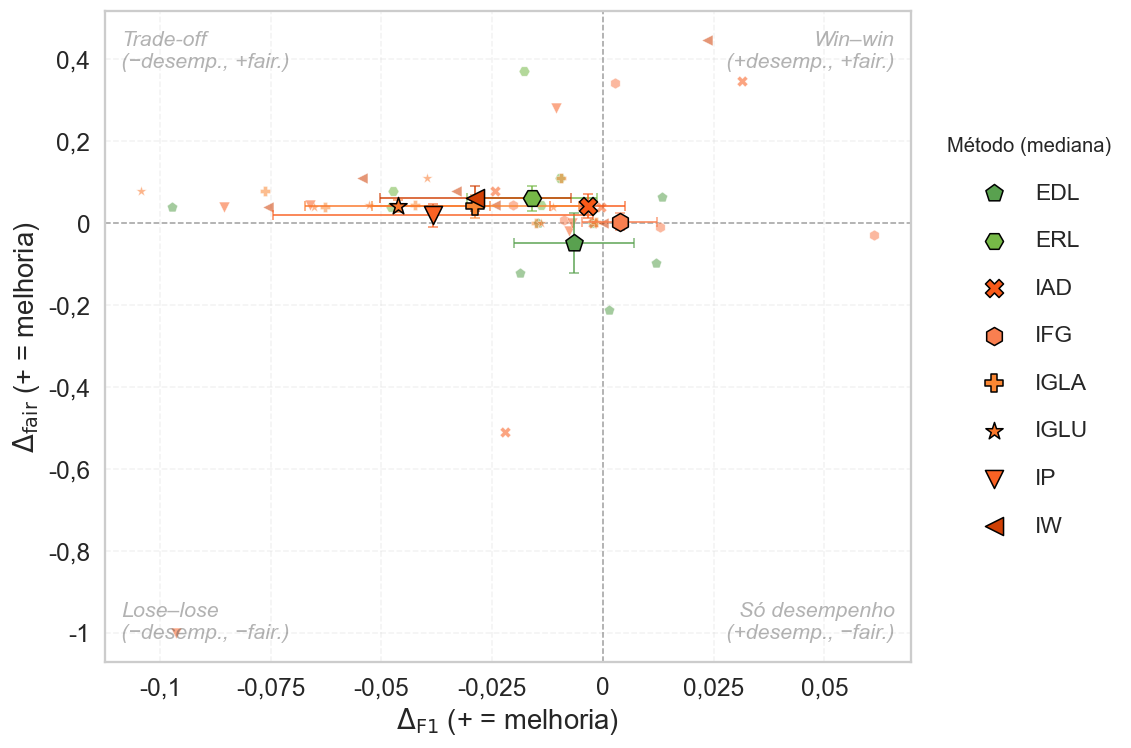

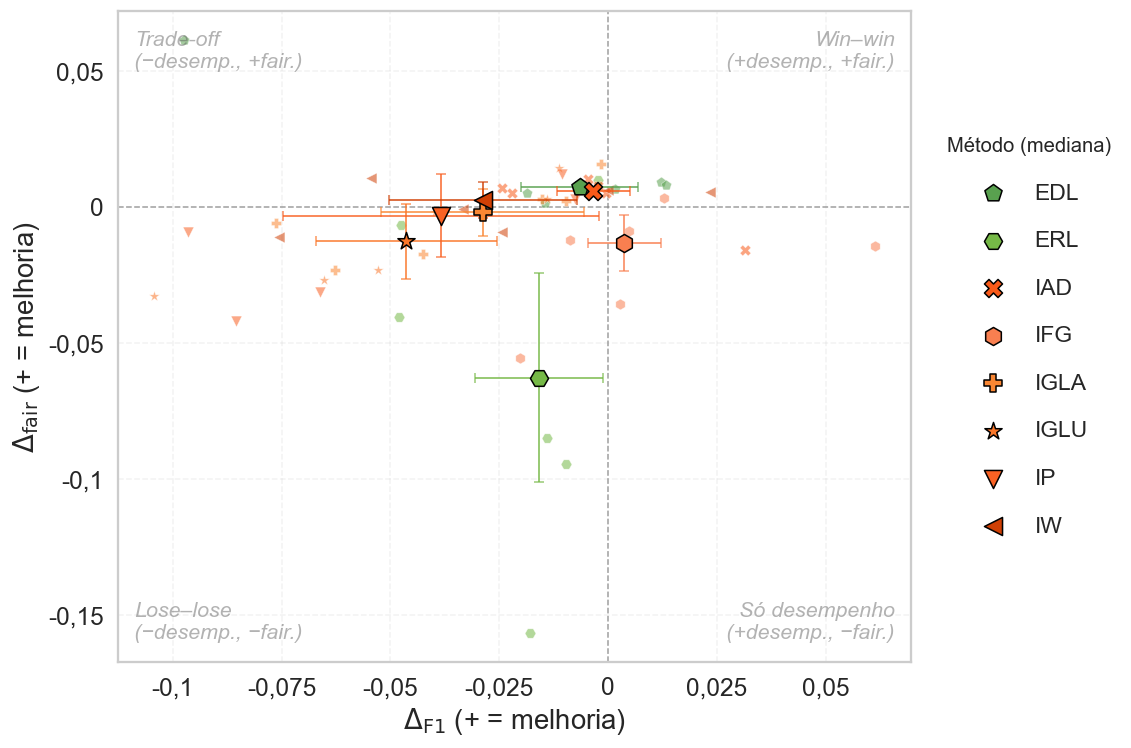

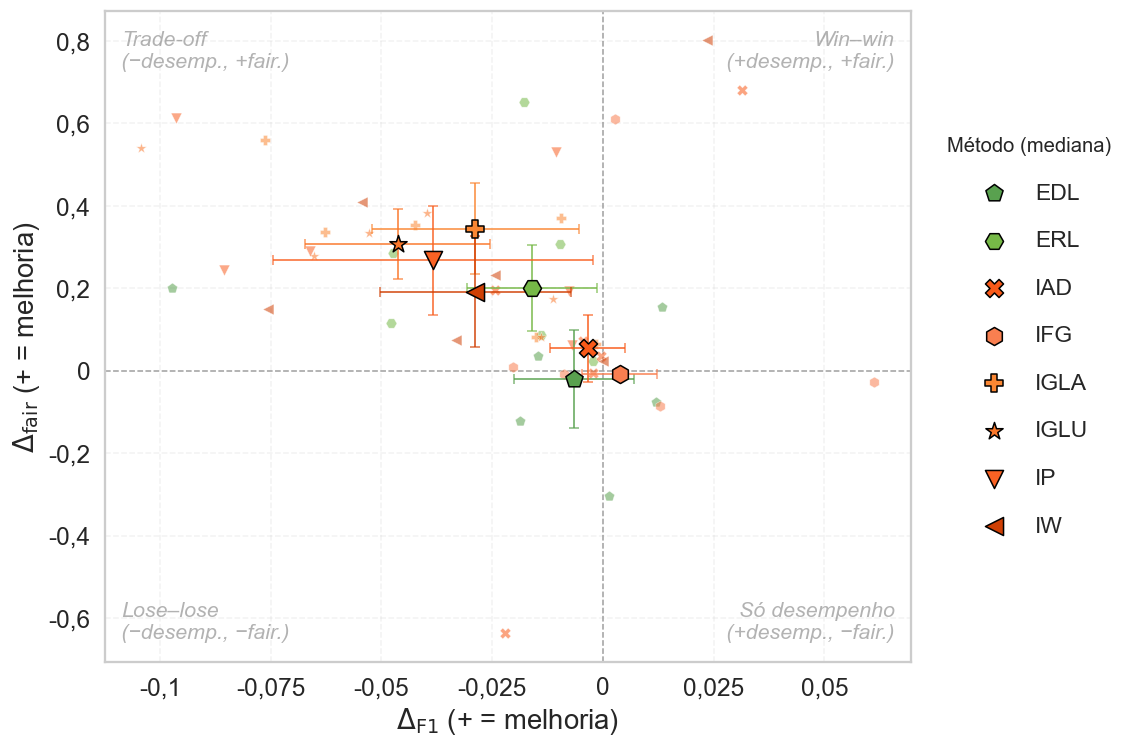

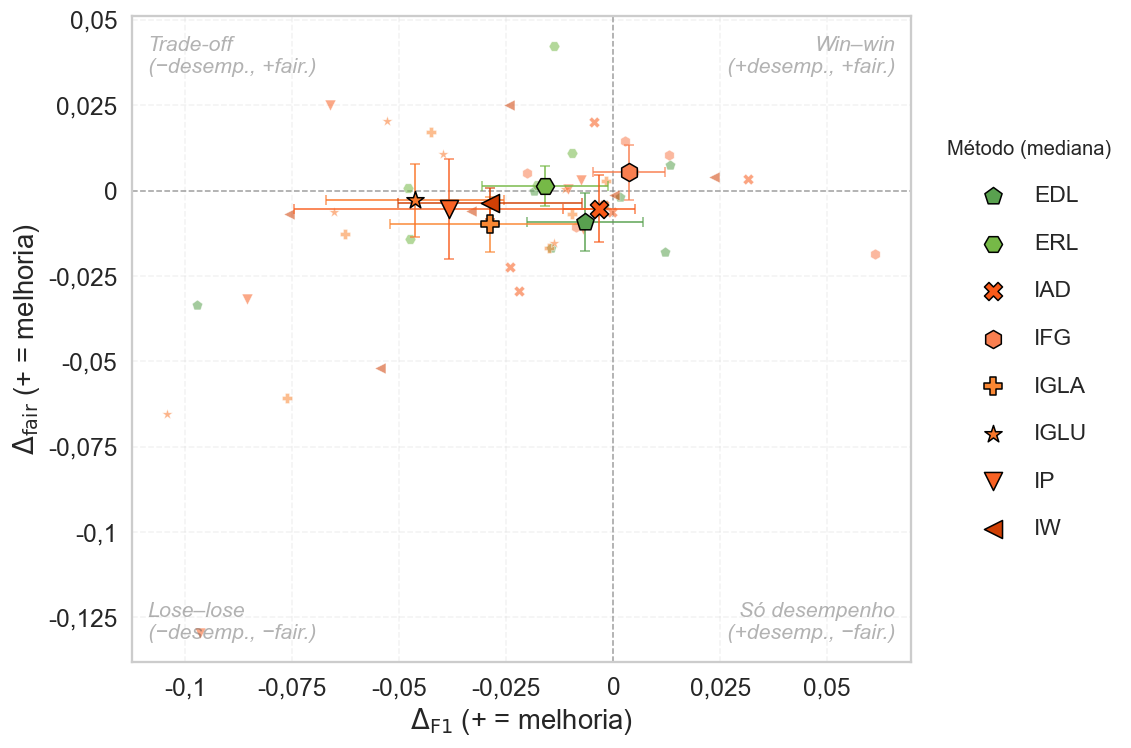

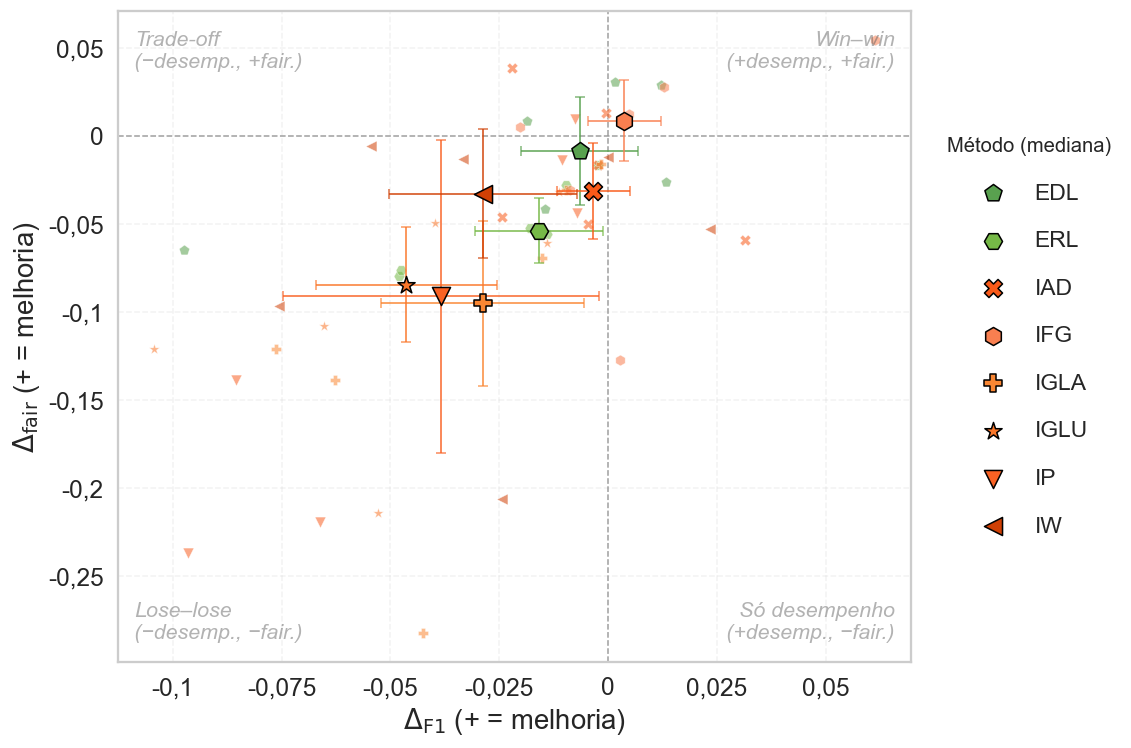

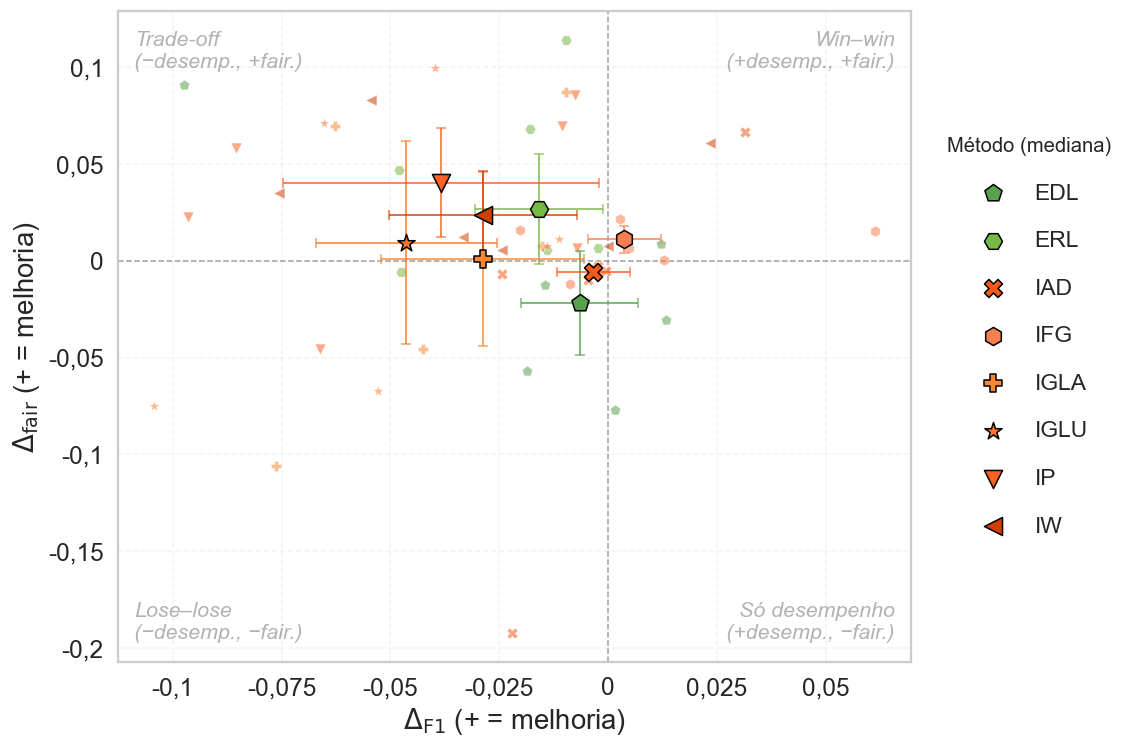

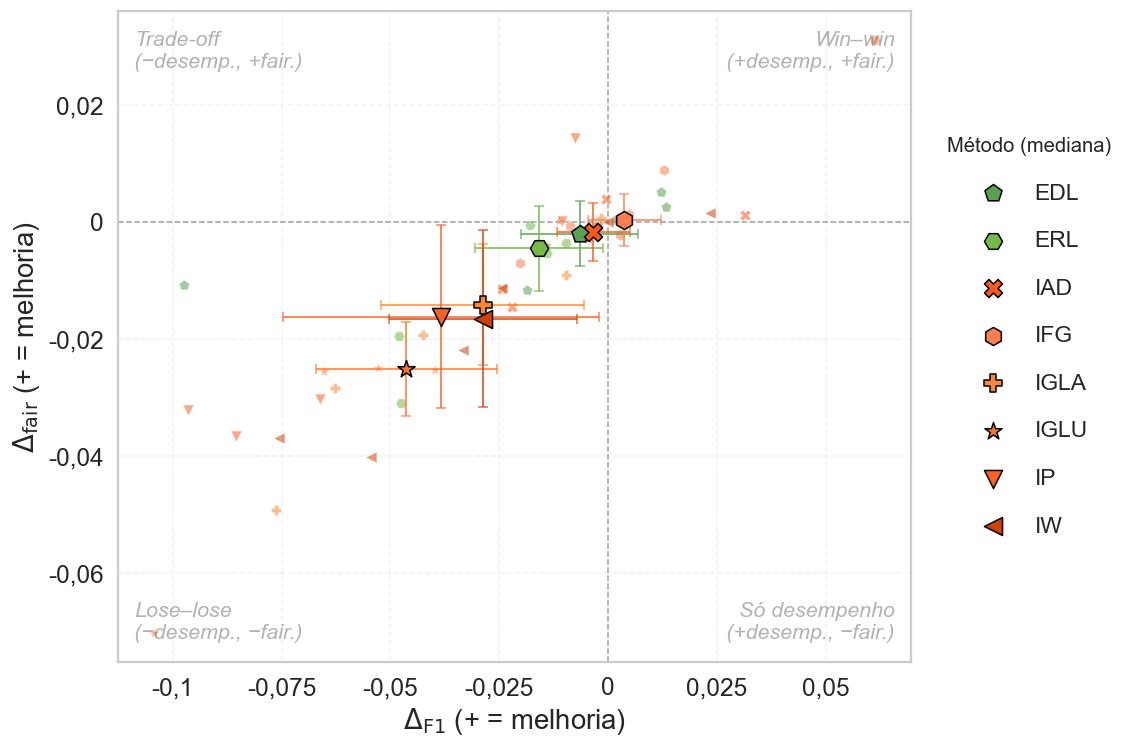

In [247]:
# RQ5 — Scatter com quadrantes: ΔF1 (x) vs Δfair (y)
for fair_metric in RQ5_FAIRNESS_METRICS:
    tdf = rq5_tradeoff.get(fair_metric)
    if tdf is None or tdf.empty:
        continue

    save = RQ5_FIGS / f"rq5_tradeoff_quadrant_{fair_metric}.pdf"
    plot_tradeoff_quadrant(
        tradeoff_df=tdf,
        fairness_metric=fair_metric,
        translate=translate,
        save_path=save,
        show=True,
    )


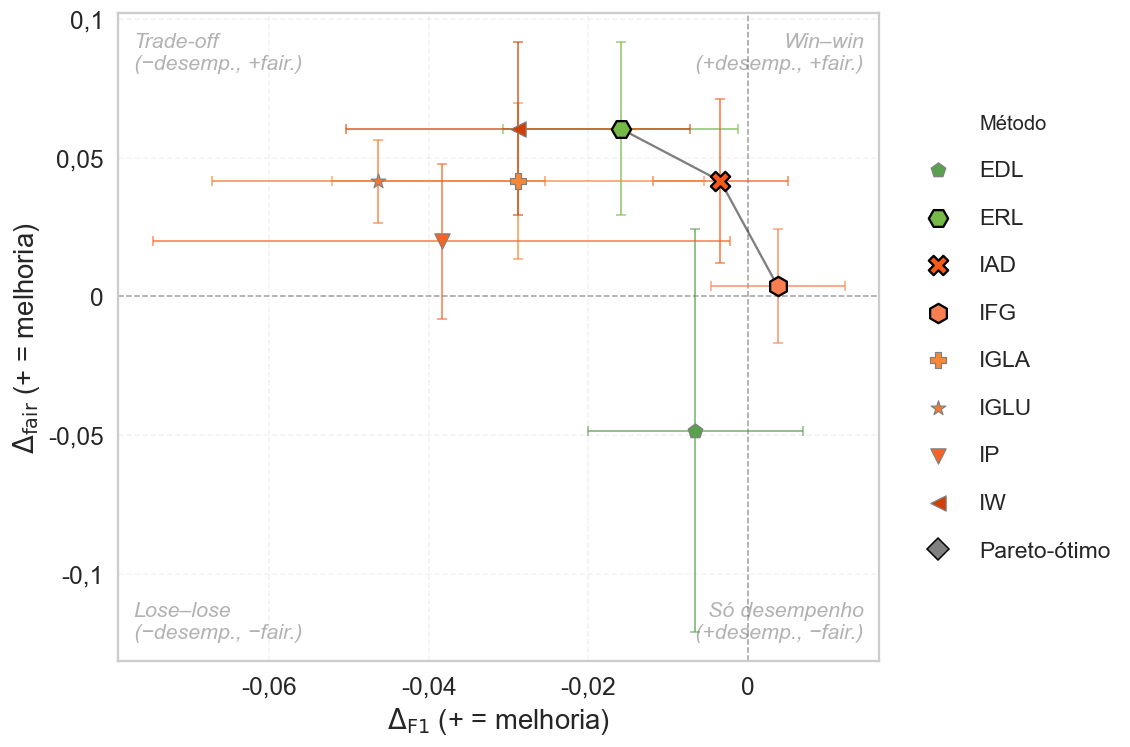

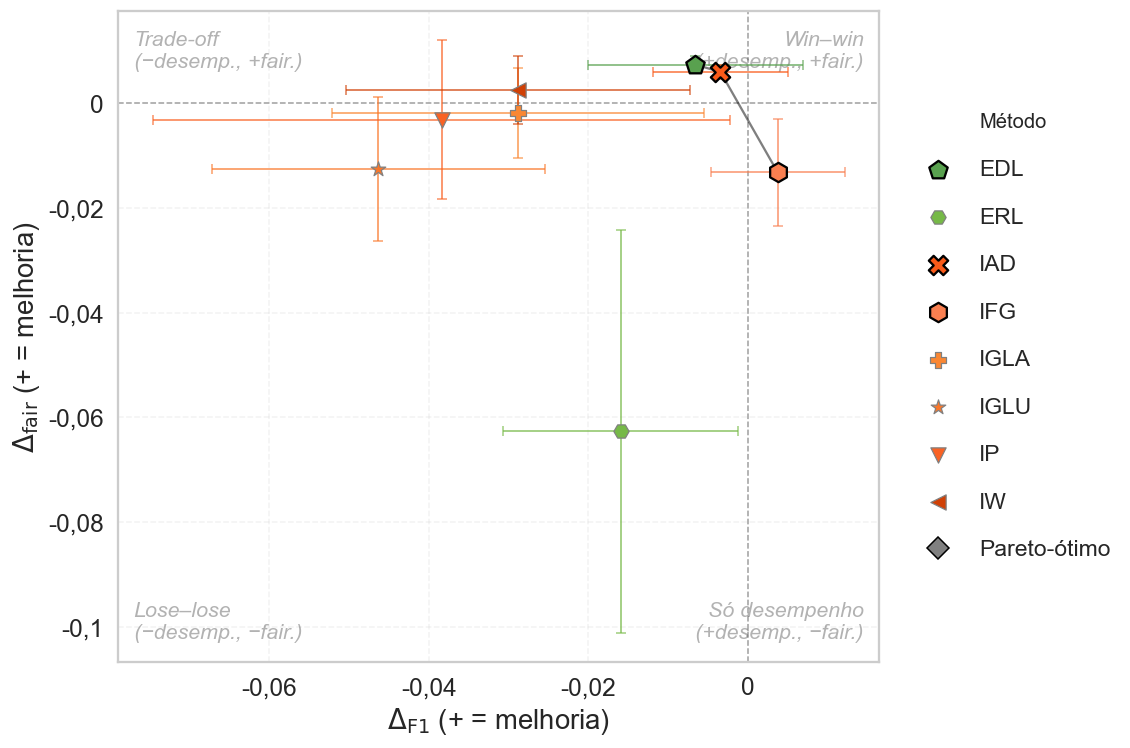

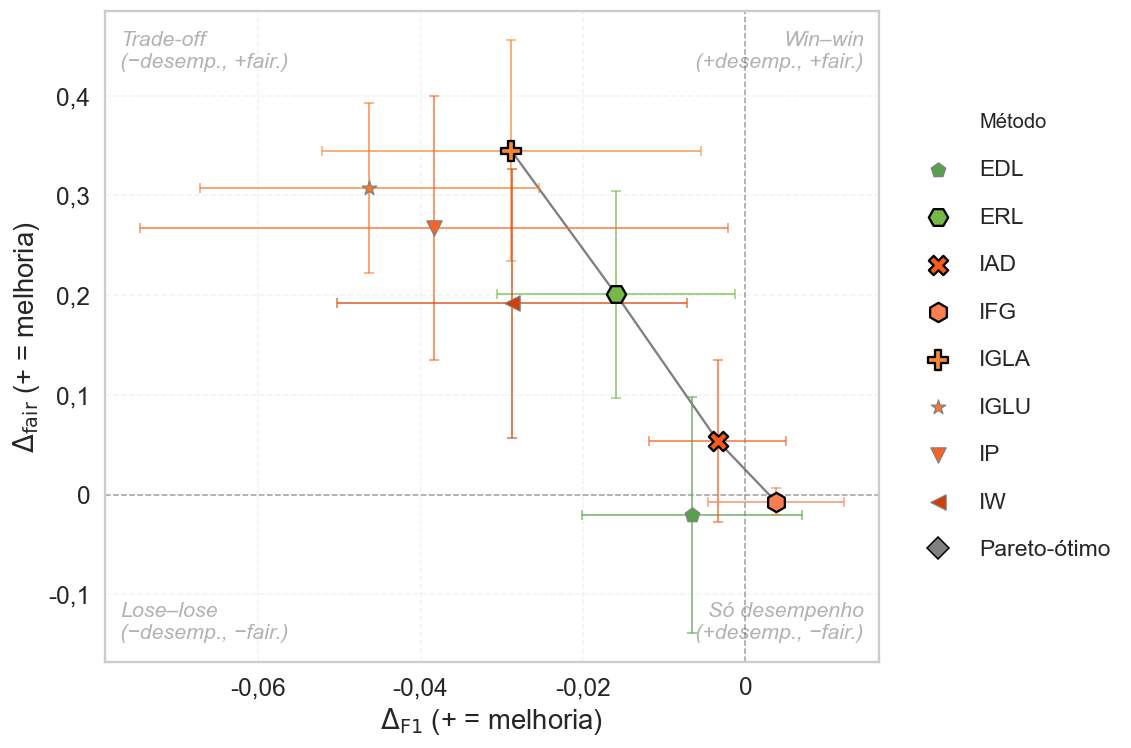

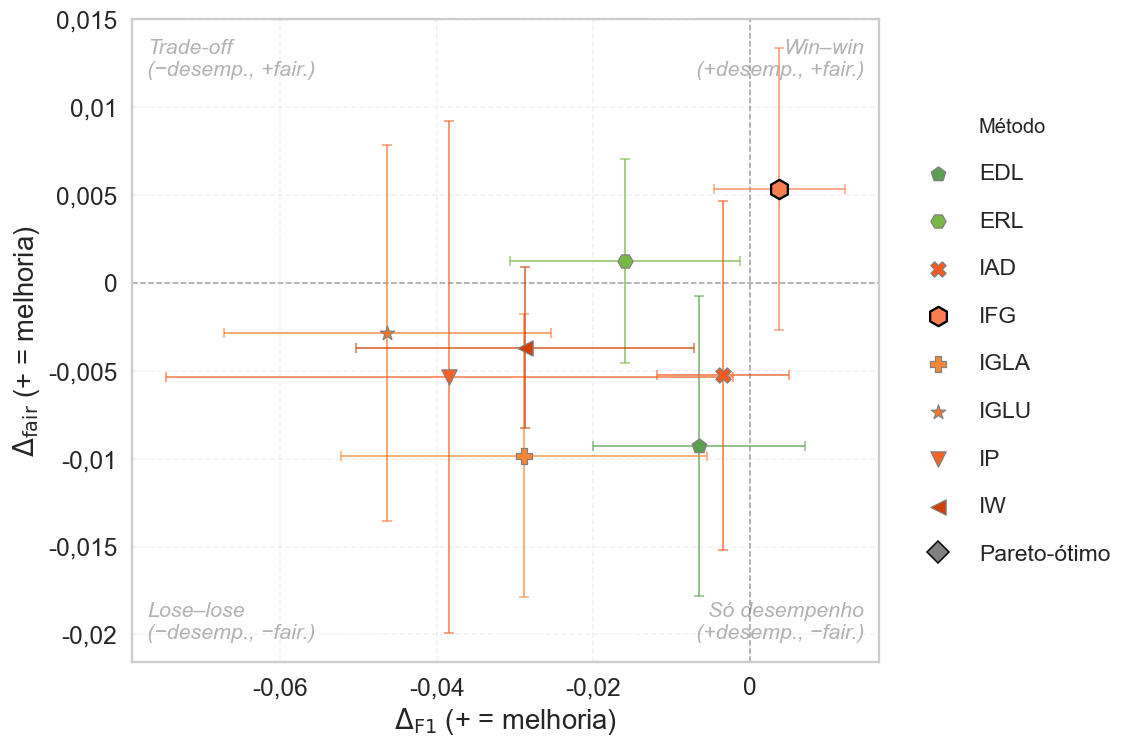

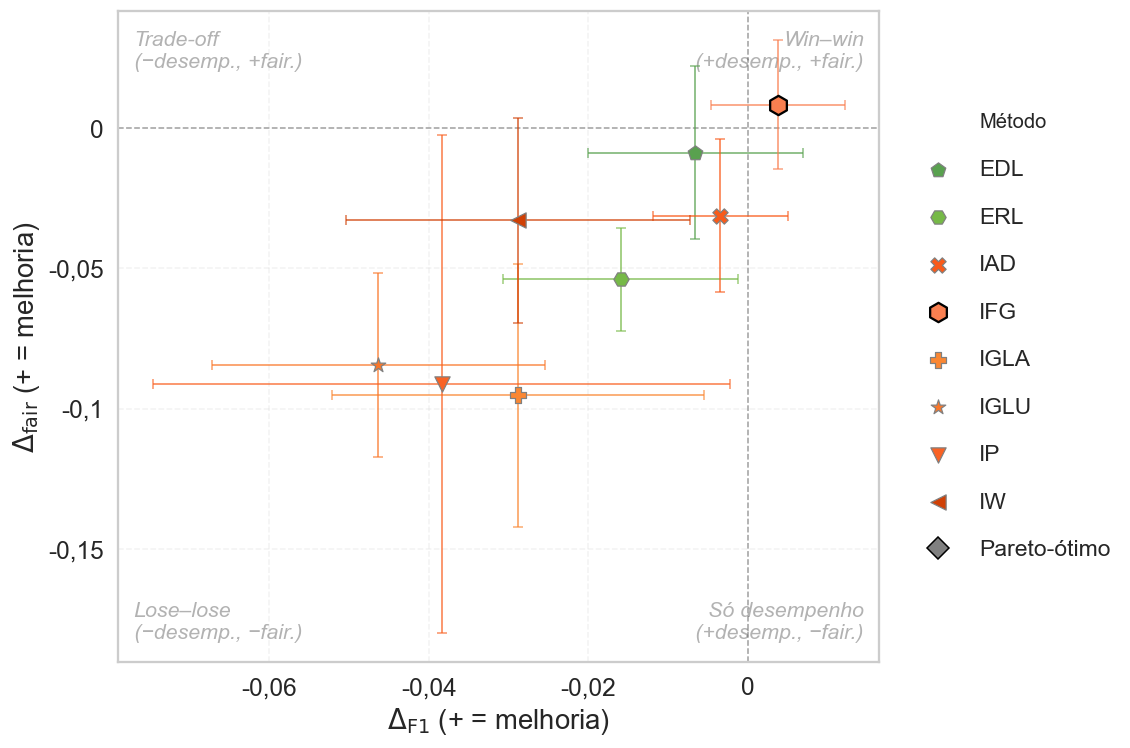

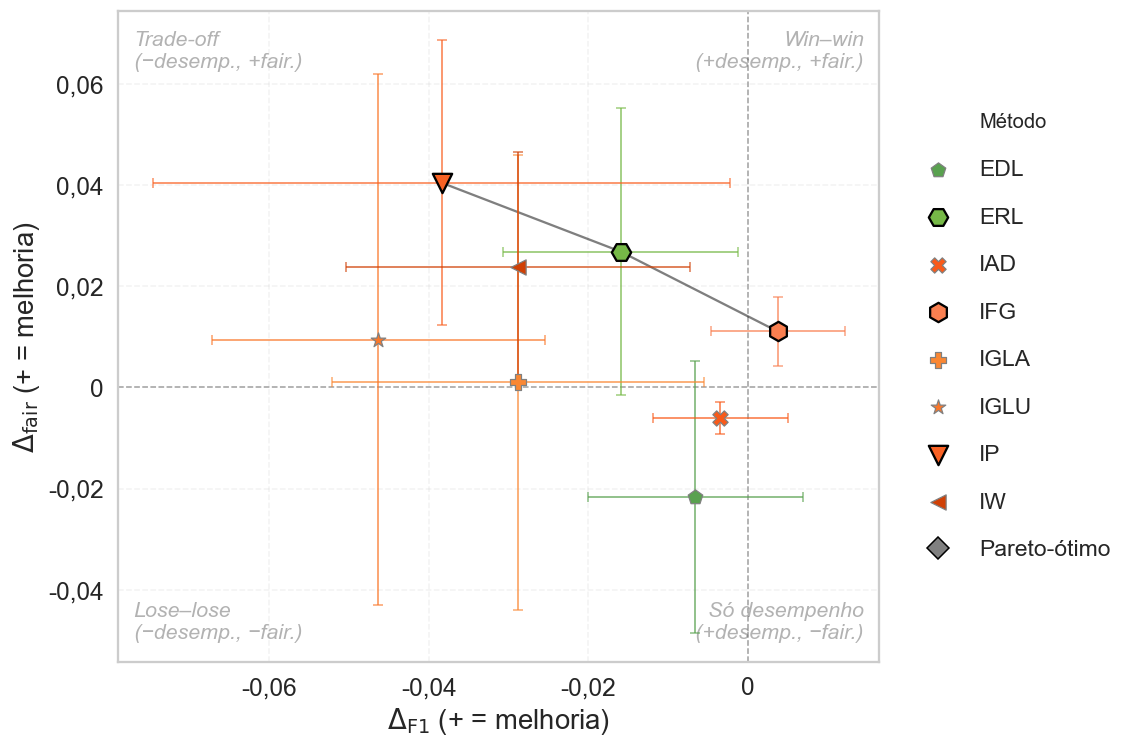

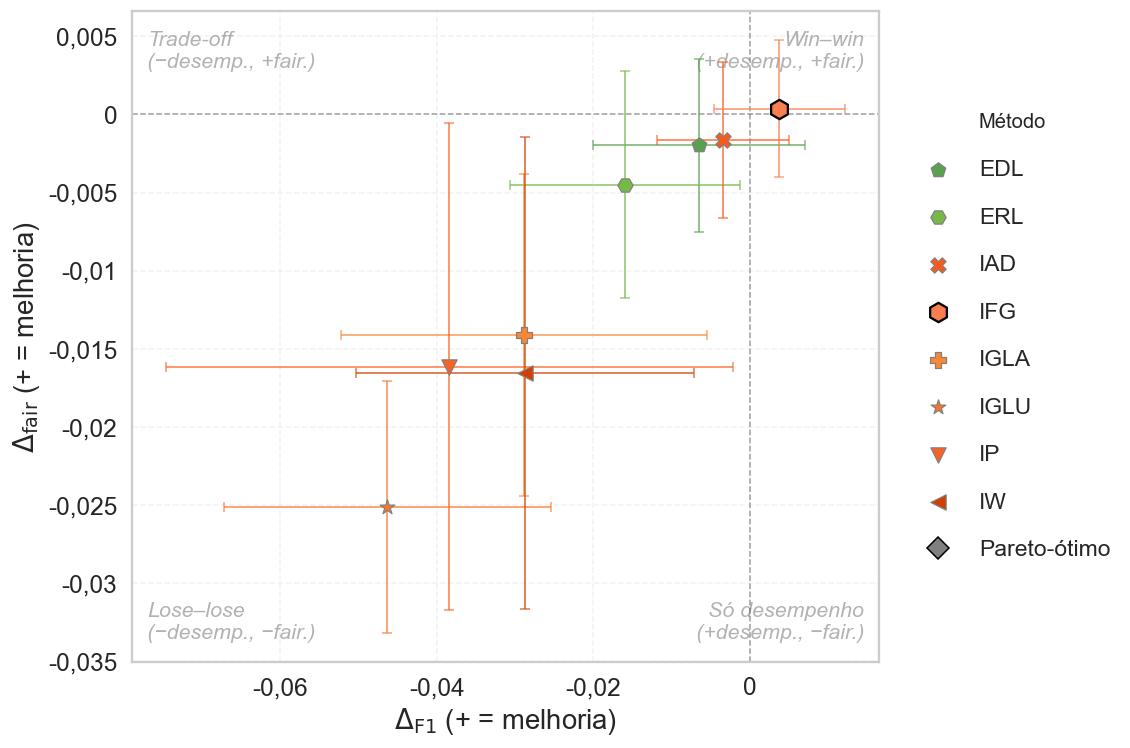

In [248]:
# RQ5 — Fronteira de Pareto: metodos nao-dominados
for fair_metric in RQ5_FAIRNESS_METRICS:
    tdf = rq5_tradeoff.get(fair_metric)
    if tdf is None or tdf.empty:
        continue

    save = RQ5_FIGS / f"rq5_pareto_front_{fair_metric}.pdf"
    plot_pareto_front(
        tradeoff_df=tdf,
        fairness_metric=fair_metric,
        translate=translate,
        save_path=save,
        show=True,
    )


In [249]:
# RQ5 — Tabelas: quadrantes + resumo de trade-off
from auxiliar_analysis.analysis_utils import latex_and_save
from auxiliar_analysis.rq5_utils import save_tradeoff_summary_latex

cols_quadrant = ["method", "category", "Q1", "Q2", "Q3", "Q4", "n", "win_rate_fair", "win_rate_winwin"]

for fair_metric in RQ5_FAIRNESS_METRICS:
    tdf = rq5_tradeoff.get(fair_metric)
    if tdf is None or tdf.empty:
        continue

    # Tabela de quadrantes
    qt = compute_quadrant_table(tdf)
    fair_label = translate.get(fair_metric, fair_metric)
    print()
    print(f"=== {fair_label} ===")
    display(qt)

    latex_and_save(
        qt,
        caption=f"Distribuição por quadrante: {fair_label}",
        label=f"tab_rq5_quadrant_{fair_metric}",
        result_dir=str(RQ5_TABLES),
        translate=translate,
        cols=cols_quadrant,
        multirow_cols=["category"],
        group_col="category",
    )

    # Tabelas resumo de trade-off (por método e por categoria)
    save_tradeoff_summary_latex(
        tdf,
        fairness_metric=fair_metric,
        save_dir=str(RQ5_TABLES),
        translate=translate,
    )



=== Amplificação de viés ===


quadrant,method,category,Q1,Q2,Q3,Q4,n,win_rate_fair,win_rate_winwin
0,EDL,pre_processing,1,2,1,2,6,0.500000,0.166667
1,ERL,pre_processing,0,6,0,0,6,1.000000,0.000000
2,IAD,in_processing,1,4,1,0,6,0.833333,0.166667
3,IGLA,in_processing,0,6,0,0,6,1.000000,0.000000
4,IGLU,in_processing,0,6,0,0,6,1.000000,0.000000
5,IFG,in_processing,2,2,0,2,6,0.666667,0.333333
6,IP,in_processing,0,4,2,0,6,0.666667,0.000000
7,IW,in_processing,2,4,0,0,6,1.000000,0.333333


Tabela salva em: experiments\results\analysis\RQ5\tables\tab_rq5_quadrant_bias_amplification.tex
| method   | category       |   Q1 |   Q2 |   Q3 |   Q4 |   n |   win_rate_fair |   win_rate_winwin |
|:---------|:---------------|-----:|-----:|-----:|-----:|----:|----------------:|------------------:|
| EDL      | pre_processing |    1 |    2 |    1 |    2 |   6 |        0.5      |          0.166667 |
| ERL      | pre_processing |    0 |    6 |    0 |    0 |   6 |        1        |          0        |
| IAD      | in_processing  |    1 |    4 |    1 |    0 |   6 |        0.833333 |          0.166667 |
| IGLA     | in_processing  |    0 |    6 |    0 |    0 |   6 |        1        |          0        |
| IGLU     | in_processing  |    0 |    6 |    0 |    0 |   6 |        1        |          0        |
| IFG      | in_processing  |    2 |    2 |    0 |    2 |   6 |        0.666667 |          0.333333 |
| IP       | in_processing  |    0 |    4 |    2 |    0 |   6 |        0.666667 |      

quadrant,method,category,Q1,Q2,Q3,Q4,n,win_rate_fair,win_rate_winwin
0,EDL,pre_processing,3,3,0,0,6,1.000000,0.500000
1,ERL,pre_processing,0,1,5,0,6,0.166667,0.000000
2,IAD,in_processing,0,5,0,1,6,0.833333,0.000000
3,IGLA,in_processing,0,3,3,0,6,0.500000,0.000000
4,IGLU,in_processing,0,2,4,0,6,0.333333,0.000000
5,IFG,in_processing,1,0,2,3,6,0.166667,0.166667
6,IP,in_processing,0,3,3,0,6,0.500000,0.000000
7,IW,in_processing,2,1,3,0,6,0.500000,0.333333


Tabela salva em: experiments\results\analysis\RQ5\tables\tab_rq5_quadrant_consistency.tex
| method   | category       |   Q1 |   Q2 |   Q3 |   Q4 |   n |   win_rate_fair |   win_rate_winwin |
|:---------|:---------------|-----:|-----:|-----:|-----:|----:|----------------:|------------------:|
| EDL      | pre_processing |    3 |    3 |    0 |    0 |   6 |        1        |          0.5      |
| ERL      | pre_processing |    0 |    1 |    5 |    0 |   6 |        0.166667 |          0        |
| IAD      | in_processing  |    0 |    5 |    0 |    1 |   6 |        0.833333 |          0        |
| IGLA     | in_processing  |    0 |    3 |    3 |    0 |   6 |        0.5      |          0        |
| IGLU     | in_processing  |    0 |    2 |    4 |    0 |   6 |        0.333333 |          0        |
| IFG      | in_processing  |    1 |    0 |    2 |    3 |   6 |        0.166667 |          0.166667 |
| IP       | in_processing  |    0 |    3 |    3 |    0 |   6 |        0.5      |          0  

...

Tabela salva em: experiments\results\analysis\RQ5\tables\tab_rq5_quadrant_false_discovery_rate_difference.tex
| method   | category       |   Q1 |   Q2 |   Q3 |   Q4 |   n |   win_rate_fair |   win_rate_winwin |
|:---------|:---------------|-----:|-----:|-----:|-----:|----:|----------------:|------------------:|
| EDL      | pre_processing |    2 |    1 |    2 |    1 |   6 |        0.5      |          0.333333 |
| ERL      | pre_processing |    0 |    0 |    6 |    0 |   6 |        0        |          0        |
| IAD      | in_processing  |    0 |    2 |    3 |    1 |   6 |        0.333333 |          0        |
| IGLA     | in_processing  |    0 |    0 |    6 |    0 |   6 |        0        |          0        |
| IGLU     | in_processing  |    0 |    0 |    6 |    0 |   6 |        0        |          0        |
| IFG      | in_processing  |    3 |    1 |    1 |    1 |   6 |        0.666667 |          0.5      |
| IP       | in_processing  |    0 |    1 |    5 |    0 |   6 |        0.1

quadrant,method,category,Q1,Q2,Q3,Q4,n,win_rate_fair,win_rate_winwin
0,EDL,pre_processing,1,1,2,2,6,0.333333,0.166667
1,ERL,pre_processing,0,5,1,0,6,0.833333,0.000000
2,IAD,in_processing,1,0,5,0,6,0.166667,0.166667
3,IGLA,in_processing,0,3,3,0,6,0.500000,0.000000
4,IGLU,in_processing,0,4,2,0,6,0.666667,0.000000
5,IFG,in_processing,4,1,1,0,6,0.833333,0.666667
6,IP,in_processing,0,5,1,0,6,0.833333,0.000000
7,IW,in_processing,2,4,0,0,6,1.000000,0.333333


Tabela salva em: experiments\results\analysis\RQ5\tables\tab_rq5_quadrant_false_negative_rate_difference.tex
| method   | category       |   Q1 |   Q2 |   Q3 |   Q4 |   n |   win_rate_fair |   win_rate_winwin |
|:---------|:---------------|-----:|-----:|-----:|-----:|----:|----------------:|------------------:|
| EDL      | pre_processing |    1 |    1 |    2 |    2 |   6 |        0.333333 |          0.166667 |
| ERL      | pre_processing |    0 |    5 |    1 |    0 |   6 |        0.833333 |          0        |
| IAD      | in_processing  |    1 |    0 |    5 |    0 |   6 |        0.166667 |          0.166667 |
| IGLA     | in_processing  |    0 |    3 |    3 |    0 |   6 |        0.5      |          0        |
| IGLU     | in_processing  |    0 |    4 |    2 |    0 |   6 |        0.666667 |          0        |
| IFG      | in_processing  |    4 |    1 |    1 |    0 |   6 |        0.833333 |          0.666667 |
| IP       | in_processing  |    0 |    5 |    1 |    0 |   6 |        0.83

quadrant,method,category,Q1,Q2,Q3,Q4,n,win_rate_fair,win_rate_winwin
0,EDL,pre_processing,3,0,3,0,6,0.500000,0.500000
1,ERL,pre_processing,0,0,6,0,6,0.000000,0.000000
2,IAD,in_processing,1,1,4,0,6,0.333333,0.166667
3,IGLA,in_processing,0,1,5,0,6,0.166667,0.000000
4,IGLU,in_processing,0,1,5,0,6,0.166667,0.000000
5,IFG,in_processing,3,0,2,1,6,0.500000,0.500000
6,IP,in_processing,0,2,4,0,6,0.333333,0.000000
7,IW,in_processing,2,0,4,0,6,0.333333,0.333333


Tabela salva em: experiments\results\analysis\RQ5\tables\tab_rq5_quadrant_generalized_entropy_index.tex
| method   | category       |   Q1 |   Q2 |   Q3 |   Q4 |   n |   win_rate_fair |   win_rate_winwin |
|:---------|:---------------|-----:|-----:|-----:|-----:|----:|----------------:|------------------:|
| EDL      | pre_processing |    3 |    0 |    3 |    0 |   6 |        0.5      |          0.5      |
| ERL      | pre_processing |    0 |    0 |    6 |    0 |   6 |        0        |          0        |
| IAD      | in_processing  |    1 |    1 |    4 |    0 |   6 |        0.333333 |          0.166667 |
| IGLA     | in_processing  |    0 |    1 |    5 |    0 |   6 |        0.166667 |          0        |
| IGLU     | in_processing  |    0 |    1 |    5 |    0 |   6 |        0.166667 |          0        |
| IFG      | in_processing  |    3 |    0 |    2 |    1 |   6 |        0.5      |          0.5      |
| IP       | in_processing  |    0 |    2 |    4 |    0 |   6 |        0.333333 

## 7) Apêndices (catálogos e completude)

- Catálogo dataset × método × métrica
- Subpadrões finos (A1/A2/...)
- Boxplots detalhados, sensibilidade
- Holm completo e comparações adicionais
